In [ ]:
# Install required libraries

!pip install -q geopandas shapely pandas numpy scipy scikit-learn pyogrio

In [ ]:
# Import libraries

import pandas as pd
import numpy as np
import geopandas as gpd

from shapely.geometry import Point, LineString

import scipy
import sklearn

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("GeoPandas:", gpd.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)

Pandas: 2.2.3
NumPy: 2.1.3
GeoPandas: 1.1.4
SciPy: 1.16.3
Scikit-learn: 1.6.1


In [ ]:
import os

print(os.listdir())

['.config', 'drive', 'assam_districts.gpkg', 'assam_roads.gpkg', 'assam_major_roads.gpkg', 'assam_road_routing.gpkg', 'assam_major_roads_clean.gpkg', 'assam_edges.gpkg', 'assam_nodes.gpkg', 'assam_districts_assam.gpkg', 'rainfall_manual_daily_cwc_as_2021_2025.csv', 'assam_road_attributes.gpkg', 'rainfall_tel_hr_assam_as_2021_2025.csv', 'rainfall_tel_hr_cwc_as_2021_2025.csv', 'rainfall_manual_daily_assam_as_2021_2025.csv', 'assam_boundary.gpkg', 'assam_graph.pkl', 'sample_data']


In [ ]:
rainfall = pd.read_csv(
    "rainfall_manual_daily_assam_as_2021_2025.csv"
)

print("Shape:", rainfall.shape)

rainfall.head()

Shape: (11270, 20)


In [ ]:
rainfall.info()

In [ ]:
rainfall.columns.tolist()

In [ ]:
rainfall.describe(include="all")

In [ ]:
rainfall.isnull().sum()

In [ ]:
rainfall.dtypes

In [ ]:
roads = gpd.read_file(
    "assam_road_routing.gpkg",
    layer="road_routing"
)

print("Shape:", roads.shape)
print("CRS:", roads.crs)

roads.head()

In [ ]:
roads.info()

In [ ]:
roads.columns.tolist()

In [ ]:
roads.geometry.geom_type.value_counts()

In [ ]:
roads.describe(include="all")

## 4. Historical Disruption Events

In [ ]:
disruption_events_raw = pd.DataFrame(columns=[
    "event_year",
    "event_start",
    "event_end",
    "district",
    "road_reference",
    "road_name",
    "incident_type",
    "description",
    "affected_length_km",
    "bridge_damage",
    "culvert_damage",
    "road_breach",
    "source_file",
    "source_page",
    "label_confidence"
])

disruption_events_raw

,event_year,event_start,event_end,district,road_reference,road_name,incident_type,description,affected_length_km,bridge_damage,culvert_damage,road_breach,source_file,source_page,label_confidence


In [ ]:
events = [
    {
        "event_year": 2021,
        "event_start": "...",
        "event_end": "...",
        "district": "...",
        "road_reference": "...",
        "road_name": "Bolahi to Balipukhuri Road",
        "incident_type": "road_damage",
        "description": "Road affected during flood event",
        "affected_length_km": np.nan,
        "bridge_damage": 0,
        "culvert_damage": 0,
        "road_breach": 1,
        "source_file": "assam_flood_memorandum_2021.pdf",
        "source_page": "...",
        "label_confidence": "strong"
    }
]

disruption_events_raw = pd.DataFrame(events)

disruption_events_raw

,event_year,event_start,event_end,district,road_reference,road_name,incident_type,description,affected_length_km,bridge_damage,culvert_damage,road_breach,source_file,source_page,label_confidence
0,2021,...,...,...,...,Bolahi to Balipukhuri Road,road_damage,Road affected during flood event,NaN,0,0,1,assam_flood_memorandum_2021.pdf,...,strong


In [ ]:
print("Total events:", len(disruption_events_raw))

display(disruption_events_raw)

Total events: 1


,event_year,event_start,event_end,district,road_reference,road_name,incident_type,description,affected_length_km,bridge_damage,culvert_damage,road_breach,source_file,source_page,label_confidence
0,2021,...,...,...,...,Bolahi to Balipukhuri Road,road_damage,Road affected during flood event,NaN,0,0,1,assam_flood_memorandum_2021.pdf,...,strong


In [ ]:
print("\nEvents by year:")
print(disruption_events_raw["event_year"].value_counts().sort_index())

print("\nIncident types:")
print(disruption_events_raw["incident_type"].value_counts())

print("\nConfidence:")
print(disruption_events_raw["label_confidence"].value_counts())


Events by year:
event_year
2021    1
Name: count, dtype: int64

Incident types:
incident_type
road_damage    1
Name: count, dtype: int64

Confidence:
label_confidence
strong    1
Name: count, dtype: int64


In [ ]:
new_events = pd.DataFrame([
    {
        "event_year": 2021,
        "event_start": None,
        "event_end": None,
        "district": "Lakhimpur",
        "road_reference": None,
        "road_name": "Bolahi to Balipukhuri Road",
        "incident_type": "road_damage",
        "description": "Infrastructure damage reported during Assam flood 2021",
        "affected_length_km": None,
        "bridge_damage": 0,
        "culvert_damage": 0,
        "road_breach": None,
        "source_file": "assam_flood_memorandum_2021.pdf",
        "source_page": None,
        "label_confidence": "strong"
    },
    {
        "event_year": 2021,
        "event_start": None,
        "event_end": None,
        "district": "Chirang",
        "road_reference": None,
        "road_name": "Bijni Panbari Road",
        "incident_type": "road_damage",
        "description": "Infrastructure damage reported during Assam flood 2021",
        "affected_length_km": None,
        "bridge_damage": 0,
        "culvert_damage": 0,
        "road_breach": None,
        "source_file": "assam_flood_memorandum_2021.pdf",
        "source_page": None,
        "label_confidence": "strong"
    },
    {
        "event_year": 2021,
        "event_start": None,
        "event_end": None,
        "district": "Chirang",
        "road_reference": None,
        "road_name": "Sidli ICBP Road",
        "incident_type": "road_damage",
        "description": "Infrastructure damage reported during Assam flood 2021",
        "affected_length_km": None,
        "bridge_damage": 0,
        "culvert_damage": 0,
        "road_breach": None,
        "source_file": "assam_flood_memorandum_2021.pdf",
        "source_page": None,
        "label_confidence": "strong"
    },
    {
        "event_year": 2021,
        "event_start": None,
        "event_end": None,
        "district": "Bongaigaon",
        "road_reference": None,
        "road_name": "Bongaigaon to Kirtanpara Road",
        "incident_type": "road_damage",
        "description": "Infrastructure damage reported during Assam flood 2021",
        "affected_length_km": None,
        "bridge_damage": 0,
        "culvert_damage": 0,
        "road_breach": None,
        "source_file": "assam_flood_memorandum_2021.pdf",
        "source_page": None,
        "label_confidence": "strong"
    },
    {
        "event_year": 2021,
        "event_start": None,
        "event_end": None,
        "district": "Cachar",
        "road_reference": None,
        "road_name": "Cachar Katigorah Road",
        "incident_type": "road_damage",
        "description": "Infrastructure damage reported during Assam flood 2021",
        "affected_length_km": None,
        "bridge_damage": 0,
        "culvert_damage": 0,
        "road_breach": None,
        "source_file": "assam_flood_memorandum_2021.pdf",
        "source_page": None,
        "label_confidence": "strong"
    }
])

# Avoid duplicating the first row
disruption_events_raw = pd.concat(
    [disruption_events_raw, new_events.iloc[1:]],
    ignore_index=True
)

print("Total events:", len(disruption_events_raw))
display(disruption_events_raw)

Total events: 5


,event_year,event_start,event_end,district,road_reference,road_name,incident_type,description,affected_length_km,bridge_damage,culvert_damage,road_breach,source_file,source_page,label_confidence
0,2021,...,...,...,...,Bolahi to Balipukhuri Road,road_damage,Road affected during flood event,NaN,0,0,1,assam_flood_memorandum_2021.pdf,...,strong
1,2021,None,None,Chirang,None,Bijni Panbari Road,road_damage,Infrastructure damage reported during Assam fl...,None,0,0,None,assam_flood_memorandum_2021.pdf,None,strong
2,2021,None,None,Chirang,None,Sidli ICBP Road,road_damage,Infrastructure damage reported during Assam fl...,None,0,0,None,assam_flood_memorandum_2021.pdf,None,strong
3,2021,None,None,Bongaigaon,None,Bongaigaon to Kirtanpara Road,road_damage,Infrastructure damage reported during Assam fl...,None,0,0,None,assam_flood_memorandum_2021.pdf,None,strong
4,2021,None,None,Cachar,None,Cachar Katigorah Road,road_damage,Infrastructure damage reported during Assam fl...,None,0,0,None,assam_flood_memorandum_2021.pdf,None,strong


In [ ]:
print("Events by year:")
print(disruption_events_raw["event_year"].value_counts().sort_index())

print("\nIncident types:")
print(disruption_events_raw["incident_type"].value_counts())

print("\nConfidence:")
print(disruption_events_raw["label_confidence"].value_counts())

Events by year:
event_year
2021    5
Name: count, dtype: int64

Incident types:
incident_type
road_damage    5
Name: count, dtype: int64

Confidence:
label_confidence
strong    5
Name: count, dtype: int64


## 4.1 Historical Infrastructure Damage Summary

In [ ]:
infrastructure_summary = pd.DataFrame([
    {
        "year": 2022,
        "event_start": "2022-04-06",
        "event_end": "2022-10-28",
        "pwd_roads_affected": 3289,
        "pwd_road_length_km": 3915.00,
        "roads_breached": 543,
        "breach_length_km": 15.077,
        "washed_away_spt_bridges": 4,
        "damaged_spt_bridges": 72,
        "damaged_rcc_bridges": 3,
        "damaged_bridge_approaches": 621,
        "damaged_culverts": 1268,
        "source_file": "assam_flood_memorandum_2022.pdf"
    }
])

display(infrastructure_summary)

,year,event_start,event_end,pwd_roads_affected,pwd_road_length_km,roads_breached,breach_length_km,washed_away_spt_bridges,damaged_spt_bridges,damaged_rcc_bridges,damaged_bridge_approaches,damaged_culverts,source_file
0,2022,2022-04-06,2022-10-28,3289,3915.0,543,15.077,4,72,3,621,1268,assam_flood_memorandum_2022.pdf


In [ ]:
municipal_damage_2022 = pd.DataFrame([
    ["Sonai", 81, 12, "roads_lanes_rcc_culverts"],
    ["Goalpara", 2, 2, "roads_lanes_culverts"],
    ["Badarpur", None, 1, "roads_culvert_drain"],
    ["Kampur", 7, 0, "roads_lanes"],
    ["Tinsukia", 4, 1, "roads_culvert"],
    ["Lakhipur", 14, 0, "roads_lanes"],
    ["Bongaigaon", None, None, "culvert_drain"],
    ["Bijni", None, None, "river_ghat_drain"],
    ["Simaluguri", 1, 0, "road"],
    ["Raha", None, None, "roads_hume_pipe_culverts"],
    ["Dhemaji", 4, 0, "roads"],
    ["Howly", 10, 0, "roads"],
    ["Nagaon", 5, 1, "roads_culvert"],
    ["Karimganj", 11, 0, "roads"],
    ["Chabua", 3, 0, "roads"]
], columns=[
    "municipality",
    "roads_or_lanes",
    "culverts",
    "damage_type"
])

display(municipal_damage_2022)

,municipality,roads_or_lanes,culverts,damage_type
0,Sonai,81.0,12.0,roads_lanes_rcc_culverts
1,Goalpara,2.0,2.0,roads_lanes_culverts
2,Badarpur,NaN,1.0,roads_culvert_drain
3,Kampur,7.0,0.0,roads_lanes
4,Tinsukia,4.0,1.0,roads_culvert
5,Lakhipur,14.0,0.0,roads_lanes
6,Bongaigaon,NaN,NaN,culvert_drain
7,Bijni,NaN,NaN,river_ghat_drain
8,Simaluguri,1.0,0.0,road
9,Raha,NaN,NaN,roads_hume_pipe_culverts


In [ ]:
print("Road-level events:", len(disruption_events_raw))
print("Infrastructure summaries:", len(infrastructure_summary))
print("Municipal damage records:", len(municipal_damage_2022))

Road-level events: 5
Infrastructure summaries: 1
Municipal damage records: 15


In [ ]:
infrastructure_summary = pd.concat([
    infrastructure_summary,
    pd.DataFrame([{
        "year": 2023,
        "event_start": "2023-05-01",
        "event_end": "2023-10-31",
        "pwd_roads_affected": 1734,
        "pwd_road_length_km": 911.64,
        "roads_breached": 30,
        "breach_length_km": 0.685,
        "washed_away_spt_bridges": 2,
        "damaged_spt_bridges": 30,
        "damaged_rcc_bridges": None,
        "damaged_bridge_approaches": 292,
        "damaged_culverts": 255,
        "source_file": "assam_flood_memorandum_2023.pdf"
    }])
], ignore_index=True)

display(infrastructure_summary)

,year,event_start,event_end,pwd_roads_affected,pwd_road_length_km,roads_breached,breach_length_km,washed_away_spt_bridges,damaged_spt_bridges,damaged_rcc_bridges,damaged_bridge_approaches,damaged_culverts,source_file
0,2022,2022-04-06,2022-10-28,3289,3915.00,543,15.077,4,72,3,621,1268,assam_flood_memorandum_2022.pdf
1,2023,2023-05-01,2023-10-31,1734,911.64,30,0.685,2,30,None,292,255,assam_flood_memorandum_2023.pdf


In [ ]:
infrastructure_summary = pd.concat([
    infrastructure_summary,
    pd.DataFrame([{
        "year": 2024,
        "event_start": "2024-05-01",
        "event_end": "2024-10-31",
        "pwd_roads_affected": 2318,
        "pwd_road_length_km": 2261.41,
        "roads_breached": 237,
        "breach_length_km": 12.18,
        "washed_away_spt_bridges": 1,
        "damaged_spt_bridges": 14,
        "damaged_rcc_bridges": None,
        "damaged_bridge_approaches": 279,
        "damaged_culverts": 64,
        "source_file": "assam_flood_memorandum_2024_.pdf"
    }])
], ignore_index=True)

display(infrastructure_summary)

,year,event_start,event_end,pwd_roads_affected,pwd_road_length_km,roads_breached,breach_length_km,washed_away_spt_bridges,damaged_spt_bridges,damaged_rcc_bridges,damaged_bridge_approaches,damaged_culverts,source_file
0,2022,2022-04-06,2022-10-28,3289,3915.00,543,15.077,4,72,3,621,1268,assam_flood_memorandum_2022.pdf
1,2023,2023-05-01,2023-10-31,1734,911.64,30,0.685,2,30,None,292,255,assam_flood_memorandum_2023.pdf
2,2024,2024-05-01,2024-10-31,2318,2261.41,237,12.180,1,14,None,279,64,assam_flood_memorandum_2024_.pdf


In [ ]:
damaged_rcc_bridges = None

In [ ]:
print("Years available:")
print(infrastructure_summary["year"].tolist())

display(infrastructure_summary)

Years available:
[2022, 2023, 2024]


,year,event_start,event_end,pwd_roads_affected,pwd_road_length_km,roads_breached,breach_length_km,washed_away_spt_bridges,damaged_spt_bridges,damaged_rcc_bridges,damaged_bridge_approaches,damaged_culverts,source_file
0,2022,2022-04-06,2022-10-28,3289,3915.00,543,15.077,4,72,3,621,1268,assam_flood_memorandum_2022.pdf
1,2023,2023-05-01,2023-10-31,1734,911.64,30,0.685,2,30,None,292,255,assam_flood_memorandum_2023.pdf
2,2024,2024-05-01,2024-10-31,2318,2261.41,237,12.180,1,14,None,279,64,assam_flood_memorandum_2024_.pdf


In [ ]:
gps_damage_events = pd.DataFrame(columns=[
    "year",
    "district",
    "department",
    "asset_type",
    "asset_name",
    "latitude",
    "longitude",
    "damage_description",
    "source_file",
    "source_page",
    "label_confidence"
])

In [ ]:
infrastructure_summary = pd.concat([
    infrastructure_summary,
    pd.DataFrame([{
        "year": 2025,
        "event_start": "2025-05-01",
        "event_end": "2025-10-31",
        "pwd_roads_affected": 326,
        "pwd_road_length_km": 468.83,
        "roads_breached": None,
        "breach_length_km": None,
        "washed_away_spt_bridges": None,
        "damaged_spt_bridges": 2,
        "damaged_rcc_bridges": None,
        "damaged_bridge_approaches": 40,
        "damaged_culverts": 62,
        "source_file": "assam_flood_memorandum_2025.pdf"
    }])
], ignore_index=True)

display(infrastructure_summary)

/tmp/ipykernel_1384/3705582292.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  infrastructure_summary = pd.concat([


,year,event_start,event_end,pwd_roads_affected,pwd_road_length_km,roads_breached,breach_length_km,washed_away_spt_bridges,damaged_spt_bridges,damaged_rcc_bridges,damaged_bridge_approaches,damaged_culverts,source_file
0,2022,2022-04-06,2022-10-28,3289,3915.00,543,15.077,4,72,3,621,1268,assam_flood_memorandum_2022.pdf
1,2023,2023-05-01,2023-10-31,1734,911.64,30,0.685,2,30,None,292,255,assam_flood_memorandum_2023.pdf
2,2024,2024-05-01,2024-10-31,2318,2261.41,237,12.180,1,14,None,279,64,assam_flood_memorandum_2024_.pdf
3,2025,2025-05-01,2025-10-31,326,468.83,None,NaN,None,2,None,40,62,assam_flood_memorandum_2025.pdf


In [ ]:
print("Years available:")
print(infrastructure_summary["year"].tolist())

print("\nShape:")
print(infrastructure_summary.shape)

display(infrastructure_summary)

Years available:
[2022, 2023, 2024, 2025]

Shape:
(4, 13)


,year,event_start,event_end,pwd_roads_affected,pwd_road_length_km,roads_breached,breach_length_km,washed_away_spt_bridges,damaged_spt_bridges,damaged_rcc_bridges,damaged_bridge_approaches,damaged_culverts,source_file
0,2022,2022-04-06,2022-10-28,3289,3915.00,543,15.077,4,72,3,621,1268,assam_flood_memorandum_2022.pdf
1,2023,2023-05-01,2023-10-31,1734,911.64,30,0.685,2,30,None,292,255,assam_flood_memorandum_2023.pdf
2,2024,2024-05-01,2024-10-31,2318,2261.41,237,12.180,1,14,None,279,64,assam_flood_memorandum_2024_.pdf
3,2025,2025-05-01,2025-10-31,326,468.83,None,NaN,None,2,None,40,62,assam_flood_memorandum_2025.pdf


In [ ]:
gps_damage_events = pd.DataFrame(columns=[
    "year",
    "district",
    "department",
    "asset_type",
    "asset_name",
    "latitude",
    "longitude",
    "damage_description",
    "source_file",
    "source_page",
    "label_confidence"
])

display(gps_damage_events)

,year,district,department,asset_type,asset_name,latitude,longitude,damage_description,source_file,source_page,label_confidence


## 5. Road-Level Historical Event Matching

In [ ]:
roads = gpd.read_file(
    "assam_road_routing.gpkg",
    layer="road_routing"
)

print("Roads:", len(roads))
print("CRS:", roads.crs)

Roads: 13093
CRS: EPSG:32646


In [ ]:
roads[["osm_id", "name", "ref", "fclass"]].head(20)

,osm_id,name,ref,fclass
0,22826704,ONGC Road,,tertiary
1,22826705,,CA-M-009,secondary
2,22826743,,SH39,primary
3,22826807,,SH39,primary
4,22826837,Mission Road,,primary
5,22826880,HEMPI HOTEL,NH329,trunk
6,22827116,,,secondary
7,22827180,,SH12,primary
8,22832869,,SH48,primary
9,22832890,,NH702,trunk


In [ ]:
historical_names = disruption_events_raw["road_name"].dropna().tolist()

for name in historical_names:
    print("\nSearching:", name)

    mask = (
        roads["name"].str.contains(
            name,
            case=False,
            na=False,
            regex=False
        )
        |
        roads["ref"].str.contains(
            name,
            case=False,
            na=False,
            regex=False
        )
    )

    matches = roads.loc[mask, ["osm_id", "name", "ref", "fclass"]]

    print("Matches:", len(matches))
    display(matches.head(10))


Searching: Bolahi to Balipukhuri Road
Matches: 0


,osm_id,name,ref,fclass



Searching: Bijni Panbari Road
Matches: 0


,osm_id,name,ref,fclass



Searching: Sidli ICBP Road
Matches: 0


,osm_id,name,ref,fclass



Searching: Bongaigaon to Kirtanpara Road
Matches: 0


,osm_id,name,ref,fclass



Searching: Cachar Katigorah Road
Matches: 0


,osm_id,name,ref,fclass


In [ ]:
!pip install -q rapidfuzz

In [ ]:
from rapidfuzz import process, fuzz
import re

def normalize_road_name(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Standardize common separators
    text = text.replace("–", "-").replace("—", "-")

    # Remove punctuation
    text = re.sub(r"[^a-z0-9\s-]", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
roads["name_norm"] = roads["name"].apply(normalize_road_name)
roads["ref_norm"] = roads["ref"].apply(normalize_road_name)

roads["search_name"] = (
    roads["name_norm"] + " " + roads["ref_norm"]
).str.strip()

In [ ]:
historical_names = disruption_events_raw["road_name"].dropna().unique()

for historical_name in historical_names:

    query = normalize_road_name(historical_name)

    print("\n" + "=" * 70)
    print("Historical road:", historical_name)

    matches = process.extract(
        query,
        roads["search_name"],
        scorer=fuzz.token_set_ratio,
        limit=10
    )

    results = []

    for match, score, idx in matches:
        results.append({
            "score": score,
            "osm_id": roads.iloc[idx]["osm_id"],
            "name": roads.iloc[idx]["name"],
            "ref": roads.iloc[idx]["ref"],
            "fclass": roads.iloc[idx]["fclass"]
        })

    display(pd.DataFrame(results))


Historical road: Bolahi to Balipukhuri Road


,score,osm_id,name,ref,fclass
0,72.727273,188170661,GH Road,,tertiary
1,72.727273,310463728,NH Road,,secondary
2,72.727273,310464288,NH Road,,secondary
3,72.727273,358944867,AT Road,,secondary
4,72.727273,358944870,AT Road,,trunk
5,72.727273,358944940,KB Road,,tertiary
6,72.727273,375444638,AT Road,,trunk
7,72.727273,613082527,Lp Road,,tertiary
8,72.727273,629591932,AT Road,,secondary
9,72.727273,659763968,NS Road,,primary



Historical road: Bijni Panbari Road


,score,osm_id,name,ref,fclass
0,80.0,177618221,Patildaha Panbari Gabharukhunda Mathanguri Roa...,MDR5,secondary
1,80.0,610288908,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
2,80.0,1285775354,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
3,80.0,1285775365,Patildaha Panbari Gabharukhunda Mathanguri Roa...,MDR5,secondary
4,80.0,1285775366,Patildaha Panbari Gabharukhunda Mathanguri Roa...,MDR5,secondary
5,80.0,1285775367,Patildaha Panbari Gabharukhunda Mathanguri Roa...,MDR5,secondary
6,80.0,1285775375,Road Patildaha Panbari Gabharukhunda Mathanguri,MDR05,secondary
7,80.0,1285775379,Patildaha Panbari Gabharukhunda Mathanguri Roa...,MDR5,secondary
8,80.0,1285775381,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
9,80.0,1285775382,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary



Historical road: Sidli ICBP Road


,score,osm_id,name,ref,fclass
0,72.727273,188170661,GH Road,,tertiary
1,72.727273,310463728,NH Road,,secondary
2,72.727273,310464288,NH Road,,secondary
3,72.727273,358944867,AT Road,,secondary
4,72.727273,358944870,AT Road,,trunk
5,72.727273,358944940,KB Road,,tertiary
6,72.727273,375444638,AT Road,,trunk
7,72.727273,613082527,Lp Road,,tertiary
8,72.727273,629591932,AT Road,,secondary
9,72.727273,659763968,NS Road,,primary



Historical road: Bongaigaon to Kirtanpara Road


,score,osm_id,name,ref,fclass
0,72.727273,188170661,GH Road,,tertiary
1,72.727273,310463728,NH Road,,secondary
2,72.727273,310464288,NH Road,,secondary
3,72.727273,358944867,AT Road,,secondary
4,72.727273,358944870,AT Road,,trunk
5,72.727273,358944940,KB Road,,tertiary
6,72.727273,375444638,AT Road,,trunk
7,72.727273,613082527,Lp Road,,tertiary
8,72.727273,629591932,AT Road,,secondary
9,72.727273,659763968,NS Road,,primary



Historical road: Cachar Katigorah Road


,score,osm_id,name,ref,fclass
0,72.727273,188170661,GH Road,,tertiary
1,72.727273,310463728,NH Road,,secondary
2,72.727273,310464288,NH Road,,secondary
3,72.727273,358944867,AT Road,,secondary
4,72.727273,358944870,AT Road,,trunk
5,72.727273,358944940,KB Road,,tertiary
6,72.727273,375444638,AT Road,,trunk
7,72.727273,613082527,Lp Road,,tertiary
8,72.727273,629591932,AT Road,,secondary
9,72.727273,659763968,NS Road,,primary


In [ ]:
from rapidfuzz import process, fuzz

# Keep only roads having a meaningful name OR reference
roads_search = roads[
    (roads["name_norm"].str.len() >= 4) |
    (roads["ref_norm"].str.len() >= 2)
].copy()

roads_search = roads_search.reset_index(drop=True)

print("Total roads:", len(roads))
print("Usable named/referenced roads:", len(roads_search))

Total roads: 13093
Usable named/referenced roads: 5399


In [ ]:
historical_names = disruption_events_raw["road_name"].dropna().unique()

for historical_name in historical_names:

    query = normalize_road_name(historical_name)

    print("\n" + "=" * 80)
    print("Historical road:", historical_name)

    name_matches = process.extract(
        query,
        roads_search["name_norm"],
        scorer=fuzz.token_set_ratio,
        limit=10
    )

    ref_matches = process.extract(
        query,
        roads_search["ref_norm"],
        scorer=fuzz.token_set_ratio,
        limit=10
    )

    results = []

    # Name matches
    for match, score, idx in name_matches:

        if match.strip():

            row = roads_search.iloc[idx]

            results.append({
                "match_type": "name",
                "score": round(score, 2),
                "osm_id": row["osm_id"],
                "name": row["name"],
                "ref": row["ref"],
                "fclass": row["fclass"]
            })

    # Reference matches
    for match, score, idx in ref_matches:

        if match.strip():

            row = roads_search.iloc[idx]

            results.append({
                "match_type": "ref",
                "score": round(score, 2),
                "osm_id": row["osm_id"],
                "name": row["name"],
                "ref": row["ref"],
                "fclass": row["fclass"]
            })

    results_df = pd.DataFrame(results)

    if len(results_df):

        results_df = (
            results_df
            .drop_duplicates(subset=["osm_id"])
            .sort_values("score", ascending=False)
            .head(10)
        )

    display(results_df)


Historical road: Bolahi to Balipukhuri Road


,match_type,score,osm_id,name,ref,fclass
0,name,100.00,230207774,হরিন্গর Road,NH137G,tertiary
1,name,100.00,667217685,হরিন্গর Road,NH137G,tertiary
2,name,100.00,667217687,হরিন্গর Road,NH137G,tertiary
3,name,72.73,188170661,GH Road,,tertiary
4,name,72.73,225365514,KB Road,SH21,primary
5,name,72.73,310463728,NH Road,,secondary
6,name,72.73,310464288,NH Road,,secondary
7,name,72.73,358944867,AT Road,,secondary
8,name,72.73,358944870,AT Road,,trunk
9,name,72.73,358944909,JB Road,ODR,tertiary



Historical road: Bijni Panbari Road


,match_type,score,osm_id,name,ref,fclass
0,name,100.0,230207774,হরিন্গর Road,NH137G,tertiary
1,name,100.0,667217685,হরিন্গর Road,NH137G,tertiary
2,name,100.0,667217687,হরিন্গর Road,NH137G,tertiary
3,name,80.0,177618221,Patildaha Panbari Gabharukhunda Mathanguri Roa...,MDR5,secondary
4,name,80.0,610288908,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
5,name,80.0,1285775354,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
6,name,80.0,1285775365,Patildaha Panbari Gabharukhunda Mathanguri Roa...,MDR5,secondary
7,name,80.0,1285775366,Patildaha Panbari Gabharukhunda Mathanguri Roa...,MDR5,secondary
8,name,80.0,1285775367,Patildaha Panbari Gabharukhunda Mathanguri Roa...,MDR5,secondary
9,name,80.0,1285775375,Road Patildaha Panbari Gabharukhunda Mathanguri,MDR05,secondary



Historical road: Sidli ICBP Road


,match_type,score,osm_id,name,ref,fclass
0,name,100.00,230207774,হরিন্গর Road,NH137G,tertiary
1,name,100.00,667217685,হরিন্গর Road,NH137G,tertiary
2,name,100.00,667217687,হরিন্গর Road,NH137G,tertiary
3,name,72.73,188170661,GH Road,,tertiary
4,name,72.73,225365514,KB Road,SH21,primary
5,name,72.73,310463728,NH Road,,secondary
6,name,72.73,310464288,NH Road,,secondary
7,name,72.73,358944867,AT Road,,secondary
8,name,72.73,358944870,AT Road,,trunk
9,name,72.73,358944909,JB Road,ODR,tertiary



Historical road: Bongaigaon to Kirtanpara Road


,match_type,score,osm_id,name,ref,fclass
0,name,100.00,230207774,হরিন্গর Road,NH137G,tertiary
1,name,100.00,667217685,হরিন্গর Road,NH137G,tertiary
2,name,100.00,667217687,হরিন্গর Road,NH137G,tertiary
3,name,72.73,188170661,GH Road,,tertiary
4,name,72.73,225365514,KB Road,SH21,primary
5,name,72.73,310463728,NH Road,,secondary
6,name,72.73,310464288,NH Road,,secondary
7,name,72.73,358944867,AT Road,,secondary
8,name,72.73,358944870,AT Road,,trunk
9,name,72.73,358944909,JB Road,ODR,tertiary



Historical road: Cachar Katigorah Road


,match_type,score,osm_id,name,ref,fclass
0,name,100.00,230207774,হরিন্গর Road,NH137G,tertiary
1,name,100.00,667217685,হরিন্গর Road,NH137G,tertiary
2,name,100.00,667217687,হরিন্গর Road,NH137G,tertiary
3,name,72.73,188170661,GH Road,,tertiary
4,name,72.73,197997756,Cachari Road,SH39,primary
5,name,72.73,225365514,KB Road,SH21,primary
6,name,72.73,310463728,NH Road,,secondary
7,name,72.73,310464288,NH Road,,secondary
8,name,72.73,358944867,AT Road,,secondary
9,name,72.73,358944870,AT Road,,trunk


In [ ]:
def normalize_road_name(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Standardize separators
    text = text.replace("–", "-").replace("—", "-")

    # Remove punctuation
    text = re.sub(r"[^a-z0-9\s-]", " ", text)

    # Split into words
    words = text.split()

    # Generic road-related words
    stop_words = {
        "road",
        "rd",
        "highway",
        "hwy",
        "street",
        "st",
        "route"
    }

    # Remove generic words
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [ ]:
roads["name_norm"] = roads["name"].apply(normalize_road_name)
roads["ref_norm"] = roads["ref"].apply(normalize_road_name)

In [ ]:
roads_search = roads[
    (roads["name_norm"].str.len() >= 3) |
    (roads["ref_norm"].str.len() >= 2)
].copy()

roads_search = roads_search.reset_index(drop=True)

print("Usable roads:", len(roads_search))

Usable roads: 5382


In [ ]:
for historical_name in historical_names:

    query = normalize_road_name(historical_name)

    print("\n" + "=" * 80)
    print("Historical road:", historical_name)
    print("Normalized query:", query)

    name_matches = process.extract(
        query,
        roads_search["name_norm"],
        scorer=fuzz.ratio,
        limit=10
    )

    results = []

    for match, score, idx in name_matches:

        if not match.strip():
            continue

        row = roads_search.iloc[idx]

        results.append({
            "score": round(score, 2),
            "osm_id": row["osm_id"],
            "name": row["name"],
            "ref": row["ref"],
            "fclass": row["fclass"]
        })

    results_df = pd.DataFrame(results)

    if len(results_df):
        results_df = (
            results_df
            .drop_duplicates(subset=["osm_id"])
            .sort_values("score", ascending=False)
            .head(10)
        )

    display(results_df)


Historical road: Bolahi to Balipukhuri Road
Normalized query: bolahi to balipukhuri


,score,osm_id,name,ref,fclass
0,62.86,1054721874,Dighalipukhuri Road,,primary
1,62.86,1210473143,Dighalipukhuri Road,,primary
2,61.11,97945294,Ambari to Makri Road,SH46,primary
3,61.11,363595959,Ambari to Makri Road,SH46,primary
4,61.11,391691375,Ambari to Makri Road,,primary
5,61.11,1393360504,Ambari to Makri Road,,primary
6,55.00,520105399,Bantow Bangali Path,,tertiary
7,54.55,374393412,Gellapukhuri Road,SH-005,primary
8,54.55,374404368,Gellapukhuri Road,SH-005,primary
9,54.55,434027851,Gellapukhuri Road,SH-005,primary



Historical road: Bijni Panbari Road
Normalized query: bijni panbari


,score,osm_id,name,ref,fclass
0,65.0,610288908,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
1,65.0,1285775354,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
2,65.0,1285775381,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
3,65.0,1285775382,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
4,65.0,1285775383,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
5,65.0,1286383378,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
6,65.0,1286383379,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
7,65.0,1286383381,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
8,65.0,1286383382,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
9,65.0,1286383385,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary



Historical road: Sidli ICBP Road
Normalized query: sidli icbp


,score,osm_id,name,ref,fclass
0,52.63,226015655,Dhali Ali Road,,tertiary
1,52.63,613110195,Dhali Ali Road,,tertiary
2,52.63,837321166,Side main Road,,tertiary
3,52.63,1056413042,Dhali Ali Road,,tertiary
4,52.63,1056413043,Dhali Ali Road,,tertiary
5,52.63,1535270298,Dhali Ali Road,,tertiary
6,52.63,1535270299,Dhali Ali Road,,tertiary
7,50.00,548494975,Silchar Bypass,,secondary
8,50.00,1320810092,Silchar Bypass,,secondary_link
9,50.00,1320810093,Silchar Bypass,,secondary



Historical road: Bongaigaon to Kirtanpara Road
Normalized query: bongaigaon to kirtanpara


,score,osm_id,name,ref,fclass
0,58.82,610288908,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
1,58.82,1285775354,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
2,58.82,1285775381,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
3,58.82,1285775382,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
4,58.82,1285775383,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
5,58.82,1286383378,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
6,58.82,1286383379,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
7,58.82,1286383381,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
8,58.82,1286383382,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary
9,58.82,1286383385,Road Bijnigaon Bhetagaon Panbari,MDR04,secondary



Historical road: Cachar Katigorah Road
Normalized query: cachar katigorah


,score,osm_id,name,ref,fclass
0,60.87,197997756,Cachari Road,SH39,primary
1,58.06,961933634,Dadhara Ikarani Road,,tertiary
2,55.56,345081512,Chautara - Sapatgram Road,,secondary
3,55.56,1245316731,Chautara - Sapatgram Road,,secondary
4,55.56,1245316732,Chautara - Sapatgram Road,,secondary
5,55.56,1247704838,Chautara - Sapatgram Road,,secondary
6,55.56,1247704839,Chautara - Sapatgram Road,,secondary
7,54.05,1312590570,Kachomari - Kadamguri Road,,secondary
8,54.05,1312590572,Kachomari - Kadamguri Road,,secondary
9,51.85,44769567,Patharkandi,NH8,secondary


# ============================================================
# 6.1 Road → District Spatial Assignment
# ============================================================

In [ ]:
import geopandas as gpd

districts = gpd.read_file(
    "/content/assam_districts_assam.gpkg"
)

print("Districts shape:", districts.shape)
print("CRS:", districts.crs)
print("Districts:")
print(districts["name"].tolist())

Districts shape: (35, 5)
CRS: GEOGCS["WGS 84 (CRS84)",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Longitude",EAST],AXIS["Latitude",NORTH],AUTHORITY["OGC","CRS84"]]
Districts:
['Bongaigaon', 'Nalbari', 'Kamrup', 'Marigaon', 'Darrang', 'Nagaon', 'Hojai', 'Majuli', 'Bajali', 'Sonitpur', 'Biswanath', 'Lakhimpur', 'Dhemaji', 'Dibrugarh', 'Tinsukia', 'Charaideo', 'Jorhat', 'Sivasagar', 'Golaghat', 'Dima Hasao', 'Karbi Anglong', 'Hailakandi district', 'West Karbi Anglong', 'Kamrup Metropolitan', 'Goalpara', 'Barpeta', 'Udalguri', 'Tamulpur', 'Baksa', 'Chirang', 'Karimganj', 'Kokrajhar', 'Cachar', 'South Salmara-Mankachar', 'Dhubri']


In [ ]:
roads = gpd.read_file(
    "/content/assam_road_routing.gpkg",
    layer="road_routing"
)

print("Roads shape:", roads.shape)
print("Road CRS:", roads.crs)

Roads shape: (13093, 17)
Road CRS: EPSG:32646


In [ ]:
# Reproject districts to the same CRS as the road network
districts_utm = districts.to_crs(roads.crs)

print("District CRS:", districts_utm.crs)
print("Road CRS:", roads.crs)

District CRS: EPSG:32646
Road CRS: EPSG:32646


In [ ]:
# Create a representative point for each road segment
# representative_point() guarantees a point inside the geometry
road_points = roads.copy()

road_points["geometry"] = road_points.geometry.representative_point()

# Keep only district name + geometry
districts_for_join = districts_utm[["name", "geometry"]].copy()

# Spatially assign each road's representative point to a district
road_district_points = gpd.sjoin(
    road_points,
    districts_for_join,
    how="left",
    predicate="within"
)

# Rename district column
road_district_points = road_district_points.rename(
    columns={"name_right": "district"}
)

# Remove spatial join index
road_district_points = road_district_points.drop(
    columns=["index_right"],
    errors="ignore"
)

print("Road records:", len(road_district_points))
print("Roads with district:",
      road_district_points["district"].notna().sum())
print("Roads without district:",
      road_district_points["district"].isna().sum())

print("Unique road IDs:",
      road_district_points["osm_id"].nunique())

print("Duplicate road IDs:",
      road_district_points["osm_id"].duplicated().sum())

Road records: 13093
Roads with district: 13076
Roads without district: 17
Unique road IDs: 13093
Duplicate road IDs: 0


In [ ]:
# Create representative points only for spatial matching
road_points = roads[["osm_id", "geometry"]].copy()
road_points["geometry"] = road_points.geometry.representative_point()

# Spatial join representative points with districts
road_district_map = gpd.sjoin(
    road_points,
    districts_utm[["name", "geometry"]],
    how="left",
    predicate="within"
)

# Keep only the mapping we need
road_district_map = road_district_map[
    ["osm_id", "name"]
].rename(
    columns={"name": "district"}
)

# Attach district back to ORIGINAL road geometries
roads_with_district = roads.merge(
    road_district_map,
    on="osm_id",
    how="left"
)

print("Final shape:", roads_with_district.shape)
print("Unique road IDs:", roads_with_district["osm_id"].nunique())
print("Missing districts:",
      roads_with_district["district"].isna().sum())
print("Duplicate road IDs:",
      roads_with_district["osm_id"].duplicated().sum())

Final shape: (13093, 18)
Unique road IDs: 13093
Missing districts: 17
Duplicate road IDs: 0


In [ ]:
print(
    roads_with_district["district"]
    .value_counts()
    .sort_index()
)

district
Bajali                      105
Baksa                       165
Barpeta                     169
Biswanath                   224
Bongaigaon                  257
Cachar                     1127
Charaideo                   322
Chirang                     187
Darrang                     208
Dhemaji                     397
Dhubri                      218
Dibrugarh                   617
Dima Hasao                  331
Goalpara                    262
Golaghat                    858
Hailakandi district         308
Hojai                       377
Jorhat                      308
Kamrup                      853
Kamrup Metropolitan        1017
Karbi Anglong               427
Karimganj                   466
Kokrajhar                   561
Lakhimpur                   555
Majuli                       55
Marigaon                    296
Nagaon                      637
Nalbari                     238
Sivasagar                   195
Sonitpur                    371
South Salmara-Mankachar      72

In [ ]:
historical_roads = [
    "Bolahi to Balipukhuri Road",
    "Bijni Panbari Road",
    "Sidli ICBP Road",
    "Bongaigaon to Kirtanpara Road",
    "Cachar Katigorah Road"
]

for road_name in historical_roads:
    print("\n" + "="*70)
    print(road_name)

    # Normalize the historical name
    query = normalize_road_name(road_name)

    # Search only within the relevant district
    event = disruption_events_raw[
        disruption_events_raw["road_name"] == road_name
    ]

    if len(event) > 0:
        district = event.iloc[0]["district"]
        print("Historical district:", district)

        candidates = roads_with_district[
            roads_with_district["district"].str.contains(
                district,
                case=False,
                na=False
            )
        ].copy()

        print("Road candidates in district:", len(candidates))
    else:
        print("Historical event not found")


Bolahi to Balipukhuri Road
Historical district: ...
Road candidates in district: 13076

Bijni Panbari Road
Historical district: Chirang
Road candidates in district: 187

Sidli ICBP Road
Historical district: Chirang
Road candidates in district: 187

Bongaigaon to Kirtanpara Road
Historical district: Bongaigaon
Road candidates in district: 257

Cachar Katigorah Road
Historical district: Cachar
Road candidates in district: 1127


In [ ]:
# Find roads that still have no district
missing_district_roads = roads_with_district[
    roads_with_district["district"].isna()
].copy()

print("Missing district roads:", len(missing_district_roads))

print(
    missing_district_roads[
        ["osm_id", "name", "fclass", "length_km"]
    ].to_string(index=False)
)

Missing district roads: 17
    osm_id           name    fclass  length_km
 155248830                    trunk   0.196078
 237485792                    trunk   0.004941
 266780937 Tzurang Bridge     trunk   0.045181
 435316426                  primary   0.002126
 481115005                  primary   0.016137
 498685663                 tertiary   0.016003
 504525104                  primary   0.017248
 504526579                  primary   0.119449
 619320539                secondary   0.000033
 621110834                secondary   0.003864
 628111846                    trunk   0.000127
1052195976                 tertiary   0.022300
1073672791 Dimapur Bypass     trunk   0.029381
1073679104 Dimapur Bypass     trunk   0.029624
1119257062                 tertiary   0.007186
1346237524                    trunk   0.003420
1359696316                 tertiary   0.029390


In [ ]:
# Use the original road geometries for the 17 missing roads
missing_roads = roads_with_district[
    roads_with_district["district"].isna()
][["osm_id", "name", "fclass", "length_km", "geometry"]].copy()

# Check which districts their actual geometry intersects
fallback = gpd.sjoin(
    missing_roads,
    districts_utm[["name", "geometry"]],
    how="left",
    predicate="intersects"
)

fallback = fallback.rename(columns={"name_right": "district"})

print("Fallback records:", len(fallback))

print(
    fallback[
        ["osm_id", "name_left", "fclass", "district"]
    ].to_string(index=False)
)

Fallback records: 17
    osm_id      name_left    fclass  district
 155248830                    trunk Lakhimpur
 237485792                    trunk Sivasagar
 266780937 Tzurang Bridge     trunk    Jorhat
 435316426                  primary Sivasagar
 481115005                  primary  Tinsukia
 498685663                 tertiary  Goalpara
 504525104                  primary  Goalpara
 504526579                  primary  Goalpara
 619320539                secondary  Tinsukia
 621110834                secondary  Tinsukia
 628111846                    trunk Charaideo
1052195976                 tertiary  Golaghat
1073672791 Dimapur Bypass     trunk  Golaghat
1073679104 Dimapur Bypass     trunk  Golaghat
1119257062                 tertiary  Udalguri
1346237524                    trunk Karimganj
1359696316                 tertiary Charaideo


In [ ]:
missing_roads_plot = missing_roads.copy()

print(
    missing_roads_plot[
        ["osm_id", "name", "fclass", "length_km"]
    ].to_string(index=False)
)

    osm_id           name    fclass  length_km
 155248830                    trunk   0.196078
 237485792                    trunk   0.004941
 266780937 Tzurang Bridge     trunk   0.045181
 435316426                  primary   0.002126
 481115005                  primary   0.016137
 498685663                 tertiary   0.016003
 504525104                  primary   0.017248
 504526579                  primary   0.119449
 619320539                secondary   0.000033
 621110834                secondary   0.003864
 628111846                    trunk   0.000127
1052195976                 tertiary   0.022300
1073672791 Dimapur Bypass     trunk   0.029381
1073679104 Dimapur Bypass     trunk   0.029624
1119257062                 tertiary   0.007186
1346237524                    trunk   0.003420
1359696316                 tertiary   0.029390


In [ ]:
print("Missing roads bounds:")
print(missing_roads.total_bounds)

print("\nAssam district bounds:")
print(districts_utm.total_bounds)

Missing roads bounds:
[ 220304.17682572 2706438.56003595  796637.70489066 3083809.77936259]

Assam district bounds:
[ 170028.02534073 2669391.21854131  797990.56659732 3097226.48566296]


In [ ]:
# Original 17 roads without a representative-point district
missing_roads = roads_with_district[
    roads_with_district["district"].isna()
][["osm_id", "name", "fclass", "length_km", "geometry"]].copy()

# Spatial intersection with districts
fallback = gpd.overlay(
    missing_roads,
    districts_utm[["name", "geometry"]],
    how="intersection"
)

# Calculate actual intersection length
fallback["intersection_length_km"] = (
    fallback.geometry.length / 1000
)

# Rename district
fallback = fallback.rename(
    columns={"name_2": "district"}
)

print(fallback.columns.tolist())

['osm_id', 'name_1', 'fclass', 'length_km', 'district', 'geometry', 'intersection_length_km']


In [ ]:
print(
    fallback[
        [
            "osm_id",
            "name_1",
            "district",
            "intersection_length_km"
        ]
    ].sort_values(
        ["osm_id", "intersection_length_km"],
        ascending=[True, False]
    ).to_string(index=False)
)

    osm_id         name_1  district  intersection_length_km
1052195976                 Golaghat                0.022300
1073672791 Dimapur Bypass  Golaghat                0.029381
1073679104 Dimapur Bypass  Golaghat                0.029624
1119257062                 Udalguri                0.007186
1346237524                Karimganj                0.003415
1359696316                Charaideo                0.029390
 155248830                Lakhimpur                0.196076
 237485792                Sivasagar                0.004939
 266780937 Tzurang Bridge    Jorhat                0.045181
 435316426                Sivasagar                0.002121
 481115005                 Tinsukia                0.016136
 498685663                 Goalpara                0.015993
 504525104                 Goalpara                0.017221
 504526579                 Goalpara                0.119448
 619320539                 Tinsukia                0.000031
 621110834                 Tinsukia     

In [ ]:
# Create mapping from OSM road ID to fallback district
fallback_map = (
    fallback[["osm_id", "district"]]
    .dropna(subset=["district"])
    .drop_duplicates("osm_id")
)

print("Fallback district mappings:", len(fallback_map))

# Fill missing districts in the main road dataset
roads_with_district = roads_with_district.drop(
    columns=["district"],
    errors="ignore"
).merge(
    fallback_map,
    on="osm_id",
    how="left"
)

print("Final road records:", len(roads_with_district))
print("Unique OSM IDs:", roads_with_district["osm_id"].nunique())
print("Missing districts:", roads_with_district["district"].isna().sum())

Fallback district mappings: 17
Final road records: 13093
Unique OSM IDs: 13093
Missing districts: 13076


In [ ]:
print(
    roads_with_district["district"]
    .value_counts()
    .sort_index()
)

district
Charaideo    2
Goalpara     3
Golaghat     3
Jorhat       1
Karimganj    1
Lakhimpur    1
Sivasagar    2
Tinsukia     3
Udalguri     1
Name: count, dtype: int64


In [ ]:
print(roads_with_district.columns.tolist())

['osm_id', 'code', 'fclass', 'name', 'ref', 'oneway', 'maxspeed', 'layer', 'bridge', 'tunnel', 'length_km', 'estimated_speed_kmh', 'bridge_flag', 'tunnel_flag', 'routing_speed_kmh', 'travel_time_min', 'geometry', 'district']


In [ ]:
print(
    disruption_events_raw[
        [
            "event_year",
            "district",
            "road_name",
            "road_reference",
            "incident_type",
            "label_confidence"
        ]
    ].to_string(index=False)
)

 event_year   district                     road_name road_reference incident_type label_confidence
       2021        ...    Bolahi to Balipukhuri Road            ...   road_damage           strong
       2021    Chirang            Bijni Panbari Road           None   road_damage           strong
       2021    Chirang               Sidli ICBP Road           None   road_damage           strong
       2021 Bongaigaon Bongaigaon to Kirtanpara Road           None   road_damage           strong
       2021     Cachar         Cachar Katigorah Road           None   road_damage           strong


In [ ]:
disruption_events_raw.loc[
    disruption_events_raw["road_name"] == "Bolahi to Balipukhuri Road",
    "district"
] = "Lakhimpur"

In [ ]:
print(
    disruption_events_raw[
        ["road_name", "district"]
    ].to_string(index=False)
)

                    road_name   district
   Bolahi to Balipukhuri Road  Lakhimpur
           Bijni Panbari Road    Chirang
              Sidli ICBP Road    Chirang
Bongaigaon to Kirtanpara Road Bongaigaon
        Cachar Katigorah Road     Cachar


In [ ]:
roads_with_district["name_norm"] = (
    roads_with_district["name"]
    .apply(normalize_road_name)
)

roads_with_district["ref_norm"] = (
    roads_with_district["ref"]
    .apply(normalize_road_name)
)

In [ ]:
historical = disruption_events_raw[
    disruption_events_raw["road_name"].notna()
].copy()

print(
    historical[
        [
            "road_name",
            "district",
            "road_reference"
        ]
    ].to_string(index=False)
)

                    road_name   district road_reference
   Bolahi to Balipukhuri Road  Lakhimpur            ...
           Bijni Panbari Road    Chirang           None
              Sidli ICBP Road    Chirang           None
Bongaigaon to Kirtanpara Road Bongaigaon           None
        Cachar Katigorah Road     Cachar           None


In [ ]:
from rapidfuzz import fuzz

def get_road_candidates(event_row, top_n=10):

    road_name = event_row["road_name"]
    district = event_row["district"]
    road_ref = event_row["road_reference"]

    # Normalize historical values
    query_name = normalize_road_name(road_name)
    query_ref = normalize_road_name(road_ref)

    # Only roads in the historical district
    candidates = roads_with_district[
        roads_with_district["district"].str.lower()
        == str(district).lower()
    ].copy()

    if len(candidates) == 0:
        return pd.DataFrame()

    # Name similarity
    candidates["name_score"] = candidates["name_norm"].apply(
        lambda x: fuzz.ratio(query_name, x)
        if x else 0
    )

    # Reference similarity
    candidates["ref_score"] = candidates["ref_norm"].apply(
        lambda x: fuzz.ratio(query_ref, x)
        if query_ref and x else 0
    )

    # Combined score
    candidates["combined_score"] = (
        0.75 * candidates["name_score"] +
        0.25 * candidates["ref_score"]
    )

    return candidates.sort_values(
        "combined_score",
        ascending=False
    ).head(top_n)

In [ ]:
for _, event in historical.iterrows():

    print("\n" + "=" * 90)

    print("Historical road:", event["road_name"])
    print("District:", event["district"])
    print("Reference:", event["road_reference"])

    candidates = get_road_candidates(event, top_n=10)

    if len(candidates) == 0:
        print("NO CANDIDATES FOUND")
        continue

    print(
        candidates[
            [
                "osm_id",
                "name",
                "ref",
                "fclass",
                "name_score",
                "ref_score",
                "combined_score"
            ]
        ].to_string(index=False)
    )


Historical road: Bolahi to Balipukhuri Road
District: Lakhimpur
Reference: ...
   osm_id name  ref fclass  name_score  ref_score  combined_score
155248830      NH15  trunk           0          0             0.0

Historical road: Bijni Panbari Road
District: Chirang
Reference: None
NO CANDIDATES FOUND

Historical road: Sidli ICBP Road
District: Chirang
Reference: None
NO CANDIDATES FOUND

Historical road: Bongaigaon to Kirtanpara Road
District: Bongaigaon
Reference: None
NO CANDIDATES FOUND

Historical road: Cachar Katigorah Road
District: Cachar
Reference: None
NO CANDIDATES FOUND


In [ ]:
# ============================================================
# REBUILD ROAD → DISTRICT ASSIGNMENT
# ============================================================

# Work from the ORIGINAL road dataset
roads_base = roads.copy()

# ------------------------------------------------------------
# A. Representative-point spatial join
# ------------------------------------------------------------

road_points = roads_base[["osm_id", "geometry"]].copy()

# One representative point per road segment
road_points["geometry"] = road_points.geometry.representative_point()

road_district_map = gpd.sjoin(
    road_points,
    districts_utm[["name", "geometry"]],
    how="left",
    predicate="within"
)

# Keep only OSM ID + district
road_district_map = road_district_map[
    ["osm_id", "name"]
].rename(
    columns={"name": "district"}
)

# There should be at most one representative-point match
road_district_map = road_district_map.drop_duplicates(
    subset="osm_id"
)

print("Representative-point assignments:",
      road_district_map["district"].notna().sum())

print("Representative-point missing:",
      road_district_map["district"].isna().sum())


# ------------------------------------------------------------
# B. Merge district mapping back onto ORIGINAL roads
# ------------------------------------------------------------

roads_with_district = roads_base.merge(
    road_district_map,
    on="osm_id",
    how="left"
)

print("\nAfter representative-point assignment:")
print("Road records:", len(roads_with_district))
print("Unique OSM IDs:",
      roads_with_district["osm_id"].nunique())
print("Missing districts:",
      roads_with_district["district"].isna().sum())


# ------------------------------------------------------------
# C. Fallback for roads whose representative point
#    wasn't inside a district
# ------------------------------------------------------------

missing_mask = roads_with_district["district"].isna()

missing_roads = roads_with_district.loc[
    missing_mask,
    ["osm_id", "geometry"]
].copy()

if len(missing_roads) > 0:

    fallback = gpd.overlay(
        missing_roads,
        districts_utm[["name", "geometry"]],
        how="intersection"
    )

    # Calculate actual overlap length
    fallback["intersection_length_km"] = (
        fallback.geometry.length / 1000
    )

    # Find the district with the greatest overlap
    fallback_best = (
        fallback
        .sort_values(
            ["osm_id", "intersection_length_km"],
            ascending=[True, False]
        )
        .drop_duplicates("osm_id")
        [["osm_id", "name"]]
        .rename(columns={"name": "district"})
    )

    # Create lookup
    fallback_map = dict(
        zip(
            fallback_best["osm_id"],
            fallback_best["district"]
        )
    )

    # Fill ONLY missing districts
    roads_with_district.loc[
        missing_mask,
        "district"
    ] = roads_with_district.loc[
        missing_mask,
        "osm_id"
    ].map(fallback_map)


# ------------------------------------------------------------
# D. Final diagnostics
# ------------------------------------------------------------

print("\nFINAL:")
print("Road records:", len(roads_with_district))
print("Unique OSM IDs:",
      roads_with_district["osm_id"].nunique())
print("Missing districts:",
      roads_with_district["district"].isna().sum())
print("Duplicate OSM IDs:",
      roads_with_district["osm_id"].duplicated().sum())

Representative-point assignments: 13076
Representative-point missing: 17

After representative-point assignment:
Road records: 13093
Unique OSM IDs: 13093
Missing districts: 17

FINAL:
Road records: 13093
Unique OSM IDs: 13093
Missing districts: 0
Duplicate OSM IDs: 0


In [ ]:
print(
    roads_with_district["district"]
    .value_counts()
    .sort_index()
)

district
Bajali                      105
Baksa                       165
Barpeta                     169
Biswanath                   224
Bongaigaon                  257
Cachar                     1127
Charaideo                   324
Chirang                     187
Darrang                     208
Dhemaji                     397
Dhubri                      218
Dibrugarh                   617
Dima Hasao                  331
Goalpara                    265
Golaghat                    861
Hailakandi district         308
Hojai                       377
Jorhat                      309
Kamrup                      853
Kamrup Metropolitan        1017
Karbi Anglong               427
Karimganj                   467
Kokrajhar                   561
Lakhimpur                   556
Majuli                       55
Marigaon                    296
Nagaon                      637
Nalbari                     238
Sivasagar                   197
Sonitpur                    371
South Salmara-Mankachar      72

In [ ]:
roads_with_district["name_norm"] = (
    roads_with_district["name"]
    .apply(normalize_road_name)
)

roads_with_district["ref_norm"] = (
    roads_with_district["ref"]
    .apply(normalize_road_name)
)

In [ ]:
print(
    roads_with_district[
        ["osm_id", "name", "ref", "district"]
    ].head(10).to_string(index=False)
)

  osm_id         name      ref            district
22826704    ONGC Road                    Karimganj
22826705              CA-M-009              Cachar
22826743                  SH39              Cachar
22826807                  SH39              Cachar
22826837 Mission Road          Hailakandi district
22826880  HEMPI HOTEL    NH329       Karbi Anglong
22827116                                    Kamrup
22827180                  SH12            Goalpara
22832869                  SH48            Tinsukia
22832890                 NH702           Charaideo


In [ ]:
for district in ["Lakhimpur", "Chirang", "Bongaigaon", "Cachar"]:

    count = (
        roads_with_district["district"]
        .str.lower()
        .eq(district.lower())
        .sum()
    )

    print(f"{district}: {count} roads")

Lakhimpur: 556 roads
Chirang: 187 roads
Bongaigaon: 257 roads
Cachar: 1127 roads


In [ ]:
from rapidfuzz import fuzz

def get_road_candidates(event_row, top_n=10):

    road_name = event_row["road_name"]
    district = event_row["district"]
    road_ref = event_row["road_reference"]

    query_name = normalize_road_name(road_name)

    # Filter by district
    candidates = roads_with_district[
        roads_with_district["district"].str.lower()
        == str(district).strip().lower()
    ].copy()

    if len(candidates) == 0:
        return pd.DataFrame()

    # -------------------------------------------------------
    # Name similarity
    # -------------------------------------------------------

    candidates["name_score"] = candidates["name_norm"].apply(
        lambda x: fuzz.ratio(query_name, x)
        if x else 0
    )

    # -------------------------------------------------------
    # Reference similarity
    # Only use it if historical reference exists
    # -------------------------------------------------------

    query_ref = normalize_road_name(road_ref)

    if query_ref:
        candidates["ref_score"] = candidates["ref_norm"].apply(
            lambda x: fuzz.ratio(query_ref, x)
            if x else 0
        )

        # Reference available → weighted combination
        candidates["combined_score"] = (
            0.75 * candidates["name_score"] +
            0.25 * candidates["ref_score"]
        )

    else:
        # No historical reference → name only
        candidates["ref_score"] = 0.0
        candidates["combined_score"] = candidates["name_score"]

    return candidates.sort_values(
        "combined_score",
        ascending=False
    ).head(top_n)

In [ ]:
historical = disruption_events_raw[
    disruption_events_raw["road_name"].notna()
].copy()

for _, event in historical.iterrows():

    print("\n" + "=" * 100)

    print("Historical road :", event["road_name"])
    print("District        :", event["district"])
    print("Reference       :", event["road_reference"])

    candidates = get_road_candidates(event, top_n=10)

    if len(candidates) == 0:
        print("NO CANDIDATES FOUND")
        continue

    print(
        candidates[
            [
                "osm_id",
                "name",
                "ref",
                "fclass",
                "length_km",
                "name_score",
                "ref_score",
                "combined_score"
            ]
        ].to_string(index=False)
    )


Historical road : Bolahi to Balipukhuri Road
District        : Lakhimpur
Reference       : ...
    osm_id                           name  ref   fclass  length_km  name_score  ref_score  combined_score
 520105399            Bantow Bangali Path      tertiary   4.545249   55.000000        0.0       55.000000
 978242861          Lilabari Airport Road      tertiary   1.438450   43.243243        0.0       43.243243
 978242935          Lilabari Airport Road      tertiary   0.022110   43.243243        0.0       43.243243
1092484013          Lilabari Airport Road      tertiary   0.704506   43.243243        0.0       43.243243
1092447992              Sashi Phukan Path      tertiary   0.390565   42.105263        0.0       42.105263
 327025154               Lakhimpur Bypass NH15    trunk   4.471579   37.837838        0.0       37.837838
 978242965               Lakhimpur Bypass         trunk   0.006844   37.837838        0.0       37.837838
 978242941               Lakhimpur Bypass NH15    trunk 

In [ ]:
bijni_mdr04 = roads_with_district[
    (
        roads_with_district["district"]
        .str.lower()
        .eq("chirang")
    )
    &
    (
        roads_with_district["ref"]
        .fillna("")
        .str.upper()
        .str.contains("MDR04", regex=False)
    )
].copy()

print("MDR04 segments in Chirang:", len(bijni_mdr04))

print(
    bijni_mdr04[
        [
            "osm_id",
            "name",
            "ref",
            "fclass",
            "length_km"
        ]
    ].to_string(index=False)
)

MDR04 segments in Chirang: 11
    osm_id                             name   ref    fclass  length_km
 610288908 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   8.482111
1285775354 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.193796
1285775381 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.076051
1285775382 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   3.202367
1285775383 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.046639
1286383378 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.026273
1286383379 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   2.753839
1286383381 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.013930
1286383382 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   1.061463
1286383385 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.042652
1286383386 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   3.136233


In [ ]:
print(
    "Total MDR04 length:",
    bijni_mdr04["length_km"].sum(),
    "km"
)

Total MDR04 length: 19.035352885585166 km


In [ ]:
print(
    bijni_mdr04[
        ["osm_id", "name", "ref", "length_km"]
    ].to_string(index=False)
)

    osm_id                             name   ref  length_km
 610288908 Road Bijnigaon Bhetagaon Panbari MDR04   8.482111
1285775354 Road Bijnigaon Bhetagaon Panbari MDR04   0.193796
1285775381 Road Bijnigaon Bhetagaon Panbari MDR04   0.076051
1285775382 Road Bijnigaon Bhetagaon Panbari MDR04   3.202367
1285775383 Road Bijnigaon Bhetagaon Panbari MDR04   0.046639
1286383378 Road Bijnigaon Bhetagaon Panbari MDR04   0.026273
1286383379 Road Bijnigaon Bhetagaon Panbari MDR04   2.753839
1286383381 Road Bijnigaon Bhetagaon Panbari MDR04   0.013930
1286383382 Road Bijnigaon Bhetagaon Panbari MDR04   1.061463
1286383385 Road Bijnigaon Bhetagaon Panbari MDR04   0.042652
1286383386 Road Bijnigaon Bhetagaon Panbari MDR04   3.136233


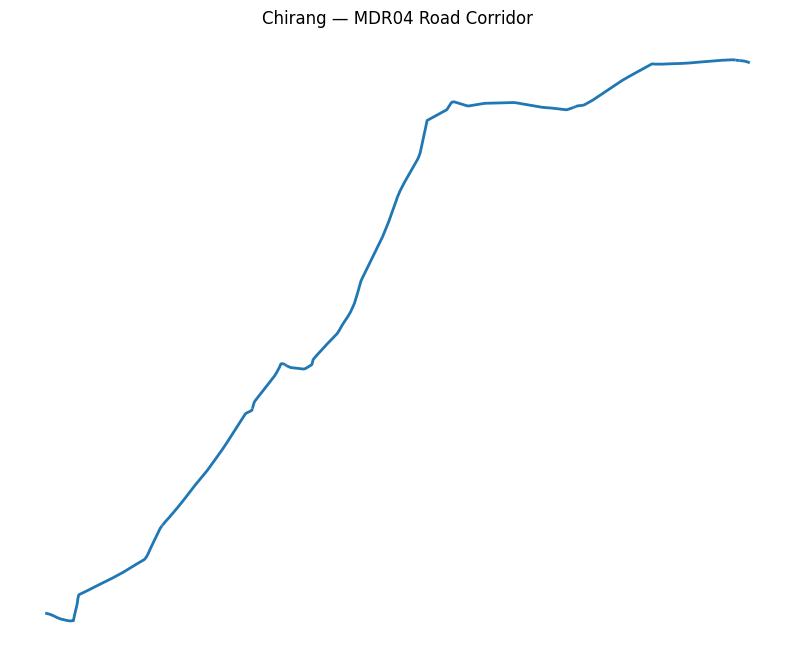

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

bijni_mdr04.plot(
    ax=ax,
    linewidth=2
)

ax.set_title("Chirang — MDR04 Road Corridor")
ax.set_axis_off()

plt.show()

In [ ]:
bijni_mdr04 = roads_with_district[
    (
        roads_with_district["district"]
        .str.lower()
        .eq("chirang")
    )
    &
    (
        roads_with_district["ref"]
        .fillna("")
        .str.upper()
        .str.contains("MDR04", regex=False)
    )
].copy()

print("MDR04 segments in Chirang:", len(bijni_mdr04))

print(
    bijni_mdr04[
        ["osm_id", "name", "ref", "fclass", "length_km"]
    ].to_string(index=False)
)

print(
    "Geometry length:",
    bijni_mdr04.geometry.length.sum() / 1000,
    "km"
)

MDR04 segments in Chirang: 11
    osm_id                             name   ref    fclass  length_km
 610288908 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   8.482111
1285775354 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.193796
1285775381 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.076051
1285775382 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   3.202367
1285775383 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.046639
1286383378 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.026273
1286383379 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   2.753839
1286383381 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.013930
1286383382 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   1.061463
1286383385 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.042652
1286383386 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   3.136233
Geometry length: 19.035352885585166 km


In [ ]:
# ============================================================
# BIJNI-PANBARI MDR04 CORRIDOR GEOMETRY
# ============================================================

print("Number of segments:", len(bijni_mdr04))

print(
    "Total geometry length:",
    bijni_mdr04.geometry.length.sum() / 1000,
    "km"
)

print("\nBounds:")
print(bijni_mdr04.total_bounds)

print("\nSegment centroids:")
centroids = bijni_mdr04.copy()
centroids["centroid"] = centroids.geometry.centroid

print(
    centroids[
        ["osm_id", "name", "ref", "length_km", "centroid"]
    ].to_string(index=False)
)

Number of segments: 11
Total geometry length: 19.035352885585166 km

Bounds:
[ 270840.99230746 2932946.62727968  283976.78509895 2943408.92317426]

Segment centroids:
    osm_id                             name   ref  length_km                       centroid
 610288908 Road Bijnigaon Bhetagaon Panbari MDR04   8.482111 POINT (277698.294 2940687.664)
1285775354 Road Bijnigaon Bhetagaon Panbari MDR04   0.193796 POINT (283884.424 2943378.751)
1285775381 Road Bijnigaon Bhetagaon Panbari MDR04   0.076051 POINT (283751.373 2943398.357)
1285775382 Road Bijnigaon Bhetagaon Panbari MDR04   3.202367 POINT (282173.512 2943135.144)
1285775383 Road Bijnigaon Bhetagaon Panbari MDR04   0.046639  POINT (280711.34 2942528.999)
1286383378 Road Bijnigaon Bhetagaon Panbari MDR04   0.026273 POINT (273022.371 2934725.277)
1286383379 Road Bijnigaon Bhetagaon Panbari MDR04   2.753839 POINT (273879.745 2935817.204)
1286383381 Road Bijnigaon Bhetagaon Panbari MDR04   0.013930 POINT (274704.488 2936909.827)
12863

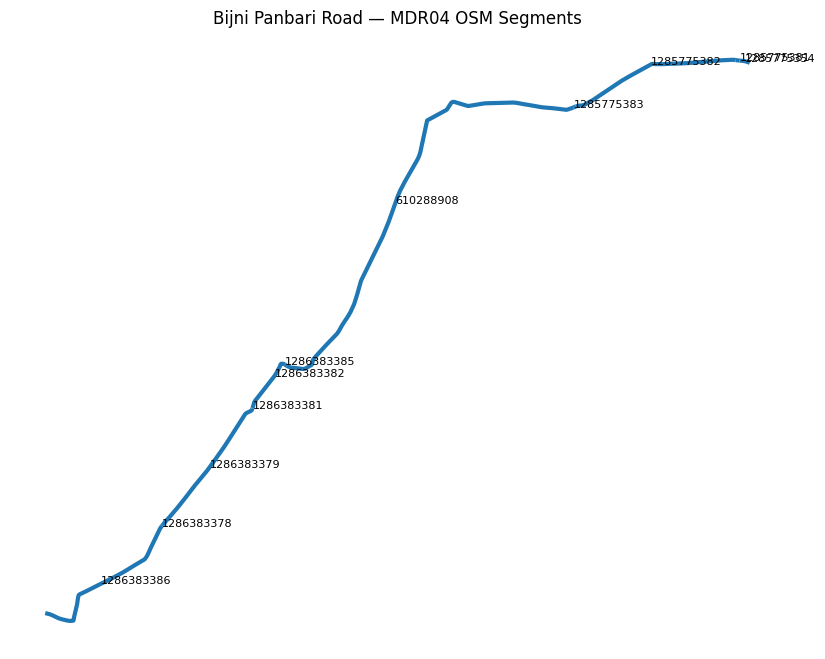

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

bijni_mdr04.plot(
    ax=ax,
    linewidth=3
)

# Label each segment with its OSM ID
for _, row in bijni_mdr04.iterrows():
    point = row.geometry.representative_point()

    ax.annotate(
        str(row["osm_id"]),
        (point.x, point.y),
        fontsize=8
    )

ax.set_title("Bijni Panbari Road — MDR04 OSM Segments")
ax.set_axis_off()

plt.show()

In [ ]:
# Check whether the 11 MDR04 segments connect to each other

from shapely.ops import unary_union

merged_mdr04 = unary_union(bijni_mdr04.geometry)

print("Geometry type:", merged_mdr04.geom_type)

if merged_mdr04.geom_type == "LineString":
    print("Result: single continuous LineString")
elif merged_mdr04.geom_type == "MultiLineString":
    print("Result: multiple disconnected LineStrings")
    print("Number of parts:", len(merged_mdr04.geoms))

Geometry type: MultiLineString
Result: multiple disconnected LineStrings
Number of parts: 11


In [ ]:
historical_road_matches = pd.DataFrame([
    {
        "event_year": 2021,
        "historical_road": "Bijni Panbari Road",
        "district": "Chirang",
        "osm_ref": "MDR04",
        "osm_name": "Road Bijnigaon Bhetagaon Panbari",
        "osm_ids": bijni_mdr04["osm_id"].tolist(),
        "matched_length_km": bijni_mdr04.geometry.length.sum() / 1000,
        "match_type": "corridor",
        "match_confidence": "strong",
        "label_confidence": "not_exact_segment"
    }
])

print(historical_road_matches.T)

                                                                   0
event_year                                                      2021
historical_road                                   Bijni Panbari Road
district                                                     Chirang
osm_ref                                                        MDR04
osm_name                            Road Bijnigaon Bhetagaon Panbari
osm_ids            [610288908, 1285775354, 1285775381, 1285775382...
matched_length_km                                          19.035353
match_type                                                  corridor
match_confidence                                              strong
label_confidence                                   not_exact_segment


In [ ]:
from shapely.strtree import STRtree

geoms = list(bijni_mdr04.geometry)

tree = STRtree(geoms)

connections = []

for i, geom in enumerate(geoms):
    nearby = tree.query(geom)

    for j in nearby:
        j = int(j)

        if i >= j:
            continue

        distance_m = geom.distance(geoms[j])

        connections.append({
            "osm_id_1": bijni_mdr04.iloc[i]["osm_id"],
            "osm_id_2": bijni_mdr04.iloc[j]["osm_id"],
            "distance_m": distance_m
        })

connections_df = pd.DataFrame(connections)

print("Potential segment pairs:", len(connections_df))

print(
    connections_df
    .sort_values("distance_m")
    .head(30)
    .to_string(index=False)
)

Potential segment pairs: 10
  osm_id_1   osm_id_2  distance_m
 610288908 1286383385         0.0
 610288908 1285775383         0.0
1285775354 1285775381         0.0
1285775381 1285775382         0.0
1285775382 1285775383         0.0
1286383378 1286383386         0.0
1286383378 1286383379         0.0
1286383379 1286383381         0.0
1286383381 1286383382         0.0
1286383382 1286383385         0.0


In [ ]:
print(
    "Largest nearby-segment gap:",
    connections_df["distance_m"].max(),
    "meters"
)

Largest nearby-segment gap: 0.0 meters


In [ ]:
import networkx as nx

G_mdr04 = nx.Graph()

for _, row in bijni_mdr04.iterrows():
    G_mdr04.add_node(row["osm_id"])

# Connect segments that touch or are very close
for _, row in connections_df.iterrows():

    if row["distance_m"] <= 10:
        G_mdr04.add_edge(
            row["osm_id_1"],
            row["osm_id_2"]
        )

components = list(nx.connected_components(G_mdr04))

print("Number of connected groups:", len(components))

for i, component in enumerate(components, 1):
    print(
        f"Group {i}: {len(component)} segments"
    )

Number of connected groups: 1
Group 1: 11 segments


In [ ]:
# ============================================================
# BOLAHI → BALIPUKHURI: SEARCH Lakhimpur OSM ROADS
# ============================================================

lakhimpur_roads = roads_with_district[
    roads_with_district["district"]
    .str.lower()
    .eq("lakhimpur")
].copy()

keywords = [
    "bolahi",
    "balipukhuri",
    "bihpuria",
    "bihpur",
    "lakhimpur",
    "narayanpur",
    "laluk",
    "bantow",
    "bangali"
]

pattern = "|".join(keywords)

matches = lakhimpur_roads[
    lakhimpur_roads["name"]
    .fillna("")
    .str.lower()
    .str.contains(pattern, regex=True)
    |
    lakhimpur_roads["ref"]
    .fillna("")
    .str.lower()
    .str.contains(pattern, regex=True)
].copy()

print("Matching Lakhimpur roads:", len(matches))

print(
    matches[
        [
            "osm_id",
            "name",
            "ref",
            "fclass",
            "length_km"
        ]
    ].to_string(index=False)
)

Matching Lakhimpur roads: 15
    osm_id                           name  ref   fclass  length_km
  69412780 Narayanpur-Bihpuria-Laluk Road SH43  primary   3.610632
 327025154               Lakhimpur Bypass NH15    trunk   4.471579
 520105399            Bantow Bangali Path      tertiary   4.545249
 978242941               Lakhimpur Bypass NH15    trunk   6.074420
 978242965               Lakhimpur Bypass         trunk   0.006844
1120732758 Narayanpur-Bihpuria-Laluk Road SH43  primary   0.099421
1120732759 Narayanpur-Bihpuria-Laluk Road SH43  primary   0.510138
1120732760 Narayanpur-Bihpuria-Laluk Road SH43  primary   0.024614
1120732761 Narayanpur-Bihpuria-Laluk Road SH43  primary   4.553430
1127451797 Narayanpur-Bihpuria-Laluk Road SH43  primary   0.345749
1127451798 Narayanpur-Bihpuria-Laluk Road SH43  primary   0.013555
1127463578 Narayanpur-Bihpuria-Laluk Road SH43  primary   1.273152
1127463579 Narayanpur-Bihpuria-Laluk Road SH43  primary   0.054684
1127466758 Narayanpur-Bihpuria-La

In [ ]:
print(
    lakhimpur_roads[
        lakhimpur_roads["ref"].notna()
    ][
        [
            "osm_id",
            "name",
            "ref",
            "fclass",
            "length_km"
        ]
    ].to_string(index=False)
)

    osm_id                           name  ref        fclass  length_km
  69412780 Narayanpur-Bihpuria-Laluk Road SH43       primary   3.610632
 155248829                                NH15         trunk  13.552186
 155248830                                NH15         trunk   0.196078
 155248834                                          tertiary   1.752475
 157598097               Ranganadi Bridge NH15         trunk   0.206087
 157598098                                         secondary   1.703878
 157598102               Old College Road           tertiary   0.987338
 157598104                    Nakari Road           tertiary   3.557340
 157598107                                          tertiary   7.416184
 157598109              Daily Bazaar Road           tertiary   0.588200
 157598110             Girls' School Road           tertiary   0.556331
 157598125            District Court Road           tertiary   0.498044
 158014334                                NH15         trunk   1

In [ ]:
broad_keywords = [
    "bolahi",
    "balipukhuri",
    "sonari chapori",
    "sapekhati",
    "sapekhati road",
    "sonari"
]

pattern = "|".join(broad_keywords)

broad_matches = roads_with_district[
    roads_with_district["name"]
    .fillna("")
    .str.lower()
    .str.contains(pattern, regex=True)
].copy()

print("Broad OSM matches:", len(broad_matches))

print(
    broad_matches[
        [
            "osm_id",
            "name",
            "ref",
            "fclass",
            "district",
            "length_km"
        ]
    ].to_string(index=False)
)

Broad OSM matches: 2
   osm_id          name    ref  fclass  district  length_km
 97952047   Sonari Road SH-008 primary Charaideo   2.183986
384589329 SONARI DOLONG NH702C   trunk Charaideo   0.081970


In [ ]:
import geopandas as gpd
import pandas as pd
import re

# Full Assam road network
full_roads = gpd.read_file("/content/assam_road_routing.gpkg")

print("Shape:", full_roads.shape)
print("CRS:", full_roads.crs)
print("Columns:")
print(full_roads.columns.tolist())

Shape: (13093, 17)
CRS: EPSG:32646
Columns:
['osm_id', 'code', 'fclass', 'name', 'ref', 'oneway', 'maxspeed', 'layer', 'bridge', 'tunnel', 'length_km', 'estimated_speed_kmh', 'bridge_flag', 'tunnel_flag', 'routing_speed_kmh', 'travel_time_min', 'geometry']


In [ ]:
# Search road names
bolahi_name_matches = full_roads[
    full_roads["name"]
    .fillna("")
    .str.lower()
    .str.contains(
        r"bolahi|balipukhuri|balipukhuri",
        regex=True
    )
].copy()

print("Name matches:", len(bolahi_name_matches))

print(
    bolahi_name_matches[
        ["osm_id", "name", "ref", "fclass"]
    ].to_string(index=False)
)

Name matches: 0
Empty DataFrame
Columns: [osm_id, name, ref, fclass]
Index: []


In [ ]:
bolahi_ref_matches = full_roads[
    full_roads["ref"]
    .fillna("")
    .str.lower()
    .str.contains(
        r"bolahi|balipukhuri|balipukhuri",
        regex=True
    )
].copy()

print("Reference matches:", len(bolahi_ref_matches))

print(
    bolahi_ref_matches[
        ["osm_id", "name", "ref", "fclass"]
    ].to_string(index=False)
)

Reference matches: 0
Empty DataFrame
Columns: [osm_id, name, ref, fclass]
Index: []


In [ ]:
lakhimpur_keywords = (
    "bolahi|balipukhuri|"
    "sonari|chapori|"
    "sapekhati|"
    "bihpuria|bihpur|"
    "narayanpur|laluk"
)

lakhimpur_name_matches = full_roads[
    full_roads["name"]
    .fillna("")
    .str.lower()
    .str.contains(
        lakhimpur_keywords,
        regex=True
    )
].copy()

print("Related-name matches:", len(lakhimpur_name_matches))

print(
    lakhimpur_name_matches[
        ["osm_id", "name", "ref", "fclass"]
    ]
    .sort_values(["name", "ref"])
    .to_string(index=False)
)

Related-name matches: 13
    osm_id                           name    ref  fclass
  69412780 Narayanpur-Bihpuria-Laluk Road   SH43 primary
1120732758 Narayanpur-Bihpuria-Laluk Road   SH43 primary
1120732759 Narayanpur-Bihpuria-Laluk Road   SH43 primary
1120732760 Narayanpur-Bihpuria-Laluk Road   SH43 primary
1120732761 Narayanpur-Bihpuria-Laluk Road   SH43 primary
1127451797 Narayanpur-Bihpuria-Laluk Road   SH43 primary
1127451798 Narayanpur-Bihpuria-Laluk Road   SH43 primary
1127463578 Narayanpur-Bihpuria-Laluk Road   SH43 primary
1127463579 Narayanpur-Bihpuria-Laluk Road   SH43 primary
1127466758 Narayanpur-Bihpuria-Laluk Road   SH43 primary
1127466759 Narayanpur-Bihpuria-Laluk Road   SH43 primary
 384589329                  SONARI DOLONG NH702C   trunk
  97952047                    Sonari Road SH-008 primary


In [ ]:
districts = gpd.read_file(
    "/content/assam_districts_assam.gpkg"
)

print(districts.columns.tolist())
print(districts[districts["name"].str.contains(
    "Lakhimpur",
    case=False,
    na=False
)][["name"]])

['osm_id', 'code', 'fclass', 'name', 'geometry']
         name
11  Lakhimpur


In [ ]:
lakhimpur = districts[
    districts["name"].str.lower() == "lakhimpur"
].copy()

lakhimpur = lakhimpur.to_crs(full_roads.crs)

lakhimpur_roads = gpd.sjoin(
    full_roads,
    lakhimpur[["name", "geometry"]],
    how="inner",
    predicate="intersects"
)

print("Lakhimpur full-road features:", len(lakhimpur_roads))

Lakhimpur full-road features: 560


In [ ]:
lakhimpur_candidates = lakhimpur_roads[
    lakhimpur_roads["name_left"]
    .fillna("")
    .str.lower()
    .str.contains(
        r"bolahi|balipukhuri|"
        r"sonari|chapori|"
        r"sapekhati|"
        r"bihpuria|bihpur|"
        r"narayanpur|laluk",
        regex=True
    )
].copy()

print(
    lakhimpur_candidates[
        ["osm_id", "name_left", "ref", "fclass"]
    ].to_string(index=False)
)

    osm_id                      name_left  ref  fclass
  69412780 Narayanpur-Bihpuria-Laluk Road SH43 primary
1120732758 Narayanpur-Bihpuria-Laluk Road SH43 primary
1120732759 Narayanpur-Bihpuria-Laluk Road SH43 primary
1120732760 Narayanpur-Bihpuria-Laluk Road SH43 primary
1120732761 Narayanpur-Bihpuria-Laluk Road SH43 primary
1127451797 Narayanpur-Bihpuria-Laluk Road SH43 primary
1127451798 Narayanpur-Bihpuria-Laluk Road SH43 primary
1127463578 Narayanpur-Bihpuria-Laluk Road SH43 primary
1127463579 Narayanpur-Bihpuria-Laluk Road SH43 primary
1127466758 Narayanpur-Bihpuria-Laluk Road SH43 primary
1127466759 Narayanpur-Bihpuria-Laluk Road SH43 primary


In [ ]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

# ---------------------------------------------------------
# STEP 5: Spatial search around historical Bolahi-Balipukhuri
# ---------------------------------------------------------

# Full Assam road network is already loaded as:
# full_roads

# Historical road is under Ghilamara / Dhakuakhana area.
# Tamulibali Pukhuri N.C. is the relevant Balipukhuri-area
# locality in the Ghilamara/Subansiri Pt-I area.
#
# Approximate coordinate from locality data:
# 27.248044 N, 94.382982 E

balipukhuri_point = gpd.GeoDataFrame(
    {
        "location": ["Balipukhuri_Ghilamara"]
    },
    geometry=[Point(94.382982, 27.248044)],
    crs="EPSG:4326"
)

# Project to metric CRS
roads_utm = full_roads.to_crs("EPSG:32646")
balipukhuri_utm = balipukhuri_point.to_crs("EPSG:32646")

# ---------------------------------------------------------
# Find roads within 3 km
# ---------------------------------------------------------

nearby_roads = gpd.sjoin_nearest(
    roads_utm,
    balipukhuri_utm,
    how="inner",
    distance_col="distance_m"
)

nearby_roads = nearby_roads.sort_values("distance_m")

print("Roads found near Balipukhuri:", len(nearby_roads))

print(
    nearby_roads[
        [
            "osm_id",
            "name",
            "ref",
            "fclass",
            "distance_m"
        ]
    ]
    .head(50)
    .to_string(index=False)
)

Roads found near Balipukhuri: 13093
    osm_id name  ref    fclass  distance_m
 230344987            tertiary  666.119140
 615470777            tertiary  695.678232
 615470772            tertiary  758.563476
1348065212      SH42   primary 4554.684803
 287765373      SH42   primary 4632.741867
1078798155      SH42   primary 4657.202669
1078798156      SH42   primary 4688.329137
1078798157      SH42   primary 4696.425564
 230344972           secondary 5169.113336
 230345051            tertiary 5335.702724
1080258886           secondary 5698.163694
1080258891           secondary 5705.531395
1080258890            tertiary 5708.970156
 965124877           secondary 5786.169842
 965124876           secondary 5786.169842
1080258889           secondary 5833.191985
1080258888           secondary 5862.027507
1080258894           secondary 5987.489437
1080258887           secondary 5990.641569
 965124875           secondary 6131.248974
1080258892           secondary 6162.313558
1080258893        

In [ ]:
# ---------------------------------------------------------
# STEP 6: Inspect road types near Balipukhuri
# ---------------------------------------------------------

print(
    nearby_roads[
        ["osm_id", "name", "ref", "fclass", "distance_m"]
    ]
    .head(100)
    .to_string(index=False)
)

    osm_id name  ref    fclass   distance_m
 230344987            tertiary   666.119140
 615470777            tertiary   695.678232
 615470772            tertiary   758.563476
1348065212      SH42   primary  4554.684803
 287765373      SH42   primary  4632.741867
1078798155      SH42   primary  4657.202669
1078798156      SH42   primary  4688.329137
1078798157      SH42   primary  4696.425564
 230344972           secondary  5169.113336
 230345051            tertiary  5335.702724
1080258886           secondary  5698.163694
1080258891           secondary  5705.531395
1080258890            tertiary  5708.970156
 965124877           secondary  5786.169842
 965124876           secondary  5786.169842
1080258889           secondary  5833.191985
1080258888           secondary  5862.027507
1080258894           secondary  5987.489437
1080258887           secondary  5990.641569
 965124875           secondary  6131.248974
1080258892           secondary  6162.313558
1080258893           secondary  

In [ ]:
print(
    nearby_roads["fclass"]
    .value_counts()
)

fclass
tertiary          5931
trunk             2859
secondary         2042
primary           1828
trunk_link         287
primary_link        52
secondary_link      50
tertiary_link       44
Name: count, dtype: int64


In [ ]:
# Keep roads within 3 km
balipukhuri_candidates = nearby_roads[
    nearby_roads["distance_m"] <= 3000
].copy()

print(
    "Candidates within 3 km:",
    len(balipukhuri_candidates)
)

balipukhuri_candidates[
    [
        "osm_id",
        "name",
        "ref",
        "fclass",
        "distance_m",
        "geometry"
    ]
].to_file(
    "/content/balipukhuri_road_candidates.gpkg",
    layer="road_candidates",
    driver="GPKG"
)

print("Saved:")
print("/content/balipukhuri_road_candidates.gpkg")

Candidates within 3 km: 3
Saved:
/content/balipukhuri_road_candidates.gpkg


In [ ]:
# =========================================================
# STEP 8: Inspect the actual roads within 3 km
# =========================================================

# Keep only roads within 3 km
candidates = nearby_roads[
    nearby_roads["distance_m"] <= 3000
].copy()

# Print complete information
print("Number of candidates:", len(candidates))
print()

print(
    candidates[
        [
            "osm_id",
            "name",
            "ref",
            "fclass",
            "oneway",
            "maxspeed",
            "bridge",
            "tunnel",
            "distance_m"
        ]
    ]
    .sort_values("distance_m")
    .to_string(index=False)
)

Number of candidates: 3

   osm_id name ref   fclass oneway  maxspeed bridge tunnel  distance_m
230344987          tertiary      B         0      F      F  666.119140
615470777          tertiary      B         0      T      F  695.678232
615470772          tertiary      B         0      F      F  758.563476


In [ ]:
# =========================================================
# STEP 9: Calculate candidate road lengths
# =========================================================

candidates["length_km"] = (
    candidates.geometry.length / 1000
)

print(
    candidates[
        [
            "osm_id",
            "name",
            "ref",
            "fclass",
            "length_km",
            "distance_m"
        ]
    ]
    .sort_values("distance_m")
    .to_string(index=False)
)

   osm_id name ref   fclass  length_km  distance_m
230344987          tertiary   5.750794  666.119140
615470777          tertiary   0.147428  695.678232
615470772          tertiary   5.548912  758.563476


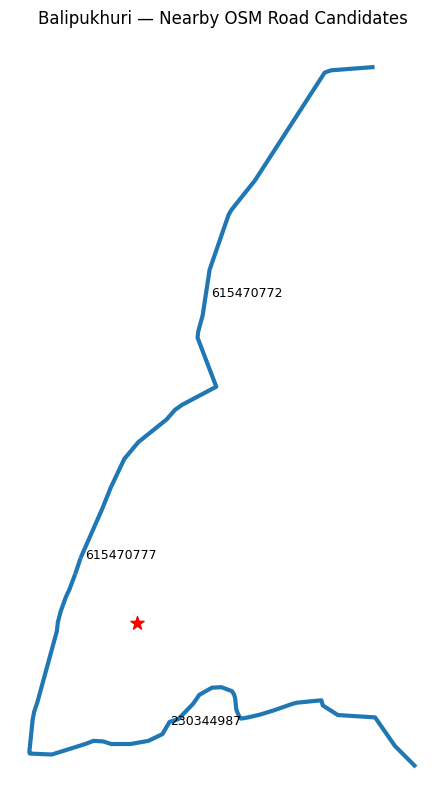

In [ ]:
# =========================================================
# STEP 10: Plot Balipukhuri + nearby candidate roads
# =========================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# Plot all candidate roads
candidates.plot(
    ax=ax,
    linewidth=3
)

# Plot Balipukhuri point
balipukhuri_utm.plot(
    ax=ax,
    color="red",
    markersize=100,
    marker="*"
)

# Label each road
for _, row in candidates.iterrows():

    point = row.geometry.interpolate(0.5, normalized=True)

    ax.annotate(
        str(row["osm_id"]),
        xy=(point.x, point.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.set_title(
    "Balipukhuri — Nearby OSM Road Candidates"
)

ax.set_axis_off()

plt.show()

In [ ]:
# =========================================================
# STEP 11: Check candidate road connectivity
# =========================================================

from shapely.strtree import STRtree

geometries = list(candidates.geometry)

tree = STRtree(geometries)

connections = []

for i, geom in enumerate(geometries):

    nearby_idx = tree.query(
        geom,
        predicate="intersects"
    )

    for j in nearby_idx:

        if i < j:

            connections.append(
                (
                    candidates.iloc[i]["osm_id"],
                    candidates.iloc[j]["osm_id"]
                )
            )

print("Intersecting candidate road pairs:")

for pair in connections:
    print(pair)

Intersecting candidate road pairs:
('230344987', '615470777')
('615470777', '615470772')


In [ ]:
# =========================================================
# STEP 12: Detailed candidate inspection
# =========================================================

for _, row in candidates.sort_values("distance_m").iterrows():

    print("=" * 70)

    print("OSM ID       :", row["osm_id"])
    print("Name         :", row["name"])
    print("Reference    :", row["ref"])
    print("Class        :", row["fclass"])
    print("Distance     :", round(row["distance_m"], 2), "m")
    print("Length       :", round(row["length_km"], 3), "km")
    print("One-way      :", row["oneway"])
    print("Max speed    :", row["maxspeed"])
    print("Bridge       :", row["bridge"])
    print("Tunnel       :", row["tunnel"])

OSM ID       : 230344987
Name         : 
Reference    : 
Class        : tertiary
Distance     : 666.12 m
Length       : 5.751 km
One-way      : B
Max speed    : 0
Bridge       : F
Tunnel       : F
OSM ID       : 615470777
Name         : 
Reference    : 
Class        : tertiary
Distance     : 695.68 m
Length       : 0.147 km
One-way      : B
Max speed    : 0
Bridge       : T
Tunnel       : F
OSM ID       : 615470772
Name         : 
Reference    : 
Class        : tertiary
Distance     : 758.56 m
Length       : 5.549 km
One-way      : B
Max speed    : 0
Bridge       : F
Tunnel       : F


In [ ]:
# =========================================================
# STEP 13: Search OSM using historical/PMGSY road clues
# =========================================================

keywords = (
    r"alimjur|"
    r"baligaon|"
    r"bolia|"
    r"pukruchu|"
    r"mrl11|"
    r"gadangarchuk|"
    r"konwarbari|"
    r"bolahi"
)

road_clue_matches = full_roads[
    full_roads["name"]
    .fillna("")
    .str.lower()
    .str.contains(keywords, regex=True)
    |
    full_roads["ref"]
    .fillna("")
    .str.lower()
    .str.contains(keywords, regex=True)
].copy()

print("Matches:", len(road_clue_matches))

print(
    road_clue_matches[
        [
            "osm_id",
            "name",
            "ref",
            "fclass",
            "oneway",
            "maxspeed"
        ]
    ]
    .to_string(index=False)
)

Matches: 0
Empty DataFrame
Columns: [osm_id, name, ref, fclass, oneway, maxspeed]
Index: []


In [ ]:
# =========================================================
# STEP 14: Search specifically for MRL11
# =========================================================

mrl11_matches = full_roads[
    (
        full_roads["name"]
        .fillna("")
        .str.lower()
        .str.contains("mrl11", regex=False)
    )
    |
    (
        full_roads["ref"]
        .fillna("")
        .str.lower()
        .str.contains("mrl11", regex=False)
    )
].copy()

print("MRL11 matches:", len(mrl11_matches))

print(
    mrl11_matches[
        [
            "osm_id",
            "name",
            "ref",
            "fclass"
        ]
    ].to_string(index=False)
)

MRL11 matches: 0
Empty DataFrame
Columns: [osm_id, name, ref, fclass]
Index: []


In [ ]:
# =========================================================
# STEP 15: Individual searches
# =========================================================

search_terms = [
    "alimjur",
    "baligaon",
    "bolia",
    "pukruchu",
    "gadangarchuk",
    "konwarbari"
]

for term in search_terms:

    result = full_roads[
        full_roads["name"]
        .fillna("")
        .str.lower()
        .str.contains(term, regex=False)
        |
        full_roads["ref"]
        .fillna("")
        .str.lower()
        .str.contains(term, regex=False)
    ]

    print("\n" + "=" * 60)
    print(term.upper(), ":", len(result))

    if len(result) > 0:
        print(
            result[
                [
                    "osm_id",
                    "name",
                    "ref",
                    "fclass"
                ]
            ]
            .head(30)
            .to_string(index=False)
        )


ALIMJUR : 0

BALIGAON : 0

BOLIA : 0

PUKRUCHU : 0

GADANGARCHUK : 0

KONWARBARI : 0


In [ ]:
# =========================================================
# STEP 16: Create Bolahi-area and Balipukhuri-area anchors
# =========================================================

from shapely.geometry import Point
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Approximate Bolahi-area anchor
# Sakpara Balahi, Ghilamara
bolahi_anchor = gpd.GeoDataFrame(
    {
        "location": ["Bolahi_area"]
    },
    geometry=[
        Point(94.395272, 27.249413)
    ],
    crs="EPSG:4326"
)

# Balipukhuri-area anchor
# Tamulibali Pukhuri N.C.
balipukhuri_anchor = gpd.GeoDataFrame(
    {
        "location": ["Balipukhuri_area"]
    },
    geometry=[
        Point(94.382982, 27.248044)
    ],
    crs="EPSG:4326"
)

# Convert to UTM
bolahi_utm = bolahi_anchor.to_crs("EPSG:32646")
balipukhuri_utm = balipukhuri_anchor.to_crs("EPSG:32646")

print("Bolahi-area:", bolahi_anchor.geometry.iloc[0])
print("Balipukhuri-area:", balipukhuri_anchor.geometry.iloc[0])

Bolahi-area: POINT (94.395272 27.249413)
Balipukhuri-area: POINT (94.382982 27.248044)


In [ ]:
# =========================================================
# STEP 17: Find roads near both endpoints
# =========================================================

roads_utm = full_roads.to_crs("EPSG:32646")

# Create 2 km search buffers
bolahi_buffer = bolahi_utm.geometry.iloc[0].buffer(2000)
balipukhuri_buffer = balipukhuri_utm.geometry.iloc[0].buffer(2000)

# Roads near Bolahi
roads_near_bolahi = roads_utm[
    roads_utm.geometry.intersects(bolahi_buffer)
].copy()

# Roads near Balipukhuri
roads_near_balipukhuri = roads_utm[
    roads_utm.geometry.intersects(balipukhuri_buffer)
].copy()

print("Roads near Bolahi:", len(roads_near_bolahi))
print("Roads near Balipukhuri:", len(roads_near_balipukhuri))

Roads near Bolahi: 3
Roads near Balipukhuri: 3


In [ ]:
# =========================================================
# STEP 18: Find roads connecting the two areas
# =========================================================

# Calculate distance from every road to each anchor
roads_utm["dist_bolahi_m"] = (
    roads_utm.geometry.distance(
        bolahi_utm.geometry.iloc[0]
    )
)

roads_utm["dist_balipukhuri_m"] = (
    roads_utm.geometry.distance(
        balipukhuri_utm.geometry.iloc[0]
    )
)

# Roads within 2 km of BOTH
connecting_candidates = roads_utm[
    (roads_utm["dist_bolahi_m"] <= 2000) &
    (roads_utm["dist_balipukhuri_m"] <= 2000)
].copy()

print(
    "Roads within 2 km of BOTH locations:",
    len(connecting_candidates)
)

print(
    connecting_candidates[
        [
            "osm_id",
            "name",
            "ref",
            "fclass",
            "dist_bolahi_m",
            "dist_balipukhuri_m"
        ]
    ]
    .sort_values(
        ["dist_bolahi_m", "dist_balipukhuri_m"]
    )
    .to_string(index=False)
)

Roads within 2 km of BOTH locations: 3
   osm_id name ref   fclass  dist_bolahi_m  dist_balipukhuri_m
230344987          tertiary     855.468311          666.119140
615470772          tertiary    1732.624376          758.563476
615470777          tertiary    1761.558281          695.678232


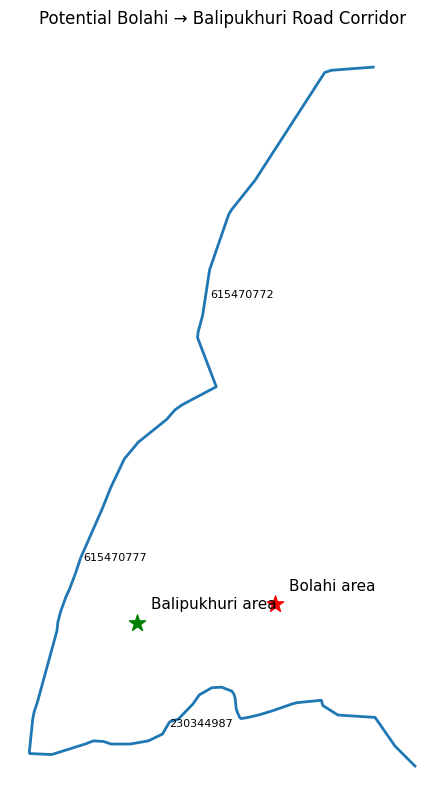

In [ ]:
# =========================================================
# STEP 19: Plot the possible Bolahi-Balipukhuri corridor
# =========================================================

fig, ax = plt.subplots(figsize=(12, 10))

# Candidate roads
connecting_candidates.plot(
    ax=ax,
    linewidth=2
)

# Bolahi
bolahi_utm.plot(
    ax=ax,
    color="red",
    marker="*",
    markersize=150
)

# Balipukhuri
balipukhuri_utm.plot(
    ax=ax,
    color="green",
    marker="*",
    markersize=150
)

# Labels
ax.annotate(
    "Bolahi area",
    (
        bolahi_utm.geometry.iloc[0].x,
        bolahi_utm.geometry.iloc[0].y
    ),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=11
)

ax.annotate(
    "Balipukhuri area",
    (
        balipukhuri_utm.geometry.iloc[0].x,
        balipukhuri_utm.geometry.iloc[0].y
    ),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=11
)

# Label OSM roads
for _, row in connecting_candidates.iterrows():

    point = row.geometry.interpolate(
        0.5,
        normalized=True
    )

    ax.annotate(
        str(row["osm_id"]),
        (point.x, point.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title(
    "Potential Bolahi → Balipukhuri Road Corridor"
)

ax.set_axis_off()

plt.show()

In [ ]:
# =========================================================
# STEP 20: Distance between the two anchors
# =========================================================

direct_distance = (
    bolahi_utm.geometry.iloc[0]
    .distance(
        balipukhuri_utm.geometry.iloc[0]
    )
)

print(
    "Straight-line distance:",
    round(direct_distance, 2),
    "meters"
)

print(
    "Straight-line distance:",
    round(direct_distance / 1000, 3),
    "km"
)

Straight-line distance: 1226.36 meters
Straight-line distance: 1.226 km


In [ ]:
# =========================================================
# STEP 21: Candidate connectivity
# =========================================================

from shapely.strtree import STRtree

candidate_geometries = list(
    connecting_candidates.geometry
)

tree = STRtree(candidate_geometries)

connections = []

for i, geom in enumerate(candidate_geometries):

    nearby_idx = tree.query(
        geom,
        predicate="intersects"
    )

    for j in nearby_idx:

        if i < j:

            connections.append(
                (
                    connecting_candidates.iloc[i]["osm_id"],
                    connecting_candidates.iloc[j]["osm_id"]
                )
            )

print("Connected road pairs:")
print(connections)

Connected road pairs:
[('230344987', '615470777'), ('615470772', '615470777')]


In [ ]:
# =========================================================
# STEP 22: Find closest point on each candidate road
# =========================================================

candidate_check = connecting_candidates.copy()

# Calculate road length from geometry
candidate_check["length_km"] = (
    candidate_check.geometry.length / 1000
)

bolahi_point = bolahi_utm.geometry.iloc[0]
balipukhuri_point = balipukhuri_utm.geometry.iloc[0]

# Closest point on each road to Bolahi
candidate_check["closest_to_bolahi"] = (
    candidate_check.geometry.apply(
        lambda geom: geom.interpolate(
            geom.project(bolahi_point)
        )
    )
)

# Closest point on each road to Balipukhuri
candidate_check["closest_to_balipukhuri"] = (
    candidate_check.geometry.apply(
        lambda geom: geom.interpolate(
            geom.project(balipukhuri_point)
        )
    )
)

# Exact distances
candidate_check["bolahi_closest_m"] = (
    candidate_check["closest_to_bolahi"]
    .apply(lambda p: p.distance(bolahi_point))
)

candidate_check["balipukhuri_closest_m"] = (
    candidate_check["closest_to_balipukhuri"]
    .apply(lambda p: p.distance(balipukhuri_point))
)

# Display
print(
    candidate_check[
        [
            "osm_id",
            "name",
            "ref",
            "fclass",
            "length_km",
            "bolahi_closest_m",
            "balipukhuri_closest_m"
        ]
    ]
    .sort_values("bolahi_closest_m")
    .to_string(index=False)
)

   osm_id name ref   fclass  length_km  bolahi_closest_m  balipukhuri_closest_m
230344987          tertiary   5.750794        855.468311             666.119140
615470772          tertiary   5.548912       1732.624376             758.563476
615470777          tertiary   0.147428       1761.558281             695.678232


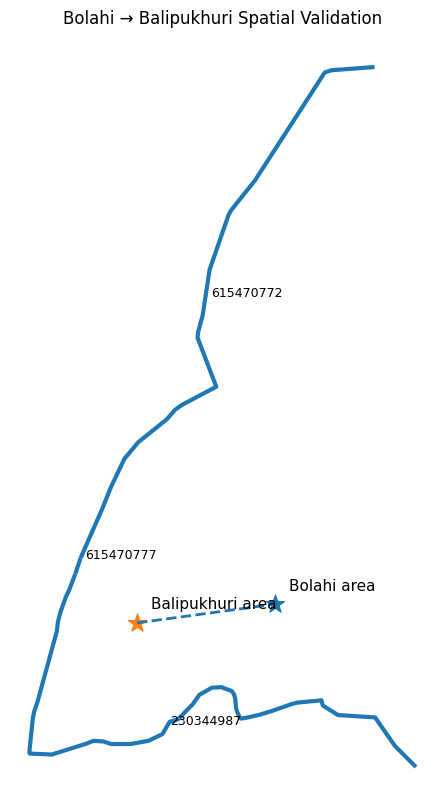

In [ ]:
# =========================================================
# STEP 23: Plot the actual candidate corridor
# =========================================================

import matplotlib.pyplot as plt
from shapely.geometry import LineString

fig, ax = plt.subplots(figsize=(12, 10))

# Candidate roads
candidate_check.plot(
    ax=ax,
    linewidth=3
)

# Anchor points
bolahi_utm.plot(
    ax=ax,
    marker="*",
    markersize=180
)

balipukhuri_utm.plot(
    ax=ax,
    marker="*",
    markersize=180
)

# Straight-line connection between anchors
anchor_line = LineString([
    bolahi_point,
    balipukhuri_point
])

gpd.GeoSeries(
    [anchor_line],
    crs="EPSG:32646"
).plot(
    ax=ax,
    linestyle="--",
    linewidth=2
)

# Labels
ax.annotate(
    "Bolahi area",
    (bolahi_point.x, bolahi_point.y),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=11
)

ax.annotate(
    "Balipukhuri area",
    (balipukhuri_point.x, balipukhuri_point.y),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=11
)

# Road IDs
for _, row in candidate_check.iterrows():

    point = row.geometry.interpolate(
        0.5,
        normalized=True
    )

    ax.annotate(
        str(row["osm_id"]),
        (point.x, point.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.set_title(
    "Bolahi → Balipukhuri Spatial Validation"
)

ax.set_axis_off()

plt.show()

In [ ]:
# =========================================================
# STEP 24: Measure candidate alignment with the corridor
# =========================================================

corridor = anchor_line.buffer(300)

candidate_check["corridor_length_km"] = (
    candidate_check.geometry
    .intersection(corridor)
    .length / 1000
)

candidate_check["corridor_percentage"] = (
    candidate_check["corridor_length_km"] /
    candidate_check["length_km"] * 100
)

print(
    candidate_check[
        [
            "osm_id",
            "length_km",
            "corridor_length_km",
            "corridor_percentage"
        ]
    ]
    .sort_values(
        "corridor_length_km",
        ascending=False
    )
    .to_string(index=False)
)

   osm_id  length_km  corridor_length_km  corridor_percentage
230344987   5.750794                 0.0                  0.0
615470772   5.548912                 0.0                  0.0
615470777   0.147428                 0.0                  0.0


In [ ]:
# =========================================================
# STEP 25: Record historical road matching status
# =========================================================

bolahi_match_result = pd.DataFrame([
    {
        "event_year": 2021,
        "historical_road": "Bolahi to Balipukhuri Road",
        "district": "Lakhimpur",

        "osm_ids": None,
        "osm_ref": None,
        "osm_name": None,

        "match_type": "unresolved",
        "match_confidence": "low",

        "reason": (
            "No exact OSM name/reference match. "
            "Spatial candidates near Bolahi/Balipukhuri "
            "did not overlap the anchor-to-anchor corridor."
        ),

        "usable_for_ml_label": False
    }
])

bolahi_match_result

,event_year,historical_road,district,osm_ids,osm_ref,osm_name,match_type,match_confidence,reason,usable_for_ml_label
0,2021,Bolahi to Balipukhuri Road,Lakhimpur,None,None,None,unresolved,low,No exact OSM name/reference match. Spatial can...,False


In [ ]:
# =========================================================
# STEP 26: Inspect our current historical road events
# =========================================================

print(
    disruption_events_raw[
        [
            "event_year",
            "event_start",
            "event_end",
            "district",
            "road_reference",
            "road_name",
            "incident_type",
            "description",
            "affected_length_km",
            "road_breach",
            "label_confidence"
        ]
    ].to_string(index=False)
)

 event_year event_start event_end   district road_reference                     road_name incident_type                                            description affected_length_km road_breach label_confidence
       2021         ...       ...  Lakhimpur            ...    Bolahi to Balipukhuri Road   road_damage                       Road affected during flood event                NaN           1           strong
       2021        None      None    Chirang           None            Bijni Panbari Road   road_damage Infrastructure damage reported during Assam flood 2021               None        None           strong
       2021        None      None    Chirang           None               Sidli ICBP Road   road_damage Infrastructure damage reported during Assam flood 2021               None        None           strong
       2021        None      None Bongaigaon           None Bongaigaon to Kirtanpara Road   road_damage Infrastructure damage reported during Assam flood 2021              

In [ ]:
# =========================================================
# STEP 27: Detailed historical road-event review
# =========================================================

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

review_columns = [
    "event_year",
    "event_start",
    "event_end",
    "district",
    "road_reference",
    "road_name",
    "incident_type",
    "description",
    "affected_length_km",
    "bridge_damage",
    "culvert_damage",
    "road_breach",
    "source_file",
    "source_page",
    "label_confidence"
]

historical_review = disruption_events_raw[
    review_columns
].copy()

print(historical_review.to_string(index=False))

 event_year event_start event_end   district road_reference                     road_name incident_type                                            description affected_length_km  bridge_damage  culvert_damage road_breach                     source_file source_page label_confidence
       2021         ...       ...  Lakhimpur            ...    Bolahi to Balipukhuri Road   road_damage                       Road affected during flood event                NaN              0               0           1 assam_flood_memorandum_2021.pdf         ...           strong
       2021        None      None    Chirang           None            Bijni Panbari Road   road_damage Infrastructure damage reported during Assam flood 2021               None              0               0        None assam_flood_memorandum_2021.pdf        None           strong
       2021        None      None    Chirang           None               Sidli ICBP Road   road_damage Infrastructure damage reported during Assam flood 

In [ ]:
# =========================================================
# STEP 28: Historical road matching status
# =========================================================

historical_matching_status = pd.DataFrame([
    {
        "road_name": "Bolahi to Balipukhuri Road",
        "district": "Lakhimpur",
        "status": "unresolved",
        "osm_ids": None,
        "confidence": "low",
        "usable_for_ml": False
    },
    {
        "road_name": "Bijni Panbari Road",
        "district": "Chirang",
        "status": "corridor_identified",
        "osm_ids": [
            610288908,
            1285775354,
            1285775381,
            1285775382,
            1285775383,
            1286383378,
            1286383379,
            1286383381,
            1286383382,
            1286383385,
            1286383386
        ],
        "confidence": "strong",
        "usable_for_ml": "review"
    },
    {
        "road_name": "Sidli ICBP Road",
        "district": "Chirang",
        "status": "unresolved",
        "osm_ids": None,
        "confidence": "low",
        "usable_for_ml": False
    },
    {
        "road_name": "Bongaigaon to Kirtanpara Road",
        "district": "Bongaigaon",
        "status": "unresolved",
        "osm_ids": None,
        "confidence": "low",
        "usable_for_ml": False
    },
    {
        "road_name": "Cachar Katigorah Road",
        "district": "Cachar",
        "status": "unresolved",
        "osm_ids": None,
        "confidence": "low",
        "usable_for_ml": False
    }
])

print(
    historical_matching_status.to_string(index=False)
)

                    road_name   district              status                                                                                                                             osm_ids confidence usable_for_ml
   Bolahi to Balipukhuri Road  Lakhimpur          unresolved                                                                                                                                None        low         False
           Bijni Panbari Road    Chirang corridor_identified [610288908, 1285775354, 1285775381, 1285775382, 1285775383, 1286383378, 1286383379, 1286383381, 1286383382, 1286383385, 1286383386]     strong        review
              Sidli ICBP Road    Chirang          unresolved                                                                                                                                None        low         False
Bongaigaon to Kirtanpara Road Bongaigaon          unresolved                                                                    

In [ ]:
# =========================================================
# STEP 29: Store Bijni Panbari corridor match
# =========================================================

bijni_osm_ids = [
    610288908,
    1285775354,
    1285775381,
    1285775382,
    1285775383,
    1286383378,
    1286383379,
    1286383381,
    1286383382,
    1286383385,
    1286383386
]

bijni_corridor = roads_with_district[
    roads_with_district["osm_id"].isin(bijni_osm_ids)
].copy()

bijni_corridor["historical_event"] = "Bijni Panbari Road"
bijni_corridor["event_year"] = 2021
bijni_corridor["historical_match"] = True
bijni_corridor["match_confidence"] = "strong"
bijni_corridor["exact_damaged_segment"] = False

print(
    bijni_corridor[
        [
            "osm_id",
            "name",
            "ref",
            "fclass",
            "length_km",
            "historical_event",
            "match_confidence",
            "exact_damaged_segment"
        ]
    ].to_string(index=False)
)

print()
print(
    "Total corridor length:",
    round(bijni_corridor["length_km"].sum(), 3),
    "km"
)

Empty DataFrame
Columns: [osm_id, name, ref, fclass, length_km, historical_event, match_confidence, exact_damaged_segment]
Index: []

Total corridor length: 0.0 km


In [ ]:
# =========================================================
# STEP 30: Save historical matching results
# =========================================================

historical_matching_status.to_csv(
    "/content/historical_road_matching_status.csv",
    index=False
)

bijni_corridor.drop(
    columns=["geometry"]
).to_csv(
    "/content/bijni_panbari_corridor_match.csv",
    index=False
)

print("Saved:")
print("/content/historical_road_matching_status.csv")
print("/content/bijni_panbari_corridor_match.csv")

Saved:
/content/historical_road_matching_status.csv
/content/bijni_panbari_corridor_match.csv


In [ ]:
# =========================================================
# STEP 29 FIX: Extract Bijni Panbari corridor
# =========================================================

# First inspect the datatype
print("roads_with_district osm_id dtype:")
print(roads_with_district["osm_id"].dtype)

print("\nExample osm_ids:")
print(roads_with_district["osm_id"].head().tolist())


# Use strings for safe matching
bijni_osm_ids = [
    "610288908",
    "1285775354",
    "1285775381",
    "1285775382",
    "1285775383",
    "1286383378",
    "1286383379",
    "1286383381",
    "1286383382",
    "1286383385",
    "1286383386"
]

roads_with_district["osm_id_str"] = (
    roads_with_district["osm_id"]
    .astype(str)
    .str.strip()
)

bijni_corridor = roads_with_district[
    roads_with_district["osm_id_str"].isin(bijni_osm_ids)
].copy()

print("\nMatched segments:", len(bijni_corridor))

print(
    bijni_corridor[
        [
            "osm_id",
            "name",
            "ref",
            "fclass",
            "length_km",
            "district"
        ]
    ].to_string(index=False)
)

print(
    "\nTotal corridor length:",
    round(bijni_corridor["length_km"].sum(), 3),
    "km"
)

roads_with_district osm_id dtype:
object

Example osm_ids:
['22826704', '22826705', '22826743', '22826807', '22826837']

Matched segments: 11
    osm_id                             name   ref    fclass  length_km district
 610288908 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   8.482111  Chirang
1285775354 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.193796  Chirang
1285775381 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.076051  Chirang
1285775382 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   3.202367  Chirang
1285775383 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.046639  Chirang
1286383378 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.026273  Chirang
1286383379 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   2.753839  Chirang
1286383381 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.013930  Chirang
1286383382 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   1.061463  Chirang
1286383385 Road Bijnigaon Bhetagaon Panbari MDR04 secondar

In [ ]:
# =========================================================
# STEP 30: Verify Bijni corridor connectivity
# =========================================================

from shapely.strtree import STRtree

geoms = list(bijni_corridor.geometry)

tree = STRtree(geoms)

connections = []

for i, geom in enumerate(geoms):

    nearby_indices = tree.query(
        geom,
        predicate="intersects"
    )

    for j in nearby_indices:

        if i < j:

            connections.append(
                (
                    bijni_corridor.iloc[i]["osm_id"],
                    bijni_corridor.iloc[j]["osm_id"]
                )
            )

print("Connected segment pairs:")
for pair in connections:
    print(pair)

print("\nNumber of connections:", len(connections))

Connected segment pairs:
('610288908', '1286383385')
('610288908', '1285775383')
('1285775354', '1285775381')
('1285775381', '1285775382')
('1285775382', '1285775383')
('1286383378', '1286383386')
('1286383378', '1286383379')
('1286383379', '1286383381')
('1286383381', '1286383382')
('1286383382', '1286383385')

Number of connections: 10


In [ ]:
# =========================================================
# STEP 31: Save verified Bijni corridor
# =========================================================

bijni_corridor[
    [
        "osm_id",
        "name",
        "ref",
        "fclass",
        "length_km",
        "district",
        "geometry"
    ]
].to_file(
    "/content/bijni_panbari_corridor.gpkg",
    layer="bijni_panbari_corridor",
    driver="GPKG"
)

print(
    "Saved: /content/bijni_panbari_corridor.gpkg"
)

Saved: /content/bijni_panbari_corridor.gpkg


In [ ]:
# =========================================================
# STEP 32: Create historical incident feature
# =========================================================

# Start from the routing road network
road_history = roads_with_district.copy()

# Initialize
road_history["previous_incidents"] = 0

# ---------------------------------------------------------
# Bijni Panbari corridor
# ---------------------------------------------------------

bijni_ids = set(
    bijni_osm_ids
)

road_history.loc[
    road_history["osm_id_str"].isin(bijni_ids),
    "previous_incidents"
] = 1

# ---------------------------------------------------------
# Inspect
# ---------------------------------------------------------

print(
    "Roads with historical incident association:",
    (road_history["previous_incidents"] > 0).sum()
)

print(
    road_history[
        road_history["previous_incidents"] > 0
    ][
        [
            "osm_id",
            "name",
            "ref",
            "district",
            "previous_incidents"
        ]
    ].to_string(index=False)
)

Roads with historical incident association: 11
    osm_id                             name   ref district  previous_incidents
 610288908 Road Bijnigaon Bhetagaon Panbari MDR04  Chirang                   1
1285775354 Road Bijnigaon Bhetagaon Panbari MDR04  Chirang                   1
1285775381 Road Bijnigaon Bhetagaon Panbari MDR04  Chirang                   1
1285775382 Road Bijnigaon Bhetagaon Panbari MDR04  Chirang                   1
1285775383 Road Bijnigaon Bhetagaon Panbari MDR04  Chirang                   1
1286383378 Road Bijnigaon Bhetagaon Panbari MDR04  Chirang                   1
1286383379 Road Bijnigaon Bhetagaon Panbari MDR04  Chirang                   1
1286383381 Road Bijnigaon Bhetagaon Panbari MDR04  Chirang                   1
1286383382 Road Bijnigaon Bhetagaon Panbari MDR04  Chirang                   1
1286383385 Road Bijnigaon Bhetagaon Panbari MDR04  Chirang                   1
1286383386 Road Bijnigaon Bhetagaon Panbari MDR04  Chirang                   1


In [ ]:
# =========================================================
# STEP 33: Historical infrastructure summary
# =========================================================

print(infrastructure_summary)

print("\nColumns:")
print(infrastructure_summary.columns.tolist())

   year event_start   event_end  pwd_roads_affected  pwd_road_length_km roads_breached  breach_length_km washed_away_spt_bridges  damaged_spt_bridges damaged_rcc_bridges  damaged_bridge_approaches  \
0  2022  2022-04-06  2022-10-28                3289             3915.00            543            15.077                       4                   72                   3                        621   
1  2023  2023-05-01  2023-10-31                1734              911.64             30             0.685                       2                   30                None                        292   
2  2024  2024-05-01  2024-10-31                2318             2261.41            237            12.180                       1                   14                None                        279   
3  2025  2025-05-01  2025-10-31                 326              468.83           None               NaN                    None                    2                None                         40   


In [ ]:
# =========================================================
# STEP 34: Prepare rainfall data
# =========================================================

print("Rainfall shape:", rainfall.shape)
print("Rainfall columns:")
print(rainfall.columns.tolist())

print("\nData types:")
print(rainfall.dtypes)

print("\nDate range:")
print(
    rainfall["Data Acquisition Time"].min(),
    "to",
    rainfall["Data Acquisition Time"].max()
)

print("\nUnique stations:", rainfall["Station"].nunique())
print("Unique districts:", rainfall["District"].nunique())

print("\nRainfall summary:")
print(
    rainfall["Manual Daily Rainfall (mm)"].describe()
)

Rainfall shape: (11270, 20)
Rainfall columns:
['SlNo', 'Station', 'Agency', 'State LGD Code', 'State', 'District LGD Code', 'District', 'Tehsil', 'Block', 'Village', 'River', 'Basin', 'Tributary', 'Subtributary', 'SubSubtributary', 'Local River', 'Latitude', 'Longitude', 'Data Acquisition Time', 'Manual Daily Rainfall (mm)']

Data types:
SlNo                            int64
Station                        object
Agency                         object
State LGD Code                  int64
State                          object
District LGD Code               int64
District                       object
Tehsil                         object
Block                          object
Village                        object
River                          object
Basin                          object
Tributary                      object
Subtributary                   object
SubSubtributary                object
Local River                    object
Latitude                      float64
Longitude     

In [ ]:
# =========================================================
# STEP 35: Convert rainfall timestamp
# =========================================================

rainfall["timestamp"] = pd.to_datetime(
    rainfall["Data Acquisition Time"],
    dayfirst=True,
    errors="coerce"
)

print("Invalid timestamps:",
      rainfall["timestamp"].isna().sum())

print(
    rainfall[
        [
            "Data Acquisition Time",
            "timestamp"
        ]
    ].head(10)
)

Invalid timestamps: 0
  Data Acquisition Time           timestamp
0      09-03-2021 08:30 2021-03-09 08:30:00
1      10-03-2021 08:30 2021-03-10 08:30:00
2      11-03-2021 08:30 2021-03-11 08:30:00
3      29-03-2021 08:30 2021-03-29 08:30:00
4      30-03-2021 08:30 2021-03-30 08:30:00
5      31-03-2021 08:30 2021-03-31 08:30:00
6      03-04-2021 08:30 2021-04-03 08:30:00
7      05-04-2021 08:30 2021-04-05 08:30:00
8      06-04-2021 08:30 2021-04-06 08:30:00
9      09-04-2021 08:30 2021-04-09 08:30:00


In [ ]:
# =========================================================
# STEP 36: Create daily station rainfall
# =========================================================

rainfall["date"] = rainfall["timestamp"].dt.date

daily_rainfall = (
    rainfall
    .groupby(
        [
            "Station",
            "District",
            "Latitude",
            "Longitude",
            "date"
        ],
        as_index=False
    )["Manual Daily Rainfall (mm)"]
    .sum()
)

daily_rainfall = daily_rainfall.rename(
    columns={
        "Manual Daily Rainfall (mm)": "rainfall_mm"
    }
)

daily_rainfall["date"] = pd.to_datetime(
    daily_rainfall["date"]
)

print("Daily rainfall shape:", daily_rainfall.shape)

print(
    daily_rainfall.head()
)

Daily rainfall shape: (11270, 6)
               Station             District   Latitude  Longitude       date  rainfall_mm
0  AWRMI Office Campus  Kamrup Metropolitan  26.102694  91.795097 2021-03-09          5.0
1  AWRMI Office Campus  Kamrup Metropolitan  26.102694  91.795097 2021-03-10          5.0
2  AWRMI Office Campus  Kamrup Metropolitan  26.102694  91.795097 2021-03-11          5.0
3  AWRMI Office Campus  Kamrup Metropolitan  26.102694  91.795097 2021-03-29          7.0
4  AWRMI Office Campus  Kamrup Metropolitan  26.102694  91.795097 2021-03-30          5.0


In [ ]:
# =========================================================
# STEP 37: Rainfall 24h / 3-day / 7-day features
# =========================================================

daily_rainfall = daily_rainfall.sort_values(
    ["Station", "date"]
).copy()

grouped = daily_rainfall.groupby(
    "Station",
    group_keys=False
)

daily_rainfall["rainfall_24h"] = (
    daily_rainfall["rainfall_mm"]
)

daily_rainfall["rainfall_3d"] = (
    grouped["rainfall_mm"]
    .rolling(3, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

daily_rainfall["rainfall_7d"] = (
    grouped["rainfall_mm"]
    .rolling(7, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

print(
    daily_rainfall[
        [
            "Station",
            "date",
            "rainfall_24h",
            "rainfall_3d",
            "rainfall_7d"
        ]
    ].head(15)
)

                Station       date  rainfall_24h  rainfall_3d  rainfall_7d
0   AWRMI Office Campus 2021-03-09           5.0          5.0          5.0
1   AWRMI Office Campus 2021-03-10           5.0         10.0         10.0
2   AWRMI Office Campus 2021-03-11           5.0         15.0         15.0
3   AWRMI Office Campus 2021-03-29           7.0         17.0         22.0
4   AWRMI Office Campus 2021-03-30           5.0         17.0         27.0
5   AWRMI Office Campus 2021-03-31           7.0         19.0         34.0
6   AWRMI Office Campus 2021-04-03           2.0         14.0         36.0
7   AWRMI Office Campus 2021-04-05           5.0         14.0         36.0
8   AWRMI Office Campus 2021-04-06           5.0         12.0         36.0
9   AWRMI Office Campus 2021-04-09           7.0         17.0         38.0
10  AWRMI Office Campus 2021-04-11           2.0         14.0         33.0
11  AWRMI Office Campus 2021-04-12           3.0         12.0         31.0
12  AWRMI Office Campus 2

In [ ]:
# =========================================================
# STEP 38: Verify rainfall year coverage
# =========================================================

print("Years present:")
print(
    rainfall["timestamp"]
    .dt.year
    .value_counts()
    .sort_index()
)

print("\nMinimum timestamp:")
print(rainfall["timestamp"].min())

print("\nMaximum timestamp:")
print(rainfall["timestamp"].max())

print("\nUnique dates:")
print(rainfall["timestamp"].dt.date.nunique())

Years present:
timestamp
2021    3968
2022    4549
2023    2753
Name: count, dtype: int64

Minimum timestamp:
2021-01-08 08:30:00

Maximum timestamp:
2023-12-14 08:30:00

Unique dates:
747


In [ ]:
# =========================================================
# STEP 39: Check rainfall coverage by station
# =========================================================

station_coverage = (
    rainfall
    .groupby("Station")
    .agg(
        start_date=("timestamp", "min"),
        end_date=("timestamp", "max"),
        observations=("timestamp", "count"),
        unique_days=("timestamp", lambda x: x.dt.date.nunique())
    )
    .reset_index()
)

print(
    station_coverage
    .sort_values("start_date")
    .to_string(index=False)
)

                   Station          start_date            end_date  observations  unique_days
                   Silghat 2021-01-08 08:30:00 2023-06-30 08:30:00           311          311
        Basbari E&D Colony 2021-01-13 08:30:00 2023-07-29 08:30:00           327          327
                Mathanguri 2021-01-13 08:30:00 2023-07-29 08:30:00           303          303
     Nalbari Office Campus 2021-01-13 08:30:00 2023-09-22 08:30:00           301          301
         Patacharkuchi PWD 2021-01-13 08:30:00 2023-09-24 08:30:00           315          315
                 Kachugaon 2021-01-19 08:30:00 2023-09-26 08:30:00           341          341
           Hatisar F. Vill 2021-01-20 08:30:00 2022-12-27 08:30:00           257          257
                Kokilamukh 2021-01-20 08:30:00 2023-06-29 08:30:00           299          299
Irrg. Divn Off. Bongaigaon 2021-01-20 08:30:00 2023-12-14 08:30:00           362          362
     Manikpur DFO Compound 2021-01-20 08:30:00 2023-12-14 08

In [ ]:
# =========================================================
# STEP 40: Rainfall temporal coverage summary
# =========================================================

print("Earliest station start:")
print(station_coverage["start_date"].min())

print("\nLatest station end:")
print(station_coverage["end_date"].max())

print("\nNumber of stations:")
print(len(station_coverage))

print("\nStations ending before the maximum date:")

print(
    station_coverage[
        station_coverage["end_date"]
        < station_coverage["end_date"].max()
    ]
    .sort_values("end_date")
    .to_string(index=False)
)

Earliest station start:
2021-01-08 08:30:00

Latest station end:
2023-12-14 08:30:00

Number of stations:
38

Stations ending before the maximum date:
                   Station          start_date            end_date  observations  unique_days
       AWRMI Office Campus 2021-03-09 08:30:00 2022-10-26 08:30:00           187          187
           Hatisar F. Vill 2021-01-20 08:30:00 2022-12-27 08:30:00           257          257
        Baghmari Tea State 2021-04-01 08:30:00 2023-04-28 08:30:00           244          244
          Dhansiri GD Site 2021-03-01 08:30:00 2023-04-30 08:30:00           226          226
           Barnadi GD Site 2021-03-10 08:30:00 2023-05-28 08:30:00           144          144
                  Rajabari 2021-01-20 08:30:00 2023-06-29 08:30:00           332          332
                Kokilamukh 2021-01-20 08:30:00 2023-06-29 08:30:00           299          299
                   Silghat 2021-01-08 08:30:00 2023-06-30 08:30:00           311          311
Bar

In [ ]:
# =========================================================
# STEP 41: Check rainfall date gaps by station
# =========================================================

gap_summary = []

for station, group in daily_rainfall.groupby("Station"):

    dates = (
        group["date"]
        .sort_values()
        .drop_duplicates()
    )

    gaps = dates.diff().dt.days.dropna()

    gap_summary.append({
        "Station": station,
        "start_date": dates.min(),
        "end_date": dates.max(),
        "observed_days": len(dates),
        "max_gap_days": gaps.max(),
        "gaps_over_1_day": (gaps > 1).sum()
    })

gap_summary = pd.DataFrame(gap_summary)

print(
    gap_summary
    .sort_values("max_gap_days", ascending=False)
    .to_string(index=False)
)

                   Station start_date   end_date  observed_days  max_gap_days  gaps_over_1_day
       AWRMI Office Campus 2021-03-09 2022-10-26            187         186.0               73
             Basugaon ENDQ 2021-01-20 2023-09-25            341         157.0              100
           Barnadi GD Site 2021-03-10 2023-05-28            144         153.0               69
                Chapar PHC 2021-03-29 2023-09-25            288         141.0              100
         Golokganj RG Site 2021-03-11 2023-09-26            334         141.0               99
        Basbari E&D Colony 2021-01-13 2023-07-29            327         129.0              106
                Mathanguri 2021-01-13 2023-07-29            303         121.0               96
  Balbala GP Office Campus 2021-03-11 2023-09-27            233         121.0              116
Barpeta Road Inv. WR Divn  2021-02-28 2023-06-30            239         119.0              109
        Boko Circle Office 2021-03-06 2023-09-25  

In [ ]:
# =========================================================
# STEP 42: Recalculate rainfall features using
# calendar-time windows
# =========================================================

daily_rainfall = daily_rainfall.sort_values(
    ["Station", "date"]
).copy()

# Remove previous calculations if they exist
for col in [
    "rainfall_24h",
    "rainfall_3d",
    "rainfall_7d"
]:
    if col in daily_rainfall.columns:
        daily_rainfall.drop(
            columns=col,
            inplace=True
        )

# Calculate time-based rolling rainfall
def calculate_rainfall_features(group):

    group = group.sort_values("date").copy()

    group = group.set_index("date")

    # Today's rainfall
    group["rainfall_24h"] = (
        group["rainfall_mm"]
    )

    # Previous 3 calendar days including today
    group["rainfall_3d"] = (
        group["rainfall_mm"]
        .rolling("3D", min_periods=1)
        .sum()
    )

    # Previous 7 calendar days including today
    group["rainfall_7d"] = (
        group["rainfall_mm"]
        .rolling("7D", min_periods=1)
        .sum()
    )

    group = group.reset_index()

    return group


daily_rainfall = (
    daily_rainfall
    .groupby(
        "Station",
        group_keys=False
    )
    .apply(
        calculate_rainfall_features,
        include_groups=True
    )
    .reset_index(drop=True)
)

print(
    daily_rainfall[
        [
            "Station",
            "date",
            "rainfall_24h",
            "rainfall_3d",
            "rainfall_7d"
        ]
    ].head(20)
)

                Station       date  rainfall_24h  rainfall_3d  rainfall_7d
0   AWRMI Office Campus 2021-03-09           5.0          5.0          5.0
1   AWRMI Office Campus 2021-03-10           5.0         10.0         10.0
2   AWRMI Office Campus 2021-03-11           5.0         15.0         15.0
3   AWRMI Office Campus 2021-03-29           7.0          7.0          7.0
4   AWRMI Office Campus 2021-03-30           5.0         12.0         12.0
5   AWRMI Office Campus 2021-03-31           7.0         19.0         19.0
6   AWRMI Office Campus 2021-04-03           2.0          2.0         21.0
7   AWRMI Office Campus 2021-04-05           5.0          7.0         19.0
8   AWRMI Office Campus 2021-04-06           5.0         10.0         19.0
9   AWRMI Office Campus 2021-04-09           7.0          7.0         19.0
10  AWRMI Office Campus 2021-04-11           2.0          9.0         19.0
11  AWRMI Office Campus 2021-04-12           3.0          5.0         17.0
12  AWRMI Office Campus 2

/tmp/ipykernel_1384/2219490477.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [ ]:
# =========================================================
# STEP 43: Validate rainfall features
# =========================================================

print(
    daily_rainfall[
        [
            "rainfall_24h",
            "rainfall_3d",
            "rainfall_7d"
        ]
    ].describe()
)

print("\nMissing values:")

print(
    daily_rainfall[
        [
            "rainfall_24h",
            "rainfall_3d",
            "rainfall_7d"
        ]
    ].isna().sum()
)

       rainfall_24h   rainfall_3d   rainfall_7d
count  11270.000000  11270.000000  11270.000000
mean      28.513790     68.904501    132.840520
std       39.715577     93.207148    170.459746
min        0.010000      0.010000      0.010000
25%        5.080000     14.205000     33.002500
50%       15.000000     37.800000     76.200000
75%       34.000000     83.200000    162.750000
max      504.800000    891.540000   1910.080000

Missing values:
rainfall_24h    0
rainfall_3d     0
rainfall_7d     0
dtype: int64


In [ ]:
# =========================================================
# STEP 44: Manual rainfall feature verification
# =========================================================

station_name = daily_rainfall["Station"].iloc[0]

check = (
    daily_rainfall[
        daily_rainfall["Station"] == station_name
    ]
    .sort_values("date")
    .head(20)
)

print(
    check[
        [
            "Station",
            "date",
            "rainfall_mm",
            "rainfall_24h",
            "rainfall_3d",
            "rainfall_7d"
        ]
    ].to_string(index=False)
)

            Station       date  rainfall_mm  rainfall_24h  rainfall_3d  rainfall_7d
AWRMI Office Campus 2021-03-09          5.0           5.0          5.0          5.0
AWRMI Office Campus 2021-03-10          5.0           5.0         10.0         10.0
AWRMI Office Campus 2021-03-11          5.0           5.0         15.0         15.0
AWRMI Office Campus 2021-03-29          7.0           7.0          7.0          7.0
AWRMI Office Campus 2021-03-30          5.0           5.0         12.0         12.0
AWRMI Office Campus 2021-03-31          7.0           7.0         19.0         19.0
AWRMI Office Campus 2021-04-03          2.0           2.0          2.0         21.0
AWRMI Office Campus 2021-04-05          5.0           5.0          7.0         19.0
AWRMI Office Campus 2021-04-06          5.0           5.0         10.0         19.0
AWRMI Office Campus 2021-04-09          7.0           7.0          7.0         19.0
AWRMI Office Campus 2021-04-11          2.0           2.0          9.0      

In [ ]:
# =========================================================
# STEP 45: Build calendar-based rainfall features
# =========================================================

# Keep the original daily observations
rainfall_base = daily_rainfall[
    [
        "Station",
        "District",
        "Latitude",
        "Longitude",
        "date",
        "rainfall_mm"
    ]
].copy()

rainfall_base["date"] = pd.to_datetime(
    rainfall_base["date"]
)

rainfall_base = rainfall_base.sort_values(
    ["Station", "date"]
)

print("Original observations:", len(rainfall_base))
print(
    "Date range:",
    rainfall_base["date"].min(),
    "to",
    rainfall_base["date"].max()
)

Original observations: 11270
Date range: 2021-01-08 00:00:00 to 2023-12-14 00:00:00


In [ ]:
# =========================================================
# STEP 46: Reindex each station to calendar days
# =========================================================

station_daily = []

for station, group in rainfall_base.groupby("Station"):

    group = group.sort_values("date").copy()

    # Complete calendar range for this station
    date_range = pd.date_range(
        start=group["date"].min(),
        end=group["date"].max(),
        freq="D"
    )

    group = (
        group
        .set_index("date")
        .reindex(date_range)
    )

    # Restore metadata
    group["Station"] = station

    group["District"] = (
        group["District"]
        .ffill()
        .bfill()
    )

    group["Latitude"] = (
        group["Latitude"]
        .ffill()
        .bfill()
    )

    group["Longitude"] = (
        group["Longitude"]
        .ffill()
        .bfill()
    )

    group.index.name = "date"

    group = group.reset_index()

    station_daily.append(group)


station_daily = pd.concat(
    station_daily,
    ignore_index=True
)

print("Calendarized shape:", station_daily.shape)

print(
    "Missing rainfall observations:",
    station_daily["rainfall_mm"].isna().sum()
)

Calendarized shape: (34692, 6)
Missing rainfall observations: 23422


In [ ]:
# =========================================================
# STEP 47 FIX: Rebuild station_daily from rainfall_base
# =========================================================

# Start again from the clean rainfall table
base = rainfall_base.copy()

base["date"] = pd.to_datetime(base["date"])

base = base.sort_values(
    ["Station", "date"]
)

# ---------------------------------------------------------
# Create complete calendar for each station
# ---------------------------------------------------------

station_frames = []

for station, group in base.groupby("Station"):

    group = group.sort_values("date").copy()

    # Metadata values for this station
    district = group["District"].iloc[0]
    latitude = group["Latitude"].iloc[0]
    longitude = group["Longitude"].iloc[0]

    # Complete calendar
    dates = pd.date_range(
        start=group["date"].min(),
        end=group["date"].max(),
        freq="D"
    )

    # Put rainfall against complete calendar
    temp = (
        group[["date", "rainfall_mm"]]
        .drop_duplicates("date")
        .set_index("date")
        .reindex(dates)
    )

    temp.index.name = "date"

    temp = temp.reset_index()

    # Restore station metadata
    temp["Station"] = station
    temp["District"] = district
    temp["Latitude"] = latitude
    temp["Longitude"] = longitude

    station_frames.append(temp)


# Combine all stations
station_daily = pd.concat(
    station_frames,
    ignore_index=True
)

# Correct column order
station_daily = station_daily[
    [
        "Station",
        "District",
        "Latitude",
        "Longitude",
        "date",
        "rainfall_mm"
    ]
]

print("Rebuilt station_daily successfully")
print("Shape:", station_daily.shape)

print("\nColumns:")
print(station_daily.columns.tolist())

print("\nMissing rainfall observations:")
print(
    station_daily["rainfall_mm"].isna().sum()
)

print("\nPreview:")
print(
    station_daily.head(15).to_string(index=False)
)

Rebuilt station_daily successfully
Shape: (34692, 6)

Columns:
['Station', 'District', 'Latitude', 'Longitude', 'date', 'rainfall_mm']

Missing rainfall observations:
23422

Preview:
            Station            District  Latitude  Longitude       date  rainfall_mm
AWRMI Office Campus Kamrup Metropolitan 26.102694  91.795097 2021-03-09          5.0
AWRMI Office Campus Kamrup Metropolitan 26.102694  91.795097 2021-03-10          5.0
AWRMI Office Campus Kamrup Metropolitan 26.102694  91.795097 2021-03-11          5.0
AWRMI Office Campus Kamrup Metropolitan 26.102694  91.795097 2021-03-12          NaN
AWRMI Office Campus Kamrup Metropolitan 26.102694  91.795097 2021-03-13          NaN
AWRMI Office Campus Kamrup Metropolitan 26.102694  91.795097 2021-03-14          NaN
AWRMI Office Campus Kamrup Metropolitan 26.102694  91.795097 2021-03-15          NaN
AWRMI Office Campus Kamrup Metropolitan 26.102694  91.795097 2021-03-16          NaN
AWRMI Office Campus Kamrup Metropolitan 26.102694  9

In [ ]:
# =========================================================
# STEP 48: Calculate rainfall features
# =========================================================

station_daily = station_daily.sort_values(
    ["Station", "date"]
).copy()

station_daily["rainfall_24h"] = (
    station_daily["rainfall_mm"]
)

# Calculate rolling features station by station
feature_frames = []

for station, group in station_daily.groupby("Station"):

    group = group.sort_values("date").copy()

    group["rainfall_3d"] = (
        group["rainfall_mm"]
        .rolling(
            window=3,
            min_periods=3
        )
        .sum()
    )

    group["rainfall_7d"] = (
        group["rainfall_mm"]
        .rolling(
            window=7,
            min_periods=7
        )
        .sum()
    )

    feature_frames.append(group)


station_daily = pd.concat(
    feature_frames,
    ignore_index=True
)

station_daily = station_daily.sort_values(
    ["Station", "date"]
).reset_index(drop=True)


print(
    station_daily[
        [
            "Station",
            "date",
            "rainfall_mm",
            "rainfall_24h",
            "rainfall_3d",
            "rainfall_7d"
        ]
    ].head(20).to_string(index=False)
)

            Station       date  rainfall_mm  rainfall_24h  rainfall_3d  rainfall_7d
AWRMI Office Campus 2021-03-09          5.0           5.0          NaN          NaN
AWRMI Office Campus 2021-03-10          5.0           5.0          NaN          NaN
AWRMI Office Campus 2021-03-11          5.0           5.0         15.0          NaN
AWRMI Office Campus 2021-03-12          NaN           NaN          NaN          NaN
AWRMI Office Campus 2021-03-13          NaN           NaN          NaN          NaN
AWRMI Office Campus 2021-03-14          NaN           NaN          NaN          NaN
AWRMI Office Campus 2021-03-15          NaN           NaN          NaN          NaN
AWRMI Office Campus 2021-03-16          NaN           NaN          NaN          NaN
AWRMI Office Campus 2021-03-17          NaN           NaN          NaN          NaN
AWRMI Office Campus 2021-03-18          NaN           NaN          NaN          NaN
AWRMI Office Campus 2021-03-19          NaN           NaN          NaN      

In [ ]:
# =========================================================
# STEP 49: Validate rainfall features
# =========================================================

print("Total records:", len(station_daily))

print("\nAvailable records:")

print(
    "24h:",
    station_daily["rainfall_24h"].notna().sum()
)

print(
    "3d:",
    station_daily["rainfall_3d"].notna().sum()
)

print(
    "7d:",
    station_daily["rainfall_7d"].notna().sum()
)

print("\nMissing values:")

print(
    station_daily[
        [
            "rainfall_24h",
            "rainfall_3d",
            "rainfall_7d"
        ]
    ].isna().sum()
)

Total records: 34692

Available records:
24h: 11270
3d: 5037
7d: 1624

Missing values:
rainfall_24h    23422
rainfall_3d     29655
rainfall_7d     33068
dtype: int64


In [ ]:
# =========================================================
# STEP 50: Build rainfall windows with data coverage
# =========================================================

station_daily = station_daily.sort_values(
    ["Station", "date"]
).copy()

feature_frames = []

for station, group in station_daily.groupby("Station"):

    group = group.sort_values("date").copy()
    group = group.set_index("date")

    rainfall = group["rainfall_mm"]

    # -----------------------------------------------------
    # 24-hour
    # -----------------------------------------------------

    group["rainfall_24h"] = rainfall

    group["rainfall_24h_available"] = (
        rainfall.notna().astype(int)
    )

    # -----------------------------------------------------
    # 3-day window
    # -----------------------------------------------------

    group["rainfall_3d_sum"] = (
        rainfall
        .rolling("3D", min_periods=1)
        .sum()
    )

    group["rainfall_3d_obs"] = (
        rainfall
        .rolling("3D", min_periods=1)
        .count()
    )

    group["rainfall_3d_coverage"] = (
        group["rainfall_3d_obs"] / 3
    )

    # -----------------------------------------------------
    # 7-day window
    # -----------------------------------------------------

    group["rainfall_7d_sum"] = (
        rainfall
        .rolling("7D", min_periods=1)
        .sum()
    )

    group["rainfall_7d_obs"] = (
        rainfall
        .rolling("7D", min_periods=1)
        .count()
    )

    group["rainfall_7d_coverage"] = (
        group["rainfall_7d_obs"] / 7
    )

    group = group.reset_index()

    feature_frames.append(group)


station_daily = pd.concat(
    feature_frames,
    ignore_index=True
)

station_daily = station_daily.sort_values(
    ["Station", "date"]
).reset_index(drop=True)

print(
    station_daily[
        [
            "Station",
            "date",
            "rainfall_mm",
            "rainfall_24h",
            "rainfall_3d_sum",
            "rainfall_3d_obs",
            "rainfall_3d_coverage",
            "rainfall_7d_sum",
            "rainfall_7d_obs",
            "rainfall_7d_coverage"
        ]
    ].head(20).to_string(index=False)
)

            Station       date  rainfall_mm  rainfall_24h  rainfall_3d_sum  rainfall_3d_obs  rainfall_3d_coverage  rainfall_7d_sum  rainfall_7d_obs  rainfall_7d_coverage
AWRMI Office Campus 2021-03-09          5.0           5.0              5.0              1.0              0.333333              5.0              1.0              0.142857
AWRMI Office Campus 2021-03-10          5.0           5.0             10.0              2.0              0.666667             10.0              2.0              0.285714
AWRMI Office Campus 2021-03-11          5.0           5.0             15.0              3.0              1.000000             15.0              3.0              0.428571
AWRMI Office Campus 2021-03-12          NaN           NaN             10.0              2.0              0.666667             15.0              3.0              0.428571
AWRMI Office Campus 2021-03-13          NaN           NaN              5.0              1.0              0.333333             15.0              3.0   

In [ ]:
# =========================================================
# STEP 51: Inspect rainfall coverage
# =========================================================

print("Total records:", len(station_daily))

print("\n3-day coverage distribution:")
print(
    station_daily[
        "rainfall_3d_coverage"
    ].describe()
)

print("\n7-day coverage distribution:")
print(
    station_daily[
        "rainfall_7d_coverage"
    ].describe()
)

print("\nRecords with >= 2/3 days available:")

print(
    (
        station_daily["rainfall_3d_coverage"] >= 2/3
    ).sum()
)

print("\nRecords with >= 5/7 days available:")

print(
    (
        station_daily["rainfall_7d_coverage"] >= 5/7
    ).sum()
)

Total records: 34692

3-day coverage distribution:
count    34692.000000
mean         0.323888
std          0.370218
min          0.000000
25%          0.000000
50%          0.333333
75%          0.666667
max          1.000000
Name: rainfall_3d_coverage, dtype: float64

7-day coverage distribution:
count    34692.000000
mean         0.322499
std          0.313291
min          0.000000
25%          0.000000
50%          0.285714
75%          0.571429
max          1.000000
Name: rainfall_7d_coverage, dtype: float64

Records with >= 2/3 days available:
10845

Records with >= 5/7 days available:
6629


In [ ]:
# =========================================================
# STEP 52: Inspect incomplete rainfall windows
# =========================================================

examples = station_daily[
    (station_daily["rainfall_7d_obs"] < 7) &
    (station_daily["rainfall_7d_obs"] >= 3)
].copy()

print(
    examples[
        [
            "Station",
            "date",
            "rainfall_7d_sum",
            "rainfall_7d_obs",
            "rainfall_7d_coverage"
        ]
    ]
    .head(20)
    .to_string(index=False)
)

            Station       date  rainfall_7d_sum  rainfall_7d_obs  rainfall_7d_coverage
AWRMI Office Campus 2021-03-11             15.0              3.0              0.428571
AWRMI Office Campus 2021-03-12             15.0              3.0              0.428571
AWRMI Office Campus 2021-03-13             15.0              3.0              0.428571
AWRMI Office Campus 2021-03-14             15.0              3.0              0.428571
AWRMI Office Campus 2021-03-15             15.0              3.0              0.428571
AWRMI Office Campus 2021-03-31             19.0              3.0              0.428571
AWRMI Office Campus 2021-04-01             19.0              3.0              0.428571
AWRMI Office Campus 2021-04-02             19.0              3.0              0.428571
AWRMI Office Campus 2021-04-03             21.0              4.0              0.571429
AWRMI Office Campus 2021-04-04             21.0              4.0              0.571429
AWRMI Office Campus 2021-04-05             

In [ ]:
# =========================================================
# STEP 53: Create rainfall station points
# =========================================================

# Keep only actual rainfall observations
rainfall_observed = station_daily[
    station_daily["rainfall_24h"].notna()
].copy()

# One point per unique station
rainfall_stations = (
    rainfall_observed[
        [
            "Station",
            "District",
            "Latitude",
            "Longitude"
        ]
    ]
    .drop_duplicates("Station")
    .copy()
)

rainfall_stations_gdf = gpd.GeoDataFrame(
    rainfall_stations,
    geometry=gpd.points_from_xy(
        rainfall_stations["Longitude"],
        rainfall_stations["Latitude"]
    ),
    crs="EPSG:4326"
)

# Convert to same CRS as roads
rainfall_stations_utm = rainfall_stations_gdf.to_crs(
    roads_with_district.crs
)

print(
    "Number of rainfall stations:",
    len(rainfall_stations_utm)
)

print(
    rainfall_stations_utm[
        [
            "Station",
            "District",
            "Latitude",
            "Longitude"
        ]
    ].to_string(index=False)
)

Number of rainfall stations: 38
                   Station            District  Latitude  Longitude
       AWRMI Office Campus Kamrup Metropolitan 26.102694  91.795097
        Baghmari Tea State            SONITPUR 26.751161  93.228600
  Balbala GP Office Campus            GOALPARA 26.069444  90.597778
           Barnadi GD Site             DARRANG 26.380000  91.180000
     Barpeta  E & D Office             BARPETA 26.324722  91.000556
Barpeta Road Inv. WR Divn              BARPETA 26.492222  90.967778
        Basbari E&D Colony               Baksa 26.603889  90.995000
             Basugaon ENDQ             Chirang 26.459444  90.420833
                      Beki             BARPETA 26.498333  90.919167
  Bengtal State Dispensary             Chirang 26.633056  90.476389
            Bhabanipur PHE             BARPETA 26.465278  91.068889
        Boko Circle Office              KAMRUP 25.975833  91.230556
                Chapar PHC              DHUBRI 26.269722  90.444444
   Chief Eng Off

In [ ]:
# =========================================================
# STEP 54: Nearest rainfall station for every road
# =========================================================

# Copy road network
roads_rainfall = roads_with_district.copy()

# Make sure both are in the same projected CRS
roads_rainfall = roads_rainfall.to_crs(
    rainfall_stations_utm.crs
)

# Representative point of each road segment
roads_rainfall["road_point"] = (
    roads_rainfall.geometry
    .representative_point()
)

road_points = gpd.GeoDataFrame(
    roads_rainfall.drop(
        columns=["geometry"]
    ),
    geometry="road_point",
    crs=roads_rainfall.crs
)

# Find nearest rainfall station
road_rainfall_join = gpd.sjoin_nearest(
    road_points,
    rainfall_stations_utm[
        [
            "Station",
            "geometry"
        ]
    ],
    how="left",
    distance_col="rainfall_station_distance_m"
)

print(
    "Road segments:",
    len(road_rainfall_join)
)

print(
    "Missing station:",
    road_rainfall_join["Station"].isna().sum()
)

print(
    road_rainfall_join[
        [
            "osm_id",
            "name",
            "ref",
            "district",
            "Station",
            "rainfall_station_distance_m"
        ]
    ].head(20).to_string(index=False)
)

Road segments: 13093
Missing station: 0
  osm_id               name      ref            district                  Station  rainfall_station_distance_m
22826704          ONGC Road                    Karimganj                    Ukiam                173918.510488
22826705                    CA-M-009              Cachar      AWRMI Office Campus                187800.789755
22826743                        SH39              Cachar      AWRMI Office Campus                186873.344393
22826807                        SH39              Cachar      AWRMI Office Campus                185634.204127
22826837       Mission Road          Hailakandi district      AWRMI Office Campus                174319.256875
22826880        HEMPI HOTEL    NH329       Karbi Anglong         Dhansiri GD Site                 93575.721120
22827116                                          Kamrup      Kulsi Forest Office                  8260.308182
22827180                        SH12            Goalpara Balbala GP Offi

In [ ]:
# =========================================================
# STEP 55: Check road-to-station distances
# =========================================================

distance_km = (
    road_rainfall_join[
        "rainfall_station_distance_m"
    ] / 1000
)

print(
    distance_km.describe()
)

print("\nRoads within 25 km:")
print(
    (distance_km <= 25).sum()
)

print("\nRoads within 50 km:")
print(
    (distance_km <= 50).sum()
)

print("\nRoads beyond 50 km:")
print(
    (distance_km > 50).sum()
)

print("\nRoads beyond 100 km:")
print(
    (distance_km > 100).sum()
)

count    13093.000000
mean        64.866432
std         60.157669
min          0.032634
25%         14.322937
50%         45.344495
75%         98.499404
max        217.652670
Name: rainfall_station_distance_m, dtype: float64

Roads within 25 km:
4863

Roads within 50 km:
6906

Roads beyond 50 km:
6187

Roads beyond 100 km:
3206


In [ ]:
# =========================================================
# STEP 56: Save road-rainfall station association
# =========================================================

road_station_map = road_rainfall_join[
    [
        "osm_id",
        "district",
        "Station",
        "rainfall_station_distance_m"
    ]
].copy()

road_station_map["rainfall_station_distance_km"] = (
    road_station_map["rainfall_station_distance_m"] / 1000
)

print(
    road_station_map.head(20).to_string(index=False)
)

print(
    "\nUnique roads:",
    road_station_map["osm_id"].nunique()
)

print(
    "Unique stations used:",
    road_station_map["Station"].nunique()
)

  osm_id            district                  Station  rainfall_station_distance_m  rainfall_station_distance_km
22826704           Karimganj                    Ukiam                173918.510488                    173.918510
22826705              Cachar      AWRMI Office Campus                187800.789755                    187.800790
22826743              Cachar      AWRMI Office Campus                186873.344393                    186.873344
22826807              Cachar      AWRMI Office Campus                185634.204127                    185.634204
22826837 Hailakandi district      AWRMI Office Campus                174319.256875                    174.319257
22826880       Karbi Anglong         Dhansiri GD Site                 93575.721120                     93.575721
22827116              Kamrup      Kulsi Forest Office                  8260.308182                      8.260308
22827180            Goalpara Balbala GP Office Campus                  9452.166833              

In [ ]:
# =========================================================
# STEP 57: Validate road-to-rainfall station distance
# =========================================================

roads_rainfall_final = road_rainfall_join.copy()

roads_rainfall_final["rainfall_station_distance_km"] = (
    roads_rainfall_final["rainfall_station_distance_m"] / 1000
)

# Flag usable rainfall association
roads_rainfall_final["rainfall_station_valid"] = (
    roads_rainfall_final["rainfall_station_distance_km"] <= 50
)

print("Total roads:",
      len(roads_rainfall_final))

print(
    "\nValid rainfall association (<= 50 km):",
    roads_rainfall_final["rainfall_station_valid"].sum()
)

print(
    "Invalid rainfall association (> 50 km):",
    (~roads_rainfall_final["rainfall_station_valid"]).sum()
)

print(
    "\nPercentage covered:",
    round(
        roads_rainfall_final["rainfall_station_valid"].mean() * 100,
        2
    ),
    "%"
)

Total roads: 13093

Valid rainfall association (<= 50 km): 6906
Invalid rainfall association (> 50 km): 6187

Percentage covered: 52.75 %


In [ ]:
# =========================================================
# STEP 58: Rainfall station coverage by district
# =========================================================

district_coverage = (
    roads_rainfall_final
    .groupby("district")
    .agg(
        road_segments=("osm_id", "count"),
        valid_rainfall_roads=(
            "rainfall_station_valid",
            "sum"
        ),
        median_station_distance_km=(
            "rainfall_station_distance_km",
            "median"
        )
    )
    .reset_index()
)

district_coverage["coverage_percent"] = (
    district_coverage["valid_rainfall_roads"] /
    district_coverage["road_segments"] * 100
)

print(
    district_coverage
    .sort_values("coverage_percent")
    .to_string(index=False)
)

               district  road_segments  valid_rainfall_roads  median_station_distance_km  coverage_percent
              Charaideo            324                     0                   85.908805          0.000000
                 Cachar           1127                     0                  173.854155          0.000000
              Dibrugarh            617                     0                  103.202926          0.000000
                Dhemaji            397                     0                   81.615902          0.000000
             Dima Hasao            331                     0                  152.280494          0.000000
    Hailakandi district            308                     0                  183.373991          0.000000
              Karimganj            467                     0                  163.363011          0.000000
               Tinsukia            431                     0                  159.599878          0.000000
                  Hojai            37

In [ ]:
# =========================================================
# STEP 59: Prepare station-date rainfall features
# =========================================================

rainfall_features = station_daily[
    [
        "Station",
        "date",
        "rainfall_24h",
        "rainfall_3d_sum",
        "rainfall_3d_obs",
        "rainfall_3d_coverage",
        "rainfall_7d_sum",
        "rainfall_7d_obs",
        "rainfall_7d_coverage"
    ]
].copy()

print(
    rainfall_features.head(10).to_string(index=False)
)

print(
    "\nRows:",
    len(rainfall_features)
)

            Station       date  rainfall_24h  rainfall_3d_sum  rainfall_3d_obs  rainfall_3d_coverage  rainfall_7d_sum  rainfall_7d_obs  rainfall_7d_coverage
AWRMI Office Campus 2021-03-09           5.0              5.0              1.0              0.333333              5.0              1.0              0.142857
AWRMI Office Campus 2021-03-10           5.0             10.0              2.0              0.666667             10.0              2.0              0.285714
AWRMI Office Campus 2021-03-11           5.0             15.0              3.0              1.000000             15.0              3.0              0.428571
AWRMI Office Campus 2021-03-12           NaN             10.0              2.0              0.666667             15.0              3.0              0.428571
AWRMI Office Campus 2021-03-13           NaN              5.0              1.0              0.333333             15.0              3.0              0.428571
AWRMI Office Campus 2021-03-14           NaN              

In [ ]:
# =========================================================
# STEP 61: Find the 3 nearest rainfall stations
# =========================================================

# Road representative points
road_points = roads_with_district.copy()

road_points["road_point"] = (
    road_points.geometry.representative_point()
)

road_points_gdf = gpd.GeoDataFrame(
    road_points.drop(columns=["geometry"]),
    geometry="road_point",
    crs=roads_with_district.crs
)

# Make sure rainfall stations use same CRS
rainfall_points = rainfall_stations_utm.copy()

# Find 3 nearest stations for every road
road_3stations = gpd.sjoin_nearest(
    road_points_gdf,
    rainfall_points[
        [
            "Station",
            "geometry"
        ]
    ],
    how="left",
    distance_col="distance_m",
    max_distance=None
)

# sjoin_nearest normally returns only the nearest station.
# So instead we'll explicitly calculate distances to all stations.

In [ ]:
# =========================================================
# STEP 62: Calculate 3 nearest rainfall stations
# =========================================================

from scipy.spatial import cKDTree
import numpy as np

# Road coordinates
road_coords = np.column_stack([
    road_points_gdf.geometry.x,
    road_points_gdf.geometry.y
])

# Station coordinates
station_coords = np.column_stack([
    rainfall_points.geometry.x,
    rainfall_points.geometry.y
])

# KD-tree
station_tree = cKDTree(station_coords)

# Find 3 nearest stations
distances, indices = station_tree.query(
    road_coords,
    k=3
)

print("Distance matrix shape:", distances.shape)
print("Example first road distances:")
print(distances[0])

Distance matrix shape: (13093, 3)
Example first road distances:
[173918.51048756 177657.50871242 180044.62711748]


In [ ]:
# =========================================================
# STEP 63: Check multi-station coverage
# =========================================================

for radius_km in [25, 50, 75, 100, 150, 200]:

    radius_m = radius_km * 1000

    # At least 1 station
    one_station = (
        distances[:, 0] <= radius_m
    )

    # At least 2 stations
    two_stations = (
        distances[:, 1] <= radius_m
    )

    # At least 3 stations
    three_stations = (
        distances[:, 2] <= radius_m
    )

    print(
        f"{radius_km:>3} km | "
        f"1 station: {one_station.sum():5d} | "
        f"2 stations: {two_stations.sum():5d} | "
        f"3 stations: {three_stations.sum():5d}"
    )

 25 km | 1 station:  4863 | 2 stations:  3302 | 3 stations:  2464
 50 km | 1 station:  6906 | 2 stations:  6088 | 3 stations:  4720
 75 km | 1 station:  8757 | 2 stations:  8005 | 3 stations:  6548
100 km | 1 station:  9887 | 2 stations:  9655 | 3 stations:  8409
150 km | 1 station: 10893 | 2 stations: 10738 | 3 stations: 10069
200 km | 1 station: 12972 | 2 stations: 12874 | 3 stations: 12574


In [ ]:
# =========================================================
# STEP 64: Inspect worst rainfall coverage
# =========================================================

coverage_check = roads_with_district[
    [
        "osm_id",
        "district",
        "name",
        "ref"
    ]
].copy()

coverage_check["nearest_1_km"] = (
    distances[:, 0] / 1000
)

coverage_check["nearest_2_km"] = (
    distances[:, 1] / 1000
)

coverage_check["nearest_3_km"] = (
    distances[:, 2] / 1000
)

print(
    coverage_check
    .sort_values("nearest_3_km", ascending=False)
    .head(30)
    .to_string(index=False)
)

    osm_id district name         ref  nearest_1_km  nearest_2_km  nearest_3_km
1304919332 Tinsukia                     209.163846    210.266380    255.484770
 481115005 Tinsukia                     204.943123    205.392100    252.164855
 481115014 Tinsukia                     202.519533    203.153990    249.516422
 481115013 Tinsukia                     202.401932    203.021138    249.418976
 481115012 Tinsukia                     202.298703    202.896421    249.343746
 481115015 Tinsukia                     202.203303    202.781635    249.273469
 481115011 Tinsukia                     202.148868    202.701636    249.251669
 481115010 Tinsukia                     202.136025    202.694890    249.231165
  22832949 Tinsukia             SH48    200.989961    201.573496    248.058320
 312139233 Tinsukia                     201.217082    201.997540    248.026940
 850851753 Tinsukia            NH115    201.934285    203.333472    247.840068
 387648834 Tinsukia            NH115    201.050956  

In [ ]:
import pandas as pd
import os
import glob

files = glob.glob("/content/*")

for f in files:
    if f.lower().endswith((".csv", ".xlsx", ".xls")):
        print("\n" + "="*80)
        print(os.path.basename(f))
        print("="*80)

        try:
            if f.lower().endswith(".csv"):
                df = pd.read_csv(f)
            else:
                df = pd.read_excel(f)

            print("Shape:", df.shape)
            print("\nColumns:")
            print(df.columns.tolist())

            print("\nFirst 3 rows:")
            display(df.head(3))

        except Exception as e:
            print("ERROR:", e)


historical_road_matching_status.csv
Shape: (5, 6)

Columns:
['road_name', 'district', 'status', 'osm_ids', 'confidence', 'usable_for_ml']

First 3 rows:


,road_name,district,status,osm_ids,confidence,usable_for_ml
0,Bolahi to Balipukhuri Road,Lakhimpur,unresolved,NaN,low,False
1,Bijni Panbari Road,Chirang,corridor_identified,"[610288908, 1285775354, 1285775381, 1285775382, 1285775383, 1286383378, 1286383379, 1286383381, 1286383382, 1286383385, 1286383386]",strong,review
2,Sidli ICBP Road,Chirang,unresolved,NaN,low,False



rainfall_manual_daily_cwc_as_2021_2025.csv
Shape: (66145, 20)

Columns:
['SlNo', 'Station', 'Agency', 'State LGD Code', 'State', 'District LGD Code', 'District', 'Tehsil', 'Block', 'Village', 'River', 'Basin', 'Tributary', 'Subtributary', 'SubSubtributary', 'Local River', 'Latitude', 'Longitude', 'Data Acquisition Time', 'Manual Daily Rainfall (mm)']

First 3 rows:


,SlNo,Station,Agency,State LGD Code,State,District LGD Code,District,Tehsil,Block,Village,River,Basin,Tributary,Subtributary,SubSubtributary,Local River,Latitude,Longitude,Data Acquisition Time,Manual Daily Rainfall (mm)
0,1,AIE NH XING,CWC,18,Assam,281,BONGAIGAON,Bongaigaon,-,-,Brahmaputra,Brahmaputra,Manas,Aie,-,Aie,26.496603,90.653844,20-01-2021 08:30,1.0
1,2,AIE NH XING,CWC,18,Assam,281,BONGAIGAON,Bongaigaon,-,-,Brahmaputra,Brahmaputra,Manas,Aie,-,Aie,26.496603,90.653844,21-01-2021 08:30,3.2
2,3,AIE NH XING,CWC,18,Assam,281,BONGAIGAON,Bongaigaon,-,-,Brahmaputra,Brahmaputra,Manas,Aie,-,Aie,26.496603,90.653844,28-02-2021 08:30,3.0



bijni_panbari_corridor_match.csv
Shape: (0, 24)

Columns:
['osm_id', 'code', 'fclass', 'name', 'ref', 'oneway', 'maxspeed', 'layer', 'bridge', 'tunnel', 'length_km', 'estimated_speed_kmh', 'bridge_flag', 'tunnel_flag', 'routing_speed_kmh', 'travel_time_min', 'district', 'name_norm', 'ref_norm', 'historical_event', 'event_year', 'historical_match', 'match_confidence', 'exact_damaged_segment']

First 3 rows:


...

,SlNo,Station,Agency,State LGD Code,State,District LGD Code,District,Tehsil,Block,Village,River,Basin,Tributary,Subtributary,SubSubtributary,Local River,Latitude,Longitude,Data Acquisition Time,Telemetry Hourly Rainfall (mm)
0,1,Anipur WR Dept Quarter_1,Assam,18,Assam,293,KARIMGANJ,-,-,-,-,-,-,-,-,-,24.54791,92.432997,17-07-2022 16:00,2.0
1,2,Anipur WR Dept Quarter_1,Assam,18,Assam,293,KARIMGANJ,-,-,-,-,-,-,-,-,-,24.54791,92.432997,20-07-2022 02:00,1.0
2,3,Anipur WR Dept Quarter_1,Assam,18,Assam,293,KARIMGANJ,-,-,-,-,-,-,-,-,-,24.54791,92.432997,20-07-2022 12:00,1.0



rainfall_tel_hr_cwc_as_2021_2025.csv
Shape: (137659, 20)

Columns:
['SlNo', 'Station', 'Agency', 'State LGD Code', 'State', 'District LGD Code', 'District', 'Tehsil', 'Block', 'Village', 'River', 'Basin', 'Tributary', 'Subtributary', 'SubSubtributary', 'Local River', 'Latitude', 'Longitude', 'Data Acquisition Time', 'Telemetry Hourly Rainfall (mm)']

First 3 rows:


,SlNo,Station,Agency,State LGD Code,State,District LGD Code,District,Tehsil,Block,Village,River,Basin,Tributary,Subtributary,SubSubtributary,Local River,Latitude,Longitude,Data Acquisition Time,Telemetry Hourly Rainfall (mm)
0,1,AP Ghat,CWC,18,Assam,282,CACHAR,SONAI,-,-,-,Barak and Others,-,-,-,-,24.831944,92.796111,19-01-2021 16:00,192.0
1,2,AP Ghat,CWC,18,Assam,282,CACHAR,SONAI,-,-,-,Barak and Others,-,-,-,-,24.831944,92.796111,21-01-2021 05:00,0.5
2,3,AP Ghat,CWC,18,Assam,282,CACHAR,SONAI,-,-,-,Barak and Others,-,-,-,-,24.831944,92.796111,30-03-2021 04:00,2.0



rainfall_manual_daily_assam_as_2021_2025.csv
Shape: (11270, 20)

Columns:
['SlNo', 'Station', 'Agency', 'State LGD Code', 'State', 'District LGD Code', 'District', 'Tehsil', 'Block', 'Village', 'River', 'Basin', 'Tributary', 'Subtributary', 'SubSubtributary', 'Local River', 'Latitude', 'Longitude', 'Data Acquisition Time', 'Manual Daily Rainfall (mm)']

First 3 rows:


,SlNo,Station,Agency,State LGD Code,State,District LGD Code,District,Tehsil,Block,Village,River,Basin,Tributary,Subtributary,SubSubtributary,Local River,Latitude,Longitude,Data Acquisition Time,Manual Daily Rainfall (mm)
0,1,AWRMI Office Campus,Assam,18,Assam,618,Kamrup Metropolitan,Rani,-,-,-,-,-,-,-,-,26.102694,91.795097,09-03-2021 08:30,5.0
1,2,AWRMI Office Campus,Assam,18,Assam,618,Kamrup Metropolitan,Rani,-,-,-,-,-,-,-,-,26.102694,91.795097,10-03-2021 08:30,5.0
2,3,AWRMI Office Campus,Assam,18,Assam,618,Kamrup Metropolitan,Rani,-,-,-,-,-,-,-,-,26.102694,91.795097,11-03-2021 08:30,5.0


In [ ]:
# =========================================================
# STEP 67: Load all rainfall datasets
# =========================================================

import pandas as pd
import numpy as np
import os

# Existing dataset
awd_daily = pd.read_csv(
    "/content/rainfall_manual_daily_assam_as_2021_2025.csv"
)

# New datasets
cwc_daily = pd.read_csv(
    "/content/rainfall_manual_daily_cwc_as_2021_2025.csv"
)

awd_hourly = pd.read_csv(
    "/content/rainfall_tel_hr_assam_as_2021_2025.csv"
)

cwc_hourly = pd.read_csv(
    "/content/rainfall_tel_hr_cwc_as_2021_2025.csv"
)

print("AWD Daily:", awd_daily.shape)
print("CWC Daily:", cwc_daily.shape)
print("AWD Hourly:", awd_hourly.shape)
print("CWC Hourly:", cwc_hourly.shape)

AWD Daily: (11270, 20)
CWC Daily: (66145, 20)
AWD Hourly: (74560, 20)
CWC Hourly: (137659, 20)


In [ ]:
# =========================================================
# STEP 68: Station inventory
# =========================================================

datasets = {
    "AWD_Daily": awd_daily,
    "CWC_Daily": cwc_daily,
    "AWD_Hourly": awd_hourly,
    "CWC_Hourly": cwc_hourly
}

station_inventory = []

for source, df in datasets.items():

    temp = df.copy()

    temp["Station"] = temp["Station"].astype(str).str.strip()

    station_info = (
        temp.groupby("Station")
        .agg(
            latitude=("Latitude", "first"),
            longitude=("Longitude", "first"),
            district=("District", "first"),
            observations=("Station", "size"),
            first_date=("Data Acquisition Time", "min"),
            last_date=("Data Acquisition Time", "max")
        )
        .reset_index()
    )

    station_info["source"] = source

    station_inventory.append(station_info)

station_inventory = pd.concat(
    station_inventory,
    ignore_index=True
)

print("Total station-source combinations:",
      len(station_inventory))

print("\nStations by source:")

print(
    station_inventory
    .groupby("source")["Station"]
    .nunique()
)

Total station-source combinations: 207

Stations by source:
source
AWD_Daily     38
AWD_Hourly    49
CWC_Daily     80
CWC_Hourly    40
Name: Station, dtype: int64


In [ ]:
# =========================================================
# STEP 69: Physical station inventory by coordinates
# =========================================================

station_inventory["lat_round"] = (
    station_inventory["latitude"].round(5)
)

station_inventory["lon_round"] = (
    station_inventory["longitude"].round(5)
)

unique_physical_stations = (
    station_inventory[
        ["lat_round", "lon_round"]
    ]
    .drop_duplicates()
)

print(
    "Unique physical rainfall stations:",
    len(unique_physical_stations)
)

Unique physical rainfall stations: 177


In [ ]:
# =========================================================
# STEP 70: Physical rainfall station coverage by district
# =========================================================

district_station_counts = (
    station_inventory
    .drop_duplicates(
        subset=["lat_round", "lon_round"]
    )
    .groupby("district")
    .size()
    .reset_index(name="station_count")
    .sort_values("station_count")
)

print(
    district_station_counts
    .to_string(index=False)
)

           district  station_count
          Biswanath              1
          Charaideo              1
           Udalguri              1
            DARRANG              3
      KARBI ANGLONG              3
           MARIGAON              3
             NAGAON              4
            DHEMAJI              4
           TINSUKIA              4
          KOKRAJHAR              5
           SONITPUR              5
           SIVSAGAR              5
            Chirang              5
         HAILAKANDI              5
           GOLAGHAT              5
              Baksa              5
            NALBARI              6
             JORHAT              6
           GOALPARA              6
          KARIMGANJ              7
             DHUBRI              7
          DIBRUGARH              8
          LAKHIMPUR              8
         BONGAIGAON              9
             KAMRUP             11
Kamrup Metropolitan             11
             CACHAR             19
            BARPETA 

In [ ]:
# =========================================================
# STEP 71: Geographic extent of rainfall network
# =========================================================

physical_stations = (
    station_inventory
    .drop_duplicates(
        subset=["lat_round", "lon_round"]
    )
)

print("Latitude range:",
      physical_stations["latitude"].min(),
      "to",
      physical_stations["latitude"].max())

print("Longitude range:",
      physical_stations["longitude"].min(),
      "to",
      physical_stations["longitude"].max())

print("\nMissing coordinates:")

print(
    physical_stations[
        ["latitude", "longitude"]
    ].isna().sum()
)

Latitude range: 24.28527778 to 27.83902
Longitude range: 89.82361111 to 95.85027778

Missing coordinates:
latitude     0
longitude    0
dtype: int64


In [ ]:
# =========================================================
# STEP 72: Build expanded rainfall station network
# =========================================================

rainfall_stations_all = (
    station_inventory
    .drop_duplicates(
        subset=["lat_round", "lon_round"]
    )
    .copy()
)

rainfall_stations_all = gpd.GeoDataFrame(
    rainfall_stations_all,
    geometry=gpd.points_from_xy(
        rainfall_stations_all["longitude"],
        rainfall_stations_all["latitude"]
    ),
    crs="EPSG:4326"
)

# Reproject to same CRS as roads
rainfall_stations_all = rainfall_stations_all.to_crs(
    roads_with_district.crs
)

print(
    "Unique rainfall stations:",
    len(rainfall_stations_all)
)

print(
    "CRS:",
    rainfall_stations_all.crs
)

Unique rainfall stations: 177
CRS: EPSG:32646


In [ ]:
# =========================================================
# STEP 73: Nearest 3 rainfall stations
# =========================================================

from scipy.spatial import cKDTree
import numpy as np

# Road representative points
road_points = roads_with_district.copy()

road_points["road_point"] = (
    road_points.geometry.representative_point()
)

road_points_gdf = gpd.GeoDataFrame(
    road_points.drop(columns=["geometry"]),
    geometry="road_point",
    crs=roads_with_district.crs
)

# Coordinates
road_coords = np.column_stack([
    road_points_gdf.geometry.x,
    road_points_gdf.geometry.y
])

station_coords = np.column_stack([
    rainfall_stations_all.geometry.x,
    rainfall_stations_all.geometry.y
])

# KD-tree
station_tree = cKDTree(station_coords)

distances, indices = station_tree.query(
    road_coords,
    k=3
)

print("Distance matrix:", distances.shape)

Distance matrix: (13093, 3)


In [ ]:
# =========================================================
# STEP 74: Expanded rainfall coverage
# =========================================================

coverage_results = []

for radius_km in [10, 25, 50, 75, 100]:

    radius_m = radius_km * 1000

    one = (distances[:, 0] <= radius_m).sum()
    two = (distances[:, 1] <= radius_m).sum()
    three = (distances[:, 2] <= radius_m).sum()

    coverage_results.append({
        "radius_km": radius_km,
        "1_station": one,
        "2_stations": two,
        "3_stations": three,
        "1_station_percent": round(
            one / len(roads_with_district) * 100, 2
        ),
        "2_stations_percent": round(
            two / len(roads_with_district) * 100, 2
        ),
        "3_stations_percent": round(
            three / len(roads_with_district) * 100, 2
        )
    })

coverage_results = pd.DataFrame(
    coverage_results
)

display(coverage_results)

,radius_km,1_station,2_stations,3_stations,1_station_percent,2_stations_percent,3_stations_percent
0,10,7524,4445,2311,57.47,33.95,17.65
1,25,12352,10565,8802,94.34,80.69,67.23
2,50,12982,12909,12548,99.15,98.59,95.84
3,75,13093,13093,13090,100.00,100.00,99.98
4,100,13093,13093,13093,100.00,100.00,100.00


In [ ]:
# =========================================================
# STEP 75: District coverage with 177 stations
# =========================================================

rainfall_spatial = roads_with_district[
    [
        "osm_id",
        "district",
        "name",
        "ref"
    ]
].copy()

rainfall_spatial["nearest_1_km"] = (
    distances[:, 0] / 1000
)

rainfall_spatial["nearest_2_km"] = (
    distances[:, 1] / 1000
)

rainfall_spatial["nearest_3_km"] = (
    distances[:, 2] / 1000
)

rainfall_spatial["stations_within_25km"] = (
    distances <= 25_000
).sum(axis=1)

rainfall_spatial["stations_within_50km"] = (
    distances <= 50_000
).sum(axis=1)

rainfall_spatial["stations_within_100km"] = (
    distances <= 100_000
).sum(axis=1)

district_coverage_new = (
    rainfall_spatial
    .groupby("district")
    .agg(
        road_segments=("osm_id", "count"),

        roads_with_1_station_50km=(
            "stations_within_50km",
            lambda x: (x >= 1).sum()
        ),

        roads_with_2_stations_50km=(
            "stations_within_50km",
            lambda x: (x >= 2).sum()
        ),

        roads_with_3_stations_50km=(
            "stations_within_50km",
            lambda x: (x >= 3).sum()
        ),

        median_nearest_station_km=(
            "nearest_1_km",
            "median"
        )
    )
    .reset_index()
)

district_coverage_new[
    "coverage_1_station_percent"
] = (
    district_coverage_new[
        "roads_with_1_station_50km"
    ]
    / district_coverage_new["road_segments"]
    * 100
).round(2)

district_coverage_new[
    "coverage_3_station_percent"
] = (
    district_coverage_new[
        "roads_with_3_stations_50km"
    ]
    / district_coverage_new["road_segments"]
    * 100
).round(2)

display(
    district_coverage_new
    .sort_values(
        "coverage_1_station_percent"
    )
)

,district,road_segments,roads_with_1_station_50km,roads_with_2_stations_50km,roads_with_3_stations_50km,median_nearest_station_km,coverage_1_station_percent,coverage_3_station_percent
30,South Salmara-Mankachar,72,43,38,15,44.201072,59.72,20.83
12,Dima Hasao,331,251,188,158,39.771030,75.83,47.73
34,West Karbi Anglong,157,155,151,127,20.046816,98.73,80.89
2,Barpeta,169,169,169,169,5.848727,100.00,100.00
4,Bongaigaon,257,257,257,257,4.616627,100.00,100.00
5,Cachar,1127,1127,1127,1127,5.148156,100.00,100.00
6,Charaideo,324,324,324,324,15.299156,100.00,100.00
0,Bajali,105,105,105,105,5.270290,100.00,100.00
7,Chirang,187,187,187,187,4.902120,100.00,100.00
8,Darrang,208,208,208,208,9.755336,100.00,100.00


In [ ]:
# =========================================================
# STEP 76: Rainfall dataset temporal coverage
# =========================================================

for source, df in datasets.items():

    temp = df.copy()

    temp["timestamp"] = pd.to_datetime(
        temp["Data Acquisition Time"],
        format="%d-%m-%Y %H:%M",
        errors="coerce"
    )

    print("\n" + "="*70)
    print(source)
    print("="*70)

    print("Rows:", len(temp))

    print("Stations:", temp["Station"].nunique())

    print("Date range:",
          temp["timestamp"].min(),
          "→",
          temp["timestamp"].max())

    print("Missing timestamps:",
          temp["timestamp"].isna().sum())

    rainfall_col = [
        c for c in temp.columns
        if "Rainfall" in c
    ][0]

    print("Missing rainfall:",
          temp[rainfall_col].isna().sum())

    print("Zero rainfall:",
          (temp[rainfall_col] == 0).sum())

    print("Positive rainfall:",
          (temp[rainfall_col] > 0).sum())


AWD_Daily
Rows: 11270
Stations: 38
Date range: 2021-01-08 08:30:00 → 2023-12-14 08:30:00
Missing timestamps: 0
Missing rainfall: 0
Zero rainfall: 0
Positive rainfall: 11270

CWC_Daily
Rows: 66145
Stations: 80
Date range: 2021-01-11 08:30:00 → 2025-12-31 08:30:00
Missing timestamps: 0
Missing rainfall: 0
Zero rainfall: 0
Positive rainfall: 66145

AWD_Hourly
Rows: 74560
Stations: 49
Date range: 2021-06-25 14:15:00 → 2025-12-22 22:00:00
Missing timestamps: 0
Missing rainfall: 0
Zero rainfall: 0
Positive rainfall: 74551

CWC_Hourly
Rows: 137659
Stations: 40
Date range: 2021-01-01 04:00:00 → 2025-12-30 01:00:00
Missing timestamps: 0
Missing rainfall: 102350
Zero rainfall: 0
Positive rainfall: 35309


In [ ]:
# =========================================================
# STEP 77: Observation counts by year
# =========================================================

for source, df in datasets.items():

    temp = df.copy()

    temp["timestamp"] = pd.to_datetime(
        temp["Data Acquisition Time"],
        format="%d-%m-%Y %H:%M",
        errors="coerce"
    )

    temp["year"] = temp["timestamp"].dt.year

    print("\n", source)

    print(
        temp.groupby("year")
        .size()
        .to_string()
    )


 AWD_Daily
year
2021    3968
2022    4549
2023    2753

 CWC_Daily
year
2021     6367
2022     9962
2023    17399
2024    18367
2025    14050

 AWD_Hourly
year
2021      225
2022     3364
2023    20713
2024    19001
2025    31257

 CWC_Hourly
year
2021    43393
2022    37393
2023    32839
2024    18007
2025     6027


In [ ]:
# =========================================================
# STEP 78: Find stations shared across datasets
# =========================================================

station_source_matrix = (
    station_inventory
    .assign(
        lat_round=lambda x: x["latitude"].round(5),
        lon_round=lambda x: x["longitude"].round(5)
    )
    .groupby(
        ["lat_round", "lon_round"]
    )
    .agg(
        station_names=("Station", lambda x: sorted(set(x))),
        districts=("district", lambda x: sorted(set(x))),
        sources=("source", lambda x: sorted(set(x))),
        source_count=("source", "nunique")
    )
    .reset_index()
)

print("Physical stations:", len(station_source_matrix))

print("\nStations appearing in multiple datasets:")

display(
    station_source_matrix[
        station_source_matrix["source_count"] > 1
    ]
    .sort_values(
        "source_count",
        ascending=False
    )
)

Physical stations: 177

Stations appearing in multiple datasets:


,lat_round,lon_round,station_names,districts,sources,source_count
0,24.28528,92.51611,[Gharmura],[HAILAKANDI],"[CWC_Daily, CWC_Hourly]",2
6,24.59361,92.84528,[Dholai],[CACHAR],"[CWC_Daily, CWC_Hourly]",2
25,24.87861,92.35667,[Karimganj],[KARIMGANJ],"[CWC_Daily, CWC_Hourly]",2
32,25.84861,92.88500,[Kheronighat],[KARBI ANGLONG],"[CWC_Daily, CWC_Hourly]",2
38,25.99099,90.03249,[Dhubri],[DHUBRI],"[CWC_Daily, CWC_Hourly]",2
40,26.01944,93.78972,[Bokajan],[KARBI ANGLONG],"[CWC_Daily, CWC_Hourly]",2
48,26.10722,89.82361,[Golokganj],[DHUBRI],"[CWC_Daily, CWC_Hourly]",2
54,26.15278,92.65333,[Kampur],[NAGAON],"[CWC_Daily, CWC_Hourly]",2
56,26.16833,92.35861,[Dharamtul],[MARIGAON],"[CWC_Daily, CWC_Hourly]",2
63,26.18472,90.63389,[Goalpara],[GOALPARA],"[CWC_Daily, CWC_Hourly]",2


In [ ]:
# =========================================================
# STEP 79: Distribution of source overlap
# =========================================================

print(
    station_source_matrix[
        "source_count"
    ].value_counts()
    .sort_index()
)

source_count
1    147
2     30
Name: count, dtype: int64


In [ ]:
# =========================================================
# STEP 80: Same coordinates, different station names
# =========================================================

name_variations = (
    station_inventory
    .assign(
        lat_round=lambda x: x["latitude"].round(5),
        lon_round=lambda x: x["longitude"].round(5)
    )
    .groupby(
        ["lat_round", "lon_round"]
    )
    .agg(
        station_names=(
            "Station",
            lambda x: sorted(set(x))
        ),
        sources=(
            "source",
            lambda x: sorted(set(x))
        )
    )
    .reset_index()
)

name_variations["name_count"] = (
    name_variations["station_names"].apply(len)
)

display(
    name_variations[
        name_variations["name_count"] > 1
    ]
    .head(50)
)

,lat_round,lon_round,station_names,sources,name_count


In [ ]:
# =========================================================
# STEP 81: Compare CWC Daily and CWC Hourly
# =========================================================

# -----------------------------
# CWC Daily
# -----------------------------

cwc_daily_check = cwc_daily.copy()

cwc_daily_check["timestamp"] = pd.to_datetime(
    cwc_daily_check["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

cwc_daily_check["date"] = (
    cwc_daily_check["timestamp"].dt.date
)

cwc_daily_check = cwc_daily_check.rename(
    columns={
        "Manual Daily Rainfall (mm)": "rainfall_mm"
    }
)

daily_validation = (
    cwc_daily_check
    [
        [
            "Station",
            "Latitude",
            "Longitude",
            "date",
            "rainfall_mm"
        ]
    ]
)

In [ ]:
# =========================================================
# STEP 81B: Aggregate CWC hourly to daily
# =========================================================

cwc_hourly_check = cwc_hourly.copy()

cwc_hourly_check["timestamp"] = pd.to_datetime(
    cwc_hourly_check["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

cwc_hourly_check["date"] = (
    cwc_hourly_check["timestamp"].dt.date
)

cwc_hourly_check = cwc_hourly_check.rename(
    columns={
        "Telemetry Hourly Rainfall (mm)": "rainfall_mm"
    }
)

# Keep only actual observations
cwc_hourly_valid = cwc_hourly_check[
    cwc_hourly_check["rainfall_mm"].notna()
].copy()

hourly_daily = (
    cwc_hourly_valid
    .groupby(
        [
            "Station",
            "Latitude",
            "Longitude",
            "date"
        ],
        as_index=False
    )
    .agg(
        hourly_rainfall_mm=("rainfall_mm", "sum"),
        hourly_observations=("rainfall_mm", "count")
    )
)

In [ ]:
# =========================================================
# STEP 81C: Compare daily vs hourly
# =========================================================

comparison = daily_validation.merge(
    hourly_daily,
    on=[
        "Station",
        "Latitude",
        "Longitude",
        "date"
    ],
    how="inner"
)

comparison["difference_mm"] = (
    comparison["rainfall_mm"] -
    comparison["hourly_rainfall_mm"]
)

comparison["abs_difference_mm"] = (
    comparison["difference_mm"].abs()
)

print("Overlapping station-days:",
      len(comparison))

print("\nHourly observation count:")
print(
    comparison["hourly_observations"]
    .describe()
)

print("\nDifference statistics:")
print(
    comparison["difference_mm"]
    .describe()
)

print("\nMean absolute difference:",
      comparison["abs_difference_mm"].mean())

print("\nMedian absolute difference:",
      comparison["abs_difference_mm"].median())

Overlapping station-days: 4913

Hourly observation count:
count    4913.000000
mean        6.628944
std         5.716472
min         1.000000
25%         2.000000
50%         5.000000
75%         9.000000
max        24.000000
Name: hourly_observations, dtype: float64

Difference statistics:
count    4913.000000
mean      -42.688581
std       152.025219
min     -4489.900000
25%       -33.500000
50%        -4.400000
75%         2.500000
max       157.400000
Name: difference_mm, dtype: float64

Mean absolute difference: 51.34297577854671

Median absolute difference: 11.799999999999997


In [ ]:
# =========================================================
# STEP 82: Hourly completeness
# =========================================================

hourly_completeness = (
    cwc_hourly_check
    .groupby(
        ["Station", "date"]
    )
    .agg(
        expected_records=("timestamp", "size"),
        valid_rainfall=(
            "rainfall_mm",
            lambda x: x.notna().sum()
        )
    )
    .reset_index()
)

hourly_completeness["coverage"] = (
    hourly_completeness["valid_rainfall"] /
    hourly_completeness["expected_records"]
)

print(
    hourly_completeness["coverage"]
    .describe()
)

count    12488.000000
mean         0.558857
std          0.496544
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: coverage, dtype: float64


In [ ]:
# =========================================================
# STEP 83: Proper CWC hourly coverage
# =========================================================

cwc_h = cwc_hourly.copy()

cwc_h["timestamp"] = pd.to_datetime(
    cwc_h["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

cwc_h["rainfall_mm"] = pd.to_numeric(
    cwc_h["Telemetry Hourly Rainfall (mm)"],
    errors="coerce"
)

# Remove invalid timestamps
cwc_h = cwc_h[
    cwc_h["timestamp"].notna()
].copy()

# Hour bucket
cwc_h["hour"] = cwc_h["timestamp"].dt.floor("h")

# Station identity
cwc_h["station_key"] = (
    cwc_h["Latitude"].round(5).astype(str)
    + "_"
    + cwc_h["Longitude"].round(5).astype(str)
)

print("Rows:", len(cwc_h))
print("Physical stations:", cwc_h["station_key"].nunique())

Rows: 137659
Physical stations: 40


In [ ]:
# =========================================================
# STEP 84: Complete hourly calendar
# =========================================================

station_ranges = (
    cwc_h
    .groupby("station_key")
    .agg(
        start=("hour", "min"),
        end=("hour", "max")
    )
    .reset_index()
)

calendar_parts = []

for _, row in station_ranges.iterrows():

    hours = pd.date_range(
        start=row["start"].floor("h"),
        end=row["end"].floor("h"),
        freq="h"
    )

    temp = pd.DataFrame({
        "station_key": row["station_key"],
        "hour": hours
    })

    calendar_parts.append(temp)

cwc_hourly_calendar = pd.concat(
    calendar_parts,
    ignore_index=True
)

print(
    "Calendarized rows:",
    len(cwc_hourly_calendar)
)

Calendarized rows: 1148284


In [ ]:
# =========================================================
# STEP 85: Merge actual observations
# =========================================================

hourly_obs = (
    cwc_h[
        [
            "station_key",
            "hour",
            "rainfall_mm"
        ]
    ]
    .groupby(
        ["station_key", "hour"],
        as_index=False
    )
    .agg(
        rainfall_mm=("rainfall_mm", "mean")
    )
)

cwc_hourly_complete = cwc_hourly_calendar.merge(
    hourly_obs,
    on=["station_key", "hour"],
    how="left"
)

print(
    cwc_hourly_complete.head()
)

         station_key                hour  rainfall_mm
0  24.28528_92.51611 2021-01-21 07:00:00        192.0
1  24.28528_92.51611 2021-01-21 08:00:00          NaN
2  24.28528_92.51611 2021-01-21 09:00:00          NaN
3  24.28528_92.51611 2021-01-21 10:00:00          NaN
4  24.28528_92.51611 2021-01-21 11:00:00          NaN


In [ ]:
# =========================================================
# STEP 86: True hourly coverage
# =========================================================

cwc_hourly_complete["date"] = (
    cwc_hourly_complete["hour"].dt.date
)

daily_hourly_quality = (
    cwc_hourly_complete
    .groupby(
        ["station_key", "date"]
    )
    .agg(
        hourly_observations=(
            "rainfall_mm",
            lambda x: x.notna().sum()
        )
    )
    .reset_index()
)

daily_hourly_quality["coverage"] = (
    daily_hourly_quality["hourly_observations"] /
    24
)

print(
    daily_hourly_quality["coverage"]
    .describe()
)

count    47886.000000
mean         0.030559
std          0.112553
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: coverage, dtype: float64


In [ ]:
print(
    "\nCoverage categories:"
)

print(
    pd.cut(
        daily_hourly_quality["coverage"],
        bins=[-0.01, 0.25, 0.50, 0.75, 1.0],
        labels=[
            "<25%",
            "25-50%",
            "50-75%",
            "75-100%"
        ]
    )
    .value_counts()
    .sort_index()
)


Coverage categories:
coverage
<25%       46057
25-50%      1090
50-75%       419
75-100%      320
Name: count, dtype: int64


In [ ]:
# =========================================================
# STEP 87: Build canonical daily rainfall observations
# =========================================================

def prepare_daily_dataset(
    df,
    source_name,
    rainfall_column
):

    out = df[
        [
            "Station",
            "District",
            "Latitude",
            "Longitude",
            "Data Acquisition Time",
            rainfall_column
        ]
    ].copy()

    out["timestamp"] = pd.to_datetime(
        out["Data Acquisition Time"],
        format="%d-%m-%Y %H:%M",
        errors="coerce"
    )

    out["date"] = out["timestamp"].dt.normalize()

    out["rainfall_mm"] = pd.to_numeric(
        out[rainfall_column],
        errors="coerce"
    )

    out["source"] = source_name

    # Physical station identity
    out["station_key"] = (
        out["Latitude"].round(5).astype(str)
        + "_"
        + out["Longitude"].round(5).astype(str)
    )

    return out[
        [
            "station_key",
            "Station",
            "District",
            "Latitude",
            "Longitude",
            "date",
            "rainfall_mm",
            "source"
        ]
    ]


awd_daily_clean = prepare_daily_dataset(
    awd_daily,
    "AWD_Daily",
    "Manual Daily Rainfall (mm)"
)

cwc_daily_clean = prepare_daily_dataset(
    cwc_daily,
    "CWC_Daily",
    "Manual Daily Rainfall (mm)"
)

daily_rainfall_raw = pd.concat(
    [
        awd_daily_clean,
        cwc_daily_clean
    ],
    ignore_index=True
)

print("Total daily observations:",
      len(daily_rainfall_raw))

print("Physical stations:",
      daily_rainfall_raw["station_key"].nunique())

print("\nObservations by source:")
print(
    daily_rainfall_raw["source"]
    .value_counts()
)

Total daily observations: 77415
Physical stations: 118

Observations by source:
source
CWC_Daily    66145
AWD_Daily    11270
Name: count, dtype: int64


In [ ]:
# =========================================================
# STEP 88: Check duplicate station-date observations
# =========================================================

duplicates = (
    daily_rainfall_raw
    .groupby(
        ["station_key", "date"]
    )
    .size()
    .reset_index(name="count")
)

duplicates = duplicates[
    duplicates["count"] > 1
]

print(
    "Duplicate station-date combinations:",
    len(duplicates)
)

display(
    duplicates.head(20)
)

Duplicate station-date combinations: 13522


,station_key,date,count
230,24.28528_92.51611,2022-08-27,3
231,24.28528_92.51611,2022-08-29,4
232,24.28528_92.51611,2022-08-30,2
233,24.28528_92.51611,2022-08-31,2
237,24.28528_92.51611,2022-09-04,3
238,24.28528_92.51611,2022-09-05,2
239,24.28528_92.51611,2022-09-06,2
242,24.28528_92.51611,2022-09-10,2
243,24.28528_92.51611,2022-09-11,5
245,24.28528_92.51611,2022-09-13,3


In [ ]:
# =========================================================
# STEP 89: Standardize district names
# =========================================================

daily_rainfall_raw["district"] = (
    daily_rainfall_raw["District"]
    .astype(str)
    .str.strip()
    .str.title()
)

# Known naming correction
district_name_map = {
    "Hailakandi": "Hailakandi district",
    "Kamrup Metropolitan": "Kamrup Metropolitan",
    "South Salmara-Mankachar": "South Salmara-Mankachar"
}

daily_rainfall_raw["district"] = (
    daily_rainfall_raw["district"]
    .replace(district_name_map)
)

print(
    sorted(
        daily_rainfall_raw["district"]
        .dropna()
        .unique()
    )
)

['Baksa', 'Barpeta', 'Bongaigaon', 'Cachar', 'Chirang', 'Darrang', 'Dhemaji', 'Dhubri', 'Dibrugarh', 'Goalpara', 'Golaghat', 'Hailakandi district', 'Jorhat', 'Kamrup', 'Kamrup Metropolitan', 'Karbi Anglong', 'Karimganj', 'Kokrajhar', 'Lakhimpur', 'Marigaon', 'Nagaon', 'Nalbari', 'Sivsagar', 'Sonitpur', 'Tinsukia']


In [ ]:
# =========================================================
# STEP 90: Daily rainfall network summary
# =========================================================

daily_station_summary = (
    daily_rainfall_raw
    .groupby("station_key")
    .agg(
        station_name=("Station", "first"),
        latitude=("Latitude", "first"),
        longitude=("Longitude", "first"),
        district=("district", "first"),
        observations=("date", "count"),
        first_date=("date", "min"),
        last_date=("date", "max"),
        source_count=("source", "nunique")
    )
    .reset_index()
)

print(
    "Physical stations:",
    len(daily_station_summary)
)

print(
    "Total observations:",
    len(daily_rainfall_raw)
)

print(
    "\nStations by source combination:"
)

print(
    daily_station_summary[
        "source_count"
    ].value_counts()
)

Physical stations: 118
Total observations: 77415

Stations by source combination:
source_count
1    118
Name: count, dtype: int64


In [ ]:
# =========================================================
# STEP 91: Inspect duplicate station-date records
# =========================================================

duplicate_keys = (
    daily_rainfall_raw
    .groupby(["station_key", "date"])
    .size()
    .reset_index(name="count")
)

duplicate_keys = duplicate_keys[
    duplicate_keys["count"] > 1
]

print("Duplicate station-date keys:",
      len(duplicate_keys))

# Show the actual raw records
sample_duplicate_keys = duplicate_keys.head(10)

duplicate_records = daily_rainfall_raw.merge(
    sample_duplicate_keys[
        ["station_key", "date"]
    ],
    on=["station_key", "date"],
    how="inner"
)

display(
    duplicate_records[
        [
            "station_key",
            "Station",
            "District",
            "date",
            "rainfall_mm",
            "source"
        ]
    ].sort_values(
        ["station_key", "date"]
    )
)

Duplicate station-date keys: 13522


,station_key,Station,District,date,rainfall_mm,source
0,24.28528_92.51611,Gharmura,HAILAKANDI,2022-08-27,17.0,CWC_Daily
1,24.28528_92.51611,Gharmura,HAILAKANDI,2022-08-27,25.0,CWC_Daily
2,24.28528_92.51611,Gharmura,HAILAKANDI,2022-08-27,4.2,CWC_Daily
3,24.28528_92.51611,Gharmura,HAILAKANDI,2022-08-29,2.0,CWC_Daily
4,24.28528_92.51611,Gharmura,HAILAKANDI,2022-08-29,3.4,CWC_Daily
5,24.28528_92.51611,Gharmura,HAILAKANDI,2022-08-29,9.1,CWC_Daily
6,24.28528_92.51611,Gharmura,HAILAKANDI,2022-08-29,0.6,CWC_Daily
7,24.28528_92.51611,Gharmura,HAILAKANDI,2022-08-30,17.6,CWC_Daily
8,24.28528_92.51611,Gharmura,HAILAKANDI,2022-08-30,4.4,CWC_Daily
9,24.28528_92.51611,Gharmura,HAILAKANDI,2022-08-31,7.4,CWC_Daily


In [ ]:
# =========================================================
# STEP 92: Exact duplicate check
# =========================================================

exact_duplicates = daily_rainfall_raw.duplicated(
    subset=[
        "station_key",
        "date",
        "rainfall_mm",
        "source"
    ]
).sum()

print(
    "Exact duplicate rows:",
    exact_duplicates
)

Exact duplicate rows: 1129


In [ ]:
# =========================================================
# STEP 93: Duplicate value patterns
# =========================================================

duplicate_records_all = daily_rainfall_raw.merge(
    duplicate_keys[
        ["station_key", "date", "count"]
    ],
    on=["station_key", "date"],
    how="inner"
)

duplicate_summary = (
    duplicate_records_all
    .groupby(
        ["station_key", "date"]
    )
    .agg(
        records=("rainfall_mm", "size"),
        unique_values=("rainfall_mm", "nunique"),
        min_rain=("rainfall_mm", "min"),
        max_rain=("rainfall_mm", "max"),
        mean_rain=("rainfall_mm", "mean")
    )
    .reset_index()
)

print(
    "Duplicate groups:",
    len(duplicate_summary)
)

print(
    "\nGroups with identical rainfall values:"
)

print(
    (
        duplicate_summary["unique_values"] == 1
    ).sum()
)

print(
    "\nGroups with different rainfall values:"
)

print(
    (
        duplicate_summary["unique_values"] > 1
    ).sum()
)

Duplicate groups: 13522

Groups with identical rainfall values:
193

Groups with different rainfall values:
13329


In [ ]:
# Inspect the original CWC Daily dataset
print(cwc_daily.columns.tolist())

['SlNo', 'Station', 'Agency', 'State LGD Code', 'State', 'District LGD Code', 'District', 'Tehsil', 'Block', 'Village', 'River', 'Basin', 'Tributary', 'Subtributary', 'SubSubtributary', 'Local River', 'Latitude', 'Longitude', 'Data Acquisition Time', 'Manual Daily Rainfall (mm)']


In [ ]:
example = cwc_daily[
    (cwc_daily["Station"] == "Gharmura") &
    (pd.to_datetime(
        cwc_daily["Data Acquisition Time"],
        format="%d-%m-%Y %H:%M"
    ).dt.date == pd.Timestamp("2022-08-27").date())
]

example

,SlNo,Station,Agency,State LGD Code,State,District LGD Code,District,Tehsil,Block,Village,River,Basin,Tributary,Subtributary,SubSubtributary,Local River,Latitude,Longitude,Data Acquisition Time,Manual Daily Rainfall (mm)
27723,27724,Gharmura,CWC,18,Assam,289,HAILAKANDI,HAILAKANDI,-,-,Barak,Barak and Others,Barak,Dhaleswari,Dhaleswari,Dhaleswari,24.285278,92.516111,27-08-2022 02:30,17.0
27724,27725,Gharmura,CWC,18,Assam,289,HAILAKANDI,HAILAKANDI,-,-,Barak,Barak and Others,Barak,Dhaleswari,Dhaleswari,Dhaleswari,24.285278,92.516111,27-08-2022 05:30,25.0
27725,27726,Gharmura,CWC,18,Assam,289,HAILAKANDI,HAILAKANDI,-,-,Barak,Barak and Others,Barak,Dhaleswari,Dhaleswari,Dhaleswari,24.285278,92.516111,27-08-2022 08:30,4.2


In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print(example.to_string(index=False))

 SlNo  Station Agency  State LGD Code State  District LGD Code   District     Tehsil Block Village River            Basin Tributary Subtributary SubSubtributary Local River  Latitude  Longitude Data Acquisition Time  Manual Daily Rainfall (mm)
27724 Gharmura    CWC              18 Assam                289 HAILAKANDI HAILAKANDI     -       - Barak Barak and Others     Barak   Dhaleswari      Dhaleswari  Dhaleswari 24.285278  92.516111      27-08-2022 02:30                        17.0
27725 Gharmura    CWC              18 Assam                289 HAILAKANDI HAILAKANDI     -       - Barak Barak and Others     Barak   Dhaleswari      Dhaleswari  Dhaleswari 24.285278  92.516111      27-08-2022 05:30                        25.0
27726 Gharmura    CWC              18 Assam                289 HAILAKANDI HAILAKANDI     -       - Barak Barak and Others     Barak   Dhaleswari      Dhaleswari  Dhaleswari 24.285278  92.516111      27-08-2022 08:30                         4.2


In [ ]:
cwc = cwc_daily.copy()

cwc["timestamp"] = pd.to_datetime(
    cwc["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

cwc["date"] = cwc["timestamp"].dt.normalize()

cwc["rainfall_mm"] = pd.to_numeric(
    cwc["Manual Daily Rainfall (mm)"],
    errors="coerce"
)

cwc["station_key"] = (
    cwc["Latitude"].round(5).astype(str)
    + "_"
    + cwc["Longitude"].round(5).astype(str)
)

In [ ]:
cwc_daily_coverage = (
    cwc.groupby(["station_key", "Station", "date"])
       .agg(
           observations=("rainfall_mm", "count"),
           total_rainfall_mm=("rainfall_mm", "sum"),
           min_time=("timestamp", "min"),
           max_time=("timestamp", "max")
       )
       .reset_index()
)

cwc_daily_coverage["duration_hours"] = (
    cwc_daily_coverage["max_time"]
    - cwc_daily_coverage["min_time"]
).dt.total_seconds() / 3600

In [ ]:
cwc_daily_coverage["observations"].describe()

,observations
count,39334.000000
mean,1.681624
std,1.221216
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,8.000000


In [ ]:
cwc_daily_coverage["duration_hours"].describe()

,duration_hours
count,39334.000000
mean,3.498093
std,6.026438
min,0.000000
25%,0.000000
50%,0.000000
75%,6.000000
max,21.000000


In [ ]:
cwc_daily_coverage.sort_values(
    "observations",
    ascending=False
).head(20)

,station_key,Station,date,observations,total_rainfall_mm,min_time,max_time,duration_hours
37106,27.44889_94.25,Chouldhowaghat,2023-07-10,8,30.2,2023-07-10 02:30:00,2023-07-10 23:30:00,21.0
7081,24.79028_93.00778,Fulertal,2024-07-01,8,54.8,2024-07-01 02:30:00,2024-07-01 23:30:00,21.0
37298,27.44889_94.25,Chouldhowaghat,2024-10-04,8,51.6,2024-10-04 02:30:00,2024-10-04 23:30:00,21.0
13116,24.97694_92.51833,Gumrabazar,2025-05-30,8,75.2,2025-05-30 02:30:00,2025-05-30 23:30:00,21.0
18365,26.18472_90.63389,Goalpara,2024-10-05,8,73.2,2024-10-05 02:30:00,2024-10-05 23:30:00,21.0
37121,27.44889_94.25,Chouldhowaghat,2023-07-28,8,46.2,2023-07-28 02:30:00,2023-07-28 23:30:00,21.0
17890,26.17694_92.2175,Jagibhakatgaon,2025-05-30,8,120.2,2025-05-30 02:30:00,2025-05-30 23:30:00,21.0
15290,26.0_90.91667,Barpeta Road,2023-06-18,8,143.8,2023-06-18 02:30:00,2023-06-18 23:30:00,21.0
4175,24.60778_92.61361,Lala,2025-05-31,8,481.8,2025-05-31 02:30:00,2025-05-31 23:30:00,21.0
15337,26.0_90.91667,Barpeta Road,2023-08-27,8,147.4,2023-08-27 02:30:00,2023-08-27 23:30:00,21.0


In [ ]:
cwc_daily_coverage[
    cwc_daily_coverage["Station"].eq("Gharmura")
].sort_values("date").head(30)

,station_key,Station,date,observations,total_rainfall_mm,min_time,max_time,duration_hours
0,24.28528_92.51611,Gharmura,2021-01-21,1,9.00,2021-01-21 08:30:00,2021-01-21 08:30:00,0.0
1,24.28528_92.51611,Gharmura,2021-03-07,1,3.40,2021-03-07 08:30:00,2021-03-07 08:30:00,0.0
2,24.28528_92.51611,Gharmura,2021-03-08,1,6.00,2021-03-08 08:30:00,2021-03-08 08:30:00,0.0
3,24.28528_92.51611,Gharmura,2021-03-09,1,9.60,2021-03-09 08:30:00,2021-03-09 08:30:00,0.0
4,24.28528_92.51611,Gharmura,2021-03-30,1,38.20,2021-03-30 08:30:00,2021-03-30 08:30:00,0.0
5,24.28528_92.51611,Gharmura,2021-03-31,1,20.60,2021-03-31 08:30:00,2021-03-31 08:30:00,0.0
6,24.28528_92.51611,Gharmura,2021-04-19,1,38.20,2021-04-19 08:30:00,2021-04-19 08:30:00,0.0
7,24.28528_92.51611,Gharmura,2021-05-03,1,6.20,2021-05-03 08:30:00,2021-05-03 08:30:00,0.0
8,24.28528_92.51611,Gharmura,2021-05-04,1,6.40,2021-05-04 08:30:00,2021-05-04 08:30:00,0.0
9,24.28528_92.51611,Gharmura,2021-05-05,1,6.40,2021-05-05 08:30:00,2021-05-05 08:30:00,0.0


In [ ]:
# Distribution of acquisition times in CWC Daily
cwc["timestamp"].dt.strftime("%H:%M").value_counts().sort_index()

,count
timestamp,
02:30,7081
05:30,8771
06:00,4
08:00,1544
08:30,25604
09:00,230
11:30,4835
14:30,3951
17:30,5558


In [ ]:
# Number of observations by acquisition time
time_counts = (
    cwc["timestamp"]
    .dt.strftime("%H:%M")
    .value_counts()
    .sort_index()
)

time_counts

,count
timestamp,
02:30,7081
05:30,8771
06:00,4
08:00,1544
08:30,25604
09:00,230
11:30,4835
14:30,3951
17:30,5558


In [ ]:
# How many distinct acquisition times are normally present per station-day?
cwc_time_pattern = (
    cwc.groupby(["station_key", "date"])["timestamp"]
       .apply(lambda x: sorted(x.dt.strftime("%H:%M").unique()))
       .reset_index(name="times")
)

cwc_time_pattern["n_times"] = cwc_time_pattern["times"].str.len()

cwc_time_pattern["n_times"].value_counts().sort_index()

,count
n_times,
1,25812
2,6900
3,3081
4,1764
5,932
6,468
7,250
8,127


In [ ]:
cwc_time_pattern["times"].value_counts().head(20)

,count
times,
[08:30],18310
[17:30],1331
[05:30],1298
"[08:30, 17:30]",1293
"[02:30, 05:30]",1168
[02:30],1045
[08:00],929
[23:30],837
"[02:30, 05:30, 08:30]",790


In [ ]:
cwc_0830 = cwc[
    cwc["timestamp"].dt.strftime("%H:%M").eq("08:30")
].copy()

print("CWC 08:30 records:", len(cwc_0830))
print("Stations:", cwc_0830["station_key"].nunique())

CWC 08:30 records: 25604
Stations: 77


In [ ]:
print(cwc_hourly.columns.tolist())

['SlNo', 'Station', 'Agency', 'State LGD Code', 'State', 'District LGD Code', 'District', 'Tehsil', 'Block', 'Village', 'River', 'Basin', 'Tributary', 'Subtributary', 'SubSubtributary', 'Local River', 'Latitude', 'Longitude', 'Data Acquisition Time', 'Telemetry Hourly Rainfall (mm)']


In [ ]:
cwc_hourly = cwc_hourly.copy()

cwc_hourly["timestamp"] = pd.to_datetime(
    cwc_hourly["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

cwc_hourly["date"] = cwc_hourly["timestamp"].dt.normalize()

cwc_hourly["rainfall_mm"] = pd.to_numeric(
    cwc_hourly["Telemetry Hourly Rainfall (mm)"],
    errors="coerce"
)

cwc_hourly["station_key"] = (
    cwc_hourly["Latitude"].round(5).astype(str)
    + "_"
    + cwc_hourly["Longitude"].round(5).astype(str)
)

In [ ]:
cwc_0830 = cwc[
    (cwc["timestamp"].dt.strftime("%H:%M") == "08:30") &
    (cwc["rainfall_mm"].notna())
].copy()

print(len(cwc_0830))
print(cwc_0830["station_key"].nunique())

25604
77


In [ ]:
hourly_daily = (
    cwc_hourly
    .groupby(["station_key", "date"])
    .agg(
        hourly_sum_mm=("rainfall_mm", "sum"),
        hourly_count=("rainfall_mm", "count")
    )
    .reset_index()
)

In [ ]:
comparison = cwc_0830[
    ["station_key", "Station", "date", "rainfall_mm"]
].merge(
    hourly_daily,
    on=["station_key", "date"],
    how="inner"
)

comparison = comparison.rename(
    columns={"rainfall_mm": "cwc_0830_mm"}
)

print("Matched station-days:", len(comparison))

Matched station-days: 3397


In [ ]:
comparison["difference_mm"] = (
    comparison["cwc_0830_mm"]
    - comparison["hourly_sum_mm"]
)

comparison["abs_difference_mm"] = comparison["difference_mm"].abs()

comparison[
    ["cwc_0830_mm", "hourly_sum_mm", "hourly_count",
     "difference_mm", "abs_difference_mm"]
].describe()

,cwc_0830_mm,hourly_sum_mm,hourly_count,difference_mm,abs_difference_mm
count,3397.000000,3397.000000,3397.000000,3397.000000,3397.000000
mean,17.259152,43.852517,5.033265,-26.593365,43.888296
std,25.659767,160.375190,5.865373,157.944516,154.036151
min,0.100000,0.000000,0.000000,-4489.900000,0.000000
25%,2.800000,0.500000,1.000000,-12.800000,2.900000
50%,8.400000,5.000000,3.000000,0.800000,10.500000
75%,20.900000,27.500000,7.000000,9.200000,32.000000
max,335.600000,4497.500000,24.000000,321.280000,4489.900000


In [ ]:
comparison.sort_values(
    "abs_difference_mm",
    ascending=False
).head(20)

,station_key,Station,date,cwc_0830_mm,hourly_sum_mm,hourly_count,difference_mm,abs_difference_mm
2932,26.63111_93.73056,Numaligarh,2022-08-03,7.6,4497.5,22,-4489.9,4489.9
2931,26.63111_93.73056,Numaligarh,2022-08-02,2.0,3066.5,20,-3064.5,3064.5
2854,26.63111_93.73056,Numaligarh,2021-06-29,5.6,2777.5,22,-2771.9,2771.9
2857,26.63111_93.73056,Numaligarh,2021-07-02,51.2,2630.5,22,-2579.3,2579.3
2828,26.63111_93.73056,Numaligarh,2021-05-25,2.4,1923.0,15,-1920.6,1920.6
62,26.31949_90.46949,BAHALPUR,2024-06-16,18.2,1482.5,4,-1464.3,1464.3
2937,26.63111_93.73056,Numaligarh,2022-08-18,2.4,1395.0,24,-1392.6,1392.6
2935,26.63111_93.73056,Numaligarh,2022-08-15,96.4,1463.5,21,-1367.1,1367.1
2945,26.63111_93.73056,Numaligarh,2022-09-01,50.4,1392.5,24,-1342.1,1342.1
2862,26.63111_93.73056,Numaligarh,2021-07-08,1.0,1177.0,13,-1176.0,1176.0


In [ ]:
comparison[
    comparison["station_key"] == "24.28528_92.51611"
].sort_values("date").head(30)

,station_key,Station,date,cwc_0830_mm,hourly_sum_mm,hourly_count,difference_mm,abs_difference_mm
1323,24.28528_92.51611,Gharmura,2021-01-21,9.0,192.0,1,-183.0,183.0
1324,24.28528_92.51611,Gharmura,2021-03-30,38.2,35.5,6,2.7,2.7
1325,24.28528_92.51611,Gharmura,2021-03-31,20.6,0.5,1,20.1,20.1
1326,24.28528_92.51611,Gharmura,2021-04-19,38.2,26.5,3,11.7,11.7
1327,24.28528_92.51611,Gharmura,2021-05-03,6.2,5.0,2,1.2,1.2
1328,24.28528_92.51611,Gharmura,2021-05-04,6.4,5.5,3,0.9,0.9
1329,24.28528_92.51611,Gharmura,2021-05-08,13.5,75.0,3,-61.5,61.5
1330,24.28528_92.51611,Gharmura,2021-05-10,0.2,5.0,3,-4.8,4.8
1331,24.28528_92.51611,Gharmura,2021-05-11,12.4,7.0,2,5.4,5.4
1332,24.28528_92.51611,Gharmura,2021-05-13,18.8,58.5,5,-39.7,39.7


In [ ]:
cwc_0830_coverage = (
    cwc_0830
    .groupby(["station_key", "Station"])
    .agg(
        first_date=("date", "min"),
        last_date=("date", "max"),
        days=("date", "nunique")
    )
    .reset_index()
)

cwc_0830_coverage["calendar_days"] = (
    cwc_0830_coverage["last_date"]
    - cwc_0830_coverage["first_date"]
).dt.days + 1

cwc_0830_coverage["coverage_pct"] = (
    cwc_0830_coverage["days"]
    / cwc_0830_coverage["calendar_days"]
    * 100
)

cwc_0830_coverage["coverage_pct"].describe()

,coverage_pct
count,77.000000
mean,20.991519
std,7.307083
min,0.512821
25%,17.989418
50%,21.902017
75%,25.500286
max,41.314554


In [ ]:
cwc_0830_coverage.sort_values(
    "coverage_pct",
    ascending=False
).head(20)

,station_key,Station,first_date,last_date,days,calendar_days,coverage_pct
72,27.48861_94.90972,Dibrugarh,2021-03-04,2025-11-01,704,1704,41.314554
71,27.44889_94.25,Chouldhowaghat,2021-01-12,2025-11-02,596,1756,33.940774
48,26.61583_92.79694,Tezpur,2021-01-20,2025-11-22,558,1768,31.561086
67,27.31222_94.88167,Chenimari (Khowang),2021-01-20,2025-11-02,544,1748,31.121281
69,27.33722_95.85028,Udaipur,2021-01-20,2025-12-30,548,1806,30.343300
66,27.29389_95.33139,Naharkatia,2021-01-11,2025-12-30,550,1815,30.303030
63,27.20417_94.05972,Ranganadi NT Road crossing,2021-01-19,2025-11-02,519,1749,29.674099
65,27.28361_95.66278,Margherita,2021-01-13,2025-11-21,524,1774,29.537768
76,27.76361_95.56611,Dholabazar,2021-01-19,2025-12-30,525,1807,29.053680
43,26.49413_90.9179,Beki Road bridge,2021-01-20,2025-11-06,488,1752,27.853881


In [ ]:
cwc_0830_coverage.sort_values(
    "coverage_pct"
).head(20)

,station_key,Station,first_date,last_date,days,calendar_days,coverage_pct
74,27.64972_94.60806,KANGKUBASTI,2022-04-07,2023-05-01,2,390,0.512821
24,25.97917_91.38583,KULSI,2021-09-02,2022-07-21,2,323,0.619195
59,26.985_94.77667,Nanglamoraghat,2021-10-21,2022-06-13,3,236,1.271186
32,26.17528_91.66944,Pandu,2021-03-31,2021-05-11,2,42,4.761905
28,26.10722_89.82361,Golokganj,2021-05-19,2025-11-01,136,1628,8.353808
15,24.86083_92.29028,Fakirabazar,2021-05-03,2025-10-07,166,1619,10.253243
26,26.01944_93.78972,Bokajan,2021-03-10,2025-11-05,193,1702,11.339600
4,24.59361_92.84528,Dholai,2022-01-27,2025-10-12,155,1355,11.439114
21,24.97694_92.51833,Gumrabazar,2021-05-03,2025-10-12,195,1624,12.007389
7,24.64944_92.60889,Matijuri,2022-01-27,2025-10-30,172,1373,12.527312


In [ ]:
cwc_0830["year"] = cwc_0830["date"].dt.year

year_station_coverage = (
    cwc_0830
    .groupby(["year", "station_key"])
    .agg(
        observations=("date", "nunique")
    )
    .reset_index()
)

year_station_coverage["expected_days"] = (
    pd.to_datetime(
        year_station_coverage["year"].astype(str) + "-12-31"
    ).dt.dayofyear
)

year_station_coverage["coverage_pct"] = (
    year_station_coverage["observations"]
    / year_station_coverage["expected_days"]
    * 100
)

year_station_coverage.groupby("year")["coverage_pct"].describe()

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2021,63.0,22.700587,12.475957,0.273973,8.219178,27.397260,32.054795,39.726027
2022,67.0,29.167859,12.299058,0.273973,26.027397,32.602740,36.986301,45.205479
2023,74.0,16.708626,6.853216,0.273973,11.643836,16.164384,20.753425,40.273973
2024,73.0,18.612920,6.466133,5.191257,13.934426,18.032787,21.038251,41.530055
2025,73.0,14.130231,5.511307,4.109589,10.684932,13.150685,15.890411,38.082192


In [ ]:
example_day = cwc[
    (cwc["Station"] == "Chouldhowaghat") &
    (cwc["date"] == pd.Timestamp("2023-07-10"))
].sort_values("timestamp")

example_day[
    ["Station", "timestamp", "rainfall_mm"]
]

,Station,timestamp,rainfall_mm
16968,Chouldhowaghat,2023-07-10 02:30:00,7.2
16969,Chouldhowaghat,2023-07-10 05:30:00,10.0
16970,Chouldhowaghat,2023-07-10 08:30:00,2.4
16971,Chouldhowaghat,2023-07-10 11:30:00,2.0
16972,Chouldhowaghat,2023-07-10 14:30:00,2.4
16973,Chouldhowaghat,2023-07-10 17:30:00,0.4
16974,Chouldhowaghat,2023-07-10 20:30:00,1.2
16975,Chouldhowaghat,2023-07-10 23:30:00,4.6


In [ ]:
example_day["rainfall_mm"].sum()

np.float64(30.200000000000003)

In [ ]:
example_day["rainfall_mm"].describe()

,rainfall_mm
count,8.00000
mean,3.77500
std,3.29751
min,0.40000
25%,1.80000
50%,2.40000
75%,5.25000
max,10.00000


In [ ]:
example_day[
    ["timestamp", "rainfall_mm"]
].sort_values("timestamp").to_string(index=False)

'          timestamp  rainfall_mm\n2023-07-10 02:30:00          7.2\n2023-07-10 05:30:00         10.0\n2023-07-10 08:30:00          2.4\n2023-07-10 11:30:00          2.0\n2023-07-10 14:30:00          2.4\n2023-07-10 17:30:00          0.4\n2023-07-10 20:30:00          1.2\n2023-07-10 23:30:00          4.6'

In [ ]:
complete_days = (
    cwc_daily_coverage[
        cwc_daily_coverage["observations"] == 8
    ]
    .head(5)
)

complete_days[
    ["station_key", "Station", "date", "observations",
     "total_rainfall_mm"]
]

,station_key,Station,date,observations,total_rainfall_mm
1555,24.57806_92.31389,Patharkandi,2024-05-27,8,67.80
2925,24.59361_92.84528,Dholai,2025-05-30,8,49.40
4052,24.60778_92.61361,Lala,2024-05-28,8,467.86
4175,24.60778_92.61361,Lala,2025-05-31,8,481.80
4677,24.64944_92.60889,Matijuri,2024-05-27,8,33.80


In [ ]:
for _, row in complete_days.iterrows():

    temp = cwc[
        (cwc["station_key"] == row["station_key"]) &
        (cwc["date"] == row["date"])
    ].sort_values("timestamp")

    print(
        "\n",
        row["Station"],
        row["date"].date()
    )

    print(
        temp[["timestamp", "rainfall_mm"]]
        .to_string(index=False)
    )


 Patharkandi 2024-05-27
          timestamp  rainfall_mm
2024-05-27 02:30:00          5.4
2024-05-27 05:30:00          6.2
2024-05-27 08:30:00          3.8
2024-05-27 11:30:00          1.6
2024-05-27 14:30:00          4.6
2024-05-27 17:30:00         10.8
2024-05-27 20:30:00         12.6
2024-05-27 23:30:00         22.8

 Dholai 2025-05-30
          timestamp  rainfall_mm
2025-05-30 02:30:00          1.2
2025-05-30 05:30:00          1.8
2025-05-30 08:30:00         13.6
2025-05-30 11:30:00         11.2
2025-05-30 14:30:00          9.2
2025-05-30 17:30:00          4.0
2025-05-30 20:30:00          4.2
2025-05-30 23:30:00          4.2

 Lala 2024-05-28
          timestamp  rainfall_mm
2024-05-28 02:30:00        76.04
2024-05-28 05:30:00        86.08
2024-05-28 08:30:00       100.00
2024-05-28 11:30:00        30.80
2024-05-28 14:30:00        40.00
2024-05-28 17:30:00        62.06
2024-05-28 20:30:00        30.08
2024-05-28 23:30:00        42.80

 Lala 2025-05-31
          timestamp  rainfal

In [ ]:
awd_hourly = awd_hourly.copy()

awd_hourly["timestamp"] = pd.to_datetime(
    awd_hourly["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

awd_hourly["date"] = awd_hourly["timestamp"].dt.normalize()

awd_hourly["rainfall_mm"] = pd.to_numeric(
    awd_hourly["Telemetry Hourly Rainfall (mm)"],
    errors="coerce"
)

awd_hourly["station_key"] = (
    awd_hourly["Latitude"].round(5).astype(str)
    + "_"
    + awd_hourly["Longitude"].round(5).astype(str)
)

In [ ]:
awd_hourly_coverage = (
    awd_hourly
    .groupby(["station_key", "Station", "date"])
    .agg(
        observations=("rainfall_mm", "count"),
        total_rainfall_mm=("rainfall_mm", "sum"),
        min_time=("timestamp", "min"),
        max_time=("timestamp", "max")
    )
    .reset_index()
)

awd_hourly_coverage["duration_hours"] = (
    awd_hourly_coverage["max_time"]
    - awd_hourly_coverage["min_time"]
).dt.total_seconds() / 3600

In [ ]:
awd_hourly_coverage["observations"].describe()

,observations
count,11747.000000
mean,6.347152
std,11.434920
min,1.000000
25%,1.000000
50%,3.000000
75%,7.000000
max,96.000000


In [ ]:
awd_hourly_coverage["observations"].value_counts().sort_index()

,count
observations,
1,3055
2,2021
3,1239
4,1091
5,692
...,...
92,15
93,14
94,21


In [ ]:
awd_hourly_coverage["duration_hours"].describe()

,duration_hours
count,11747.000000
mean,7.694694
std,8.023180
min,0.000000
25%,0.000000
50%,5.000000
75%,14.000000
max,23.750000


In [ ]:
awd_hourly_coverage.sort_values(
    "observations",
    ascending=False
).head(20)

,station_key,Station,date,observations,total_rainfall_mm,min_time,max_time,duration_hours
1139,24.81544_92.64893,NH37 Bridge Katakhal_1,2025-03-14,96,9600.0,2025-03-14,2025-03-14 23:45:00,23.75
1143,24.81544_92.64893,NH37 Bridge Katakhal_1,2025-03-18,96,9600.0,2025-03-18,2025-03-18 23:45:00,23.75
1140,24.81544_92.64893,NH37 Bridge Katakhal_1,2025-03-15,96,9600.0,2025-03-15,2025-03-15 23:45:00,23.75
1147,24.81544_92.64893,NH37 Bridge Katakhal_1,2025-03-22,96,9600.0,2025-03-22,2025-03-22 23:45:00,23.75
1157,24.81544_92.64893,NH37 Bridge Katakhal_1,2025-04-01,96,9600.0,2025-04-01,2025-04-01 23:45:00,23.75
1109,24.81544_92.64893,NH37 Bridge Katakhal_1,2025-02-12,96,9600.0,2025-02-12,2025-02-12 23:45:00,23.75
1100,24.81544_92.64893,NH37 Bridge Katakhal_1,2025-02-03,96,9600.0,2025-02-03,2025-02-03 23:45:00,23.75
1099,24.81544_92.64893,NH37 Bridge Katakhal_1,2025-02-02,96,9600.0,2025-02-02,2025-02-02 23:45:00,23.75
1923,25.9775_91.23417,NH17 Crossing Boko,2025-03-29,96,4819.2,2025-03-29,2025-03-29 23:45:00,23.75
1112,24.81544_92.64893,NH37 Bridge Katakhal_1,2025-02-15,96,9600.0,2025-02-15,2025-02-15 23:45:00,23.75


In [ ]:
row = awd_hourly_coverage.sort_values(
    "observations",
    ascending=False
).iloc[0]

print(row)

station_key               24.81544_92.64893
Station              NH37 Bridge Katakhal_1
date                    2025-03-14 00:00:00
observations                             96
total_rainfall_mm                    9600.0
min_time                2025-03-14 00:00:00
max_time                2025-03-14 23:45:00
duration_hours                        23.75
Name: 1139, dtype: object


In [ ]:
example = awd_hourly[
    (awd_hourly["station_key"] == row["station_key"]) &
    (awd_hourly["date"] == row["date"])
].sort_values("timestamp")

example[
    ["Station", "timestamp", "rainfall_mm"]
].to_string(index=False)

'               Station           timestamp  rainfall_mm\nNH37 Bridge Katakhal_1 2025-03-14 00:00:00        100.0\nNH37 Bridge Katakhal_1 2025-03-14 00:15:00        100.0\nNH37 Bridge Katakhal_1 2025-03-14 00:30:00        100.0\nNH37 Bridge Katakhal_1 2025-03-14 00:45:00        100.0\nNH37 Bridge Katakhal_1 2025-03-14 01:00:00        100.0\nNH37 Bridge Katakhal_1 2025-03-14 01:15:00        100.0\nNH37 Bridge Katakhal_1 2025-03-14 01:30:00        100.0\nNH37 Bridge Katakhal_1 2025-03-14 01:45:00        100.0\nNH37 Bridge Katakhal_1 2025-03-14 02:00:00        100.0\nNH37 Bridge Katakhal_1 2025-03-14 02:15:00        100.0\nNH37 Bridge Katakhal_1 2025-03-14 02:30:00        100.0\nNH37 Bridge Katakhal_1 2025-03-14 02:45:00        100.0\nNH37 Bridge Katakhal_1 2025-03-14 03:00:00        100.0\nNH37 Bridge Katakhal_1 2025-03-14 03:15:00        100.0\nNH37 Bridge Katakhal_1 2025-03-14 03:30:00        100.0\nNH37 Bridge Katakhal_1 2025-03-14 03:45:00        100.0\nNH37 Bridge Katakhal_1 2025-03

In [ ]:
awd_hourly["timestamp"].dt.strftime("%H:%M").value_counts().sort_index().head(50)

,count
timestamp,
00:00,2390
00:15,174
00:30,203
00:45,208
00:59,6
01:00,2666
01:15,181
01:30,189
01:40,1


In [ ]:
cwc_daily["timestamp"] = pd.to_datetime(
    cwc_daily["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

cwc_daily["date"] = cwc_daily["timestamp"].dt.normalize()

cwc_daily["rainfall_mm"] = pd.to_numeric(
    cwc_daily["Manual Daily Rainfall (mm)"],
    errors="coerce"
)

In [ ]:
# Create a unique physical station identifier
cwc_daily["station_key"] = (
    cwc_daily["Latitude"].round(5).astype(str)
    + "_"
    + cwc_daily["Longitude"].round(5).astype(str)
)

print(cwc_daily["station_key"].head())

0    26.4966_90.65384
1    26.4966_90.65384
2    26.4966_90.65384
3    26.4966_90.65384
4    26.4966_90.65384
Name: station_key, dtype: object


In [ ]:
cwc_daily.groupby(
    ["station_key", "date"]
).size().value_counts().sort_index()

,count
1,25812
2,6900
3,3081
4,1764
5,932
6,468
7,250
8,127


In [ ]:
# -----------------------------
# Prepare CWC Daily
# -----------------------------

cwc_daily["timestamp"] = pd.to_datetime(
    cwc_daily["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

cwc_daily["date"] = cwc_daily["timestamp"].dt.normalize()

cwc_daily["rainfall_mm"] = pd.to_numeric(
    cwc_daily["Manual Daily Rainfall (mm)"],
    errors="coerce"
)

cwc_daily["station_key"] = (
    cwc_daily["Latitude"].round(5).astype(str)
    + "_"
    + cwc_daily["Longitude"].round(5).astype(str)
)

cwc_daily["time"] = cwc_daily["timestamp"].dt.strftime("%H:%M")

print("Prepared CWC Daily")
print("Rows:", len(cwc_daily))
print("Stations:", cwc_daily["station_key"].nunique())
print("Dates:", cwc_daily["date"].min(), "→", cwc_daily["date"].max())

Prepared CWC Daily
Rows: 66145
Stations: 80
Dates: 2021-01-11 00:00:00 → 2025-12-31 00:00:00


In [ ]:
cwc_daily.groupby(
    ["station_key", "date"]
).size().value_counts().sort_index()

,count
1,25812
2,6900
3,3081
4,1764
5,932
6,468
7,250
8,127


In [ ]:
# Show the acquisition times used by CWC Daily
cwc_daily["time"] = cwc_daily["timestamp"].dt.strftime("%H:%M")

time_counts = (
    cwc_daily["time"]
    .value_counts()
    .sort_index()
)

print(time_counts)

time
02:30     7081
05:30     8771
06:00        4
08:00     1544
08:30    25604
09:00      230
11:30     4835
14:30     3951
17:30     5558
18:00       19
20:00      737
20:30     3619
23:30     4192
Name: count, dtype: int64


In [ ]:
# Inspect station-days that have exactly 8 observations

eight_obs_days = (
    cwc_daily
    .groupby(["station_key", "date"])
    .size()
    .loc[lambda x: x == 8]
    .head(5)
    .reset_index()[["station_key", "date"]]
)

for _, r in eight_obs_days.iterrows():

    temp = cwc_daily[
        (cwc_daily["station_key"] == r["station_key"]) &
        (cwc_daily["date"] == r["date"])
    ].sort_values("timestamp")

    print("\n==============================")
    print("Station:", temp["Station"].iloc[0])
    print("Date:", r["date"].date())
    print("==============================")

    print(
        temp[
            ["timestamp", "rainfall_mm"]
        ].to_string(index=False)
    )


Station: Patharkandi
Date: 2024-05-27
          timestamp  rainfall_mm
2024-05-27 02:30:00          5.4
2024-05-27 05:30:00          6.2
2024-05-27 08:30:00          3.8
2024-05-27 11:30:00          1.6
2024-05-27 14:30:00          4.6
2024-05-27 17:30:00         10.8
2024-05-27 20:30:00         12.6
2024-05-27 23:30:00         22.8

Station: Dholai
Date: 2025-05-30
          timestamp  rainfall_mm
2025-05-30 02:30:00          1.2
2025-05-30 05:30:00          1.8
2025-05-30 08:30:00         13.6
2025-05-30 11:30:00         11.2
2025-05-30 14:30:00          9.2
2025-05-30 17:30:00          4.0
2025-05-30 20:30:00          4.2
2025-05-30 23:30:00          4.2

Station: Lala
Date: 2024-05-28
          timestamp  rainfall_mm
2024-05-28 02:30:00        76.04
2024-05-28 05:30:00        86.08
2024-05-28 08:30:00       100.00
2024-05-28 11:30:00        30.80
2024-05-28 14:30:00        40.00
2024-05-28 17:30:00        62.06
2024-05-28 20:30:00        30.08
2024-05-28 23:30:00        42.80

Sta

In [ ]:
# ==========================================
# CWC DAILY → CLEAN DAILY RAINFALL
# ==========================================

cwc_daily_clean = (
    cwc_daily
    .groupby(
        [
            "station_key",
            "Station",
            "Latitude",
            "Longitude",
            "District",
            "date"
        ],
        as_index=False
    )
    .agg(
        rainfall_mm=("rainfall_mm", "sum"),
        observations=("rainfall_mm", "count"),
        min_time=("timestamp", "min"),
        max_time=("timestamp", "max")
    )
)

cwc_daily_clean["source"] = "CWC_Daily"

print(cwc_daily_clean.shape)

cwc_daily_clean.head()

(39334, 11)


,station_key,Station,Latitude,Longitude,District,date,rainfall_mm,observations,min_time,max_time,source
0,24.28528_92.51611,Gharmura,24.285278,92.516111,HAILAKANDI,2021-01-21,9.0,1,2021-01-21 08:30:00,2021-01-21 08:30:00,CWC_Daily
1,24.28528_92.51611,Gharmura,24.285278,92.516111,HAILAKANDI,2021-03-07,3.4,1,2021-03-07 08:30:00,2021-03-07 08:30:00,CWC_Daily
2,24.28528_92.51611,Gharmura,24.285278,92.516111,HAILAKANDI,2021-03-08,6.0,1,2021-03-08 08:30:00,2021-03-08 08:30:00,CWC_Daily
3,24.28528_92.51611,Gharmura,24.285278,92.516111,HAILAKANDI,2021-03-09,9.6,1,2021-03-09 08:30:00,2021-03-09 08:30:00,CWC_Daily
4,24.28528_92.51611,Gharmura,24.285278,92.516111,HAILAKANDI,2021-03-30,38.2,1,2021-03-30 08:30:00,2021-03-30 08:30:00,CWC_Daily


In [ ]:
cwc_daily_clean["coverage_ratio"] = (
    cwc_daily_clean["observations"] / 8
)

In [ ]:
cwc_daily_clean["coverage_quality"] = pd.cut(
    cwc_daily_clean["observations"],
    bins=[0, 1, 3, 5, 8],
    labels=["very_low", "low", "medium", "high"],
    include_lowest=True
)

In [ ]:
cwc_daily_clean[
    cwc_daily_clean["observations"] == 8
].sort_values("rainfall_mm", ascending=False).head(20)

,station_key,Station,Latitude,Longitude,District,date,rainfall_mm,observations,min_time,max_time,source,coverage_ratio,coverage_quality
4175,24.60778_92.61361,Lala,24.607778,92.613611,HAILAKANDI,2025-05-31,481.80,8,2025-05-31 02:30:00,2025-05-31 23:30:00,CWC_Daily,1.0,high
4052,24.60778_92.61361,Lala,24.607778,92.613611,HAILAKANDI,2024-05-28,467.86,8,2024-05-28 02:30:00,2024-05-28 23:30:00,CWC_Daily,1.0,high
21122,26.39757_90.25406,Kokrajhar,26.397572,90.254058,KOKRAJHAR,2023-06-18,292.20,8,2023-06-18 02:30:00,2023-06-18 23:30:00,CWC_Daily,1.0,high
27908,26.79141_91.53582,Matunga,26.791406,91.535822,Baksa,2023-06-21,272.00,8,2023-06-21 02:30:00,2023-06-21 23:30:00,CWC_Daily,1.0,high
15332,26.0_90.91667,Barpeta Road,26.000000,90.916667,BARPETA,2023-08-22,257.60,8,2023-08-22 02:30:00,2023-08-22 23:30:00,CWC_Daily,1.0,high
12377,24.97306_92.55639,KALAIN,24.973056,92.556389,CACHAR,2024-07-01,254.10,8,2024-07-01 02:30:00,2024-07-01 23:30:00,CWC_Daily,1.0,high
20053,26.31949_90.46949,BAHALPUR,26.319489,90.469489,DHUBRI,2023-06-18,232.00,8,2023-06-18 02:30:00,2023-06-18 23:30:00,CWC_Daily,1.0,high
22948,26.49413_90.9179,Beki Road bridge,26.494133,90.917897,BARPETA,2023-08-22,228.40,8,2023-08-22 02:30:00,2023-08-22 23:30:00,CWC_Daily,1.0,high
6010,24.76222_92.83694,NEAIRGRAM,24.762222,92.836944,CACHAR,2025-05-31,197.00,8,2025-05-31 02:30:00,2025-05-31 23:30:00,CWC_Daily,1.0,high
16319,26.12056_91.97833,SONAPUR,26.120556,91.978333,KAMRUP,2025-05-30,190.00,8,2025-05-30 02:30:00,2025-05-30 23:30:00,CWC_Daily,1.0,high


In [ ]:
print(
    cwc_daily_clean["rainfall_mm"].describe()
)

count    39334.000000
mean        19.518926
std         27.761474
min          0.010000
25%          3.600000
50%         10.000000
75%         24.400000
max        710.000000
Name: rainfall_mm, dtype: float64


In [ ]:
cwc_daily_clean[
    cwc_daily_clean["rainfall_mm"] > 500
].sort_values(
    "rainfall_mm",
    ascending=False
).head(20)

,station_key,Station,Latitude,Longitude,District,date,rainfall_mm,observations,min_time,max_time,source,coverage_ratio,coverage_quality
13201,25.0025_92.45667,Jalalpur,25.0025,92.456667,CACHAR,2022-05-14,710.0,4,2022-05-14 08:00:00,2022-05-14 20:30:00,CWC_Daily,0.5,medium
13204,25.0025_92.45667,Jalalpur,25.0025,92.456667,CACHAR,2022-05-17,644.0,4,2022-05-17 08:00:00,2022-05-17 20:30:00,CWC_Daily,0.5,medium


In [ ]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/NER_Logistics_ML")

RAW_DIR = PROJECT_DIR / "data/raw"
PROCESSED_DIR = PROJECT_DIR / "data/processed"
HISTORICAL_DIR = PROJECT_DIR / "data/historical"
GIS_DIR = PROJECT_DIR / "gis"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"

for folder in [
    RAW_DIR,
    PROCESSED_DIR,
    HISTORICAL_DIR,
    GIS_DIR,
    MODEL_DIR,
    OUTPUT_DIR,
    CHECKPOINT_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Processed directory:", PROCESSED_DIR)

Project directory: /content/drive/MyDrive/NER_Logistics_ML
Processed directory: /content/drive/MyDrive/NER_Logistics_ML/data/processed


In [ ]:
output_file = PROCESSED_DIR / "cwc_daily_clean.csv"

cwc_daily_clean.to_csv(
    output_file,
    index=False
)

print("Saved successfully:")
print(output_file)

Saved successfully:
/content/drive/MyDrive/NER_Logistics_ML/data/processed/cwc_daily_clean.csv


In [ ]:
print(output_file.exists())
print(f"{output_file.stat().st_size / (1024**2):.2f} MB")

True
5.33 MB


In [ ]:
pd.read_csv(output_file).head()

,station_key,Station,Latitude,Longitude,District,date,rainfall_mm,observations,min_time,max_time,source,coverage_ratio,coverage_quality
0,24.28528_92.51611,Gharmura,24.285278,92.516111,HAILAKANDI,2021-01-21,9.0,1,2021-01-21 08:30:00,2021-01-21 08:30:00,CWC_Daily,0.125,very_low
1,24.28528_92.51611,Gharmura,24.285278,92.516111,HAILAKANDI,2021-03-07,3.4,1,2021-03-07 08:30:00,2021-03-07 08:30:00,CWC_Daily,0.125,very_low
2,24.28528_92.51611,Gharmura,24.285278,92.516111,HAILAKANDI,2021-03-08,6.0,1,2021-03-08 08:30:00,2021-03-08 08:30:00,CWC_Daily,0.125,very_low
3,24.28528_92.51611,Gharmura,24.285278,92.516111,HAILAKANDI,2021-03-09,9.6,1,2021-03-09 08:30:00,2021-03-09 08:30:00,CWC_Daily,0.125,very_low
4,24.28528_92.51611,Gharmura,24.285278,92.516111,HAILAKANDI,2021-03-30,38.2,1,2021-03-30 08:30:00,2021-03-30 08:30:00,CWC_Daily,0.125,very_low


In [ ]:
extreme_cwc = (
    cwc_daily_clean[
        cwc_daily_clean["rainfall_mm"] > 500
    ]
    .sort_values("rainfall_mm", ascending=False)
)

extreme_cwc[
    [
        "Station",
        "District",
        "date",
        "rainfall_mm",
        "observations",
        "min_time",
        "max_time",
        "coverage_quality"
    ]
]

,Station,District,date,rainfall_mm,observations,min_time,max_time,coverage_quality
13201,Jalalpur,CACHAR,2022-05-14,710.0,4,2022-05-14 08:00:00,2022-05-14 20:30:00,medium
13204,Jalalpur,CACHAR,2022-05-17,644.0,4,2022-05-17 08:00:00,2022-05-17 20:30:00,medium


In [ ]:
row = extreme_cwc.iloc[0]

print(row)

station_key            25.0025_92.45667
Station                        Jalalpur
Latitude                        25.0025
Longitude                     92.456667
District                         CACHAR
date                2022-05-14 00:00:00
rainfall_mm                       710.0
observations                          4
min_time            2022-05-14 08:00:00
max_time            2022-05-14 20:30:00
source                        CWC_Daily
coverage_ratio                      0.5
coverage_quality                 medium
Name: 13201, dtype: object


In [ ]:
temp = cwc_daily[
    (cwc_daily["station_key"] == row["station_key"]) &
    (cwc_daily["date"] == row["date"])
].sort_values("timestamp")

print(
    temp[
        ["Station", "timestamp", "rainfall_mm"]
    ].to_string(index=False)
)

 Station           timestamp  rainfall_mm
Jalalpur 2022-05-14 08:00:00        260.0
Jalalpur 2022-05-14 08:30:00        260.0
Jalalpur 2022-05-14 20:00:00         95.0
Jalalpur 2022-05-14 20:30:00         95.0


In [ ]:
output_file = PROCESSED_DIR / "cwc_daily_aggregated.csv"

cwc_daily_clean.to_csv(
    output_file,
    index=False
)

print("Saved:", output_file)

Saved: /content/drive/MyDrive/NER_Logistics_ML/data/processed/cwc_daily_aggregated.csv


In [ ]:
# Find repeated rainfall values within the same station/date

cwc_duplicates = (
    cwc_daily
    .groupby(["station_key", "date", "rainfall_mm"])
    .size()
    .reset_index(name="count")
)

cwc_duplicates[
    cwc_duplicates["count"] > 1
].sort_values(
    "count",
    ascending=False
).head(30)

,station_key,date,rainfall_mm,count
23000,24.97694_92.51833,2024-06-13,5.0,5
24021,25.0025_92.45667,2024-05-27,2.0,5
23821,25.0025_92.45667,2023-08-05,3.0,4
38408,26.46422_90.75003,2023-10-04,0.8,4
11078,24.78444_92.90722,2024-09-30,9.2,3
8734,24.71611_92.885,2023-06-28,2.0,3
54634,27.14_95.37,2025-08-12,1.2,3
35673,26.36588_91.65285,2025-05-29,4.2,3
10614,24.78444_92.90722,2023-05-17,1.7,3
27149,26.0_90.91667,2024-09-27,0.6,3


In [ ]:
print(
    "Repeated-value groups:",
    (cwc_duplicates["count"] > 1).sum()
)

print(
    "Rows involved:",
    cwc_duplicates.loc[
        cwc_duplicates["count"] > 1,
        "count"
    ].sum()
)

Repeated-value groups: 1086
Rows involved: 2215


In [ ]:
cwc_daily[
    cwc_daily["timestamp"].dt.strftime("%H:%M").isin(
        ["08:00", "08:30", "20:00", "20:30"]
    )
][
    ["Station", "station_key", "date", "timestamp", "rainfall_mm"]
].head(100)

,Station,station_key,date,timestamp,rainfall_mm
0,AIE NH XING,26.4966_90.65384,2021-01-20,2021-01-20 08:30:00,1.0
1,AIE NH XING,26.4966_90.65384,2021-01-21,2021-01-21 08:30:00,3.2
2,AIE NH XING,26.4966_90.65384,2021-02-28,2021-02-28 08:30:00,3.0
3,AIE NH XING,26.4966_90.65384,2021-03-10,2021-03-10 08:30:00,2.0
4,AIE NH XING,26.4966_90.65384,2021-03-11,2021-03-11 08:30:00,1.8
...,...,...,...,...,...
95,AIE NH XING,26.4966_90.65384,2021-09-01,2021-09-01 08:30:00,27.2
96,AIE NH XING,26.4966_90.65384,2021-09-02,2021-09-02 08:30:00,28.0
97,AIE NH XING,26.4966_90.65384,2021-09-03,2021-09-03 08:30:00,10.4
98,AIE NH XING,26.4966_90.65384,2021-09-05,2021-09-05 08:30:00,6.0


In [ ]:
cwc_duplicates = (
    cwc_daily
    .groupby(["station_key", "date", "rainfall_mm"])
    .size()
    .reset_index(name="count")
)

repeated = cwc_duplicates[cwc_duplicates["count"] > 1]

print("Repeated rainfall-value groups:", len(repeated))
print("Rows involved in repeated groups:", repeated["count"].sum())

repeated.sort_values(
    "count",
    ascending=False
).head(30)

Repeated rainfall-value groups: 1086
Rows involved in repeated groups: 2215


,station_key,date,rainfall_mm,count
23000,24.97694_92.51833,2024-06-13,5.0,5
24021,25.0025_92.45667,2024-05-27,2.0,5
23821,25.0025_92.45667,2023-08-05,3.0,4
38408,26.46422_90.75003,2023-10-04,0.8,4
11078,24.78444_92.90722,2024-09-30,9.2,3
8734,24.71611_92.885,2023-06-28,2.0,3
54634,27.14_95.37,2025-08-12,1.2,3
35673,26.36588_91.65285,2025-05-29,4.2,3
10614,24.78444_92.90722,2023-05-17,1.7,3
27149,26.0_90.91667,2024-09-27,0.6,3


In [ ]:
repeated_keys = repeated[
    ["station_key", "date", "rainfall_mm"]
].head(20)

for _, r in repeated_keys.iterrows():

    temp = cwc_daily[
        (cwc_daily["station_key"] == r["station_key"]) &
        (cwc_daily["date"] == r["date"]) &
        (cwc_daily["rainfall_mm"] == r["rainfall_mm"])
    ].sort_values("timestamp")

    print("\n-----------------------------")
    print("Station:", temp["Station"].iloc[0])
    print("Date:", r["date"])
    print("Rainfall:", r["rainfall_mm"])
    print("-----------------------------")
    print(
        temp[
            ["timestamp", "rainfall_mm"]
        ].to_string(index=False)
    )


-----------------------------
Station: Gharmura
Date: 2023-08-22 00:00:00
Rainfall: 0.4
-----------------------------
          timestamp  rainfall_mm
2023-08-22 02:30:00          0.4
2023-08-22 11:30:00          0.4

-----------------------------
Station: Gharmura
Date: 2023-10-02 00:00:00
Rainfall: 1.4
-----------------------------
          timestamp  rainfall_mm
2023-10-02 05:30:00          1.4
2023-10-02 20:30:00          1.4

-----------------------------
Station: Gharmura
Date: 2024-07-08 00:00:00
Rainfall: 1.4
-----------------------------
          timestamp  rainfall_mm
2024-07-08 05:30:00          1.4
2024-07-08 08:30:00          1.4

-----------------------------
Station: Gharmura
Date: 2024-08-07 00:00:00
Rainfall: 3.2
-----------------------------
          timestamp  rainfall_mm
2024-08-07 17:30:00          3.2
2024-08-07 23:30:00          3.2

-----------------------------
Station: Gharmura
Date: 2024-08-30 00:00:00
Rainfall: 0.4
-----------------------------
         

In [ ]:
suspicious_times = ["08:00", "08:30", "20:00", "20:30"]

suspicious = cwc_daily[
    cwc_daily["timestamp"].dt.strftime("%H:%M").isin(suspicious_times)
].copy()

paired = (
    suspicious
    .groupby(["station_key", "date", "rainfall_mm"])
    .size()
    .reset_index(name="count")
)

print(
    paired[paired["count"] > 1]
    .sort_values("count", ascending=False)
    .head(30)
)

             station_key       date  rainfall_mm  count
1755   24.59361_92.84528 2021-07-29          2.0      2
1824   24.59361_92.84528 2022-01-27          4.4      2
1857   24.59361_92.84528 2022-05-02         53.6      2
2004   24.59361_92.84528 2023-06-13          2.2      2
3098   24.60778_92.61361 2025-09-15         10.0      2
3221   24.64944_92.60889 2021-07-30          0.4      2
3293   24.64944_92.60889 2022-01-27         10.0      2
3618   24.64944_92.60889 2024-08-19          2.2      2
4896   24.79028_93.00778 2021-05-05          0.2      2
6395   24.83278_92.79167 2022-08-21          4.5      2
6635   24.83278_92.79167 2025-09-16          1.0      2
6679   24.86083_92.29028 2021-06-03         20.0      2
7346   24.87528_92.57833 2022-05-02         43.8      2
7564   24.87528_92.57833 2023-08-07          0.4      2
7701   24.87528_92.57833 2024-10-05          1.2      2
7755   24.87528_92.57833 2025-06-20          0.6      2
7793   24.87528_92.57833 2025-08-28          2.8

In [ ]:
# Exact duplicate rows
exact_duplicates = cwc_daily[
    cwc_daily.duplicated(
        subset=[
            "Station",
            "Latitude",
            "Longitude",
            "date",
            "timestamp",
            "rainfall_mm"
        ],
        keep=False
    )
].sort_values(
    ["station_key", "date", "timestamp"]
)

print("Exact duplicate rows:", len(exact_duplicates))

exact_duplicates.head(30)

Exact duplicate rows: 0


,SlNo,Station,Agency,State LGD Code,State,District LGD Code,District,Tehsil,Block,Village,River,Basin,Tributary,Subtributary,SubSubtributary,Local River,Latitude,Longitude,Data Acquisition Time,Manual Daily Rainfall (mm),timestamp,date,rainfall_mm,station_key,time


In [ ]:
# Number of exact duplicate records/groups
exact_duplicate_groups = (
    cwc_daily
    .groupby([
        "station_key",
        "date",
        "timestamp",
        "rainfall_mm"
    ])
    .size()
    .reset_index(name="count")
)

print(
    "Duplicate groups:",
    (exact_duplicate_groups["count"] > 1).sum()
)

print(
    "Extra duplicate records:",
    (
        exact_duplicate_groups.loc[
            exact_duplicate_groups["count"] > 1,
            "count"
        ] - 1
    ).sum()
)

Duplicate groups: 0
Extra duplicate records: 0


In [ ]:
cwc_sorted = cwc_daily.sort_values(
    ["station_key", "date", "timestamp"]
).copy()

cwc_sorted["previous_timestamp"] = (
    cwc_sorted
    .groupby(["station_key", "date"])["timestamp"]
    .shift(1)
)

cwc_sorted["previous_rainfall"] = (
    cwc_sorted
    .groupby(["station_key", "date"])["rainfall_mm"]
    .shift(1)
)

cwc_sorted["time_gap_minutes"] = (
    cwc_sorted["timestamp"] -
    cwc_sorted["previous_timestamp"]
).dt.total_seconds() / 60

suspicious_pairs = cwc_sorted[
    (cwc_sorted["time_gap_minutes"] <= 60) &
    (cwc_sorted["rainfall_mm"] == cwc_sorted["previous_rainfall"])
]

print("Suspicious same-value close-time pairs:", len(suspicious_pairs))

suspicious_pairs[
    [
        "Station",
        "date",
        "previous_timestamp",
        "timestamp",
        "previous_rainfall",
        "rainfall_mm",
        "time_gap_minutes"
    ]
].head(50)

Suspicious same-value close-time pairs: 126


,Station,date,previous_timestamp,timestamp,previous_rainfall,rainfall_mm,time_gap_minutes
20375,Dholai,2022-01-27,2022-01-27 08:00:00,2022-01-27 08:30:00,4.4,4.4,30.0
20409,Dholai,2022-05-02,2022-05-02 08:00:00,2022-05-02 08:30:00,53.6,53.6,30.0
45013,Matijuri,2022-01-27,2022-01-27 08:00:00,2022-01-27 08:30:00,10.0,10.0,30.0
33625,Jalalpur,2022-05-01,2022-05-01 08:00:00,2022-05-01 08:30:00,24.0,24.0,30.0
33627,Jalalpur,2022-05-02,2022-05-02 08:00:00,2022-05-02 08:30:00,76.0,76.0,30.0
33630,Jalalpur,2022-05-04,2022-05-04 08:00:00,2022-05-04 08:30:00,8.0,8.0,30.0
33632,Jalalpur,2022-05-04,2022-05-04 20:00:00,2022-05-04 20:30:00,2.0,2.0,30.0
33634,Jalalpur,2022-05-05,2022-05-05 08:00:00,2022-05-05 08:30:00,4.0,4.0,30.0
33636,Jalalpur,2022-05-09,2022-05-09 08:00:00,2022-05-09 08:30:00,9.0,9.0,30.0
33638,Jalalpur,2022-05-09,2022-05-09 20:00:00,2022-05-09 20:30:00,3.3,3.3,30.0


In [ ]:
close_pairs = cwc_sorted[
    cwc_sorted["time_gap_minutes"] <= 60
]

print("All <=60 minute consecutive pairs:", len(close_pairs))

close_pairs[
    [
        "Station",
        "date",
        "previous_timestamp",
        "timestamp",
        "previous_rainfall",
        "rainfall_mm",
        "time_gap_minutes"
    ]
].head(50)

All <=60 minute consecutive pairs: 128


,Station,date,previous_timestamp,timestamp,previous_rainfall,rainfall_mm,time_gap_minutes
20375,Dholai,2022-01-27,2022-01-27 08:00:00,2022-01-27 08:30:00,4.4,4.4,30.0
20409,Dholai,2022-05-02,2022-05-02 08:00:00,2022-05-02 08:30:00,53.6,53.6,30.0
45013,Matijuri,2022-01-27,2022-01-27 08:00:00,2022-01-27 08:30:00,10.0,10.0,30.0
4627,Badarpur Ghat,2022-05-02,2022-05-02 08:00:00,2022-05-02 08:30:00,40.2,43.8,30.0
33625,Jalalpur,2022-05-01,2022-05-01 08:00:00,2022-05-01 08:30:00,24.0,24.0,30.0
33627,Jalalpur,2022-05-02,2022-05-02 08:00:00,2022-05-02 08:30:00,76.0,76.0,30.0
33630,Jalalpur,2022-05-04,2022-05-04 08:00:00,2022-05-04 08:30:00,8.0,8.0,30.0
33632,Jalalpur,2022-05-04,2022-05-04 20:00:00,2022-05-04 20:30:00,2.0,2.0,30.0
33634,Jalalpur,2022-05-05,2022-05-05 08:00:00,2022-05-05 08:30:00,4.0,4.0,30.0
33636,Jalalpur,2022-05-09,2022-05-09 08:00:00,2022-05-09 08:30:00,9.0,9.0,30.0


In [ ]:
# Analyze consecutive observation time gaps

gap_summary = (
    cwc_sorted["time_gap_minutes"]
    .dropna()
    .round()
    .value_counts()
    .sort_index()
)

print(gap_summary.head(30))

time_gap_minutes
30.0        125
60.0          3
150.0         1
180.0     18439
360.0      2545
540.0      2634
690.0        37
720.0      1623
750.0         1
900.0       799
1080.0      450
1260.0      154
Name: count, dtype: int64


In [ ]:
# Show all consecutive time gaps <= 60 minutes

close_gap_counts = (
    cwc_sorted[
        cwc_sorted["time_gap_minutes"] <= 60
    ]["time_gap_minutes"]
    .round()
    .value_counts()
    .sort_index()
)

print(close_gap_counts)

time_gap_minutes
30.0    125
60.0      3
Name: count, dtype: int64


In [ ]:
# Show the timestamps involved in every close pair

close_pairs = cwc_sorted[
    cwc_sorted["time_gap_minutes"] <= 60
].copy()

close_pairs[
    [
        "Station",
        "date",
        "previous_timestamp",
        "timestamp",
        "previous_rainfall",
        "rainfall_mm",
        "time_gap_minutes"
    ]
].to_string(index=False)

'      Station       date  previous_timestamp           timestamp  previous_rainfall  rainfall_mm  time_gap_minutes\n       Dholai 2022-01-27 2022-01-27 08:00:00 2022-01-27 08:30:00                4.4          4.4              30.0\n       Dholai 2022-05-02 2022-05-02 08:00:00 2022-05-02 08:30:00               53.6         53.6              30.0\n     Matijuri 2022-01-27 2022-01-27 08:00:00 2022-01-27 08:30:00               10.0         10.0              30.0\nBadarpur Ghat 2022-05-02 2022-05-02 08:00:00 2022-05-02 08:30:00               40.2         43.8              30.0\n     Jalalpur 2022-05-01 2022-05-01 08:00:00 2022-05-01 08:30:00               24.0         24.0              30.0\n     Jalalpur 2022-05-02 2022-05-02 08:00:00 2022-05-02 08:30:00               76.0         76.0              30.0\n     Jalalpur 2022-05-04 2022-05-04 08:00:00 2022-05-04 08:30:00                8.0          8.0              30.0\n     Jalalpur 2022-05-04 2022-05-04 20:00:00 2022-05-04 20:30:00       

In [ ]:
# Examine the 30-minute observation pairs

pairs_30 = cwc_sorted[
    cwc_sorted["time_gap_minutes"] == 30
].copy()

pairs_30["previous_time"] = (
    pairs_30["previous_timestamp"].dt.strftime("%H:%M")
)

pairs_30["current_time"] = (
    pairs_30["timestamp"].dt.strftime("%H:%M")
)

print(
    pairs_30
    .groupby(["previous_time", "current_time"])
    .size()
    .sort_values(ascending=False)
)

previous_time  current_time
08:00          08:30           88
20:00          20:30           37
dtype: int64


In [ ]:
print(
    pairs_30[
        [
            "Station",
            "date",
            "previous_timestamp",
            "timestamp",
            "previous_rainfall",
            "rainfall_mm"
        ]
    ].to_string(index=False)
)

      Station       date  previous_timestamp           timestamp  previous_rainfall  rainfall_mm
       Dholai 2022-01-27 2022-01-27 08:00:00 2022-01-27 08:30:00                4.4          4.4
       Dholai 2022-05-02 2022-05-02 08:00:00 2022-05-02 08:30:00               53.6         53.6
     Matijuri 2022-01-27 2022-01-27 08:00:00 2022-01-27 08:30:00               10.0         10.0
Badarpur Ghat 2022-05-02 2022-05-02 08:00:00 2022-05-02 08:30:00               40.2         43.8
     Jalalpur 2022-05-01 2022-05-01 08:00:00 2022-05-01 08:30:00               24.0         24.0
     Jalalpur 2022-05-02 2022-05-02 08:00:00 2022-05-02 08:30:00               76.0         76.0
     Jalalpur 2022-05-04 2022-05-04 08:00:00 2022-05-04 08:30:00                8.0          8.0
     Jalalpur 2022-05-04 2022-05-04 20:00:00 2022-05-04 20:30:00                2.0          2.0
     Jalalpur 2022-05-05 2022-05-05 08:00:00 2022-05-05 08:30:00                4.0          4.0
     Jalalpur 2022-05-09 2022-

In [ ]:
pairs_60 = cwc_sorted[
    cwc_sorted["time_gap_minutes"] == 60
].copy()

print(
    pairs_60[
        [
            "Station",
            "date",
            "previous_timestamp",
            "timestamp",
            "previous_rainfall",
            "rainfall_mm",
            "time_gap_minutes"
        ]
    ].to_string(index=False)
)

 Station       date  previous_timestamp           timestamp  previous_rainfall  rainfall_mm  time_gap_minutes
Deothang 2024-06-16 2024-06-16 08:00:00 2024-06-16 09:00:00               65.0         65.0              60.0
Deothang 2024-08-08 2024-08-08 08:00:00 2024-08-08 09:00:00               12.0         12.0              60.0
Deothang 2024-08-16 2024-08-16 08:00:00 2024-08-16 09:00:00                8.0          8.0              60.0


In [ ]:
cwc_for_cleaning = cwc_daily.sort_values(
    ["station_key", "date", "timestamp"]
).copy()

# Previous observation for same station + date
cwc_for_cleaning["previous_timestamp"] = (
    cwc_for_cleaning
    .groupby(["station_key", "date"])["timestamp"]
    .shift(1)
)

cwc_for_cleaning["time_gap_minutes"] = (
    cwc_for_cleaning["timestamp"] -
    cwc_for_cleaning["previous_timestamp"]
).dt.total_seconds() / 60

# Mark observations that are too close to the previous observation
# These are treated as reporting/revision duplicates.
cwc_for_cleaning["is_close_duplicate"] = (
    cwc_for_cleaning["time_gap_minutes"] <= 60
)

print(
    "Rows marked as close duplicates:",
    cwc_for_cleaning["is_close_duplicate"].sum()
)

Rows marked as close duplicates: 128


In [ ]:
cwc_deduplicated = cwc_for_cleaning[
    ~cwc_for_cleaning["is_close_duplicate"]
].copy()

print("Original rows:", len(cwc_for_cleaning))
print("After close-duplicate handling:", len(cwc_deduplicated))
print(
    "Removed:",
    len(cwc_for_cleaning) - len(cwc_deduplicated)
)

Original rows: 66145
After close-duplicate handling: 66017
Removed: 128


In [ ]:
# ==========================================
# FINAL CWC DAILY RAINFALL DATASET
# ==========================================

# Keep the original observation count for QA
raw_counts = (
    cwc_daily
    .groupby(["station_key", "date"])
    .size()
    .reset_index(name="raw_observations")
)

# Aggregate after close-duplicate handling
cwc_final = (
    cwc_deduplicated
    .groupby(
        [
            "station_key",
            "Station",
            "Latitude",
            "Longitude",
            "District",
            "date"
        ],
        as_index=False
    )
    .agg(
        rainfall_mm=("rainfall_mm", "sum"),
        observations=("rainfall_mm", "count"),
        min_time=("timestamp", "min"),
        max_time=("timestamp", "max")
    )
)

# Add original observation count
cwc_final = cwc_final.merge(
    raw_counts,
    on=["station_key", "date"],
    how="left"
)

# Source
cwc_final["source"] = "CWC_Daily"

# Expected observations per full day = 8
cwc_final["coverage_ratio"] = (
    cwc_final["observations"] / 8
).clip(upper=1)

# Coverage classification
cwc_final["coverage_quality"] = pd.cut(
    cwc_final["observations"],
    bins=[0, 1, 3, 5, 8],
    labels=["very_low", "low", "medium", "high"],
    include_lowest=True
)

print("Final CWC station-days:", len(cwc_final))
print("Physical stations:", cwc_final["station_key"].nunique())
print("Total rainfall observations retained:", cwc_final["observations"].sum())

cwc_final.head()

Final CWC station-days: 39334
Physical stations: 80
Total rainfall observations retained: 66017


,station_key,Station,Latitude,Longitude,District,date,rainfall_mm,observations,min_time,max_time,raw_observations,source,coverage_ratio,coverage_quality
0,24.28528_92.51611,Gharmura,24.285278,92.516111,HAILAKANDI,2021-01-21,9.0,1,2021-01-21 08:30:00,2021-01-21 08:30:00,1,CWC_Daily,0.125,very_low
1,24.28528_92.51611,Gharmura,24.285278,92.516111,HAILAKANDI,2021-03-07,3.4,1,2021-03-07 08:30:00,2021-03-07 08:30:00,1,CWC_Daily,0.125,very_low
2,24.28528_92.51611,Gharmura,24.285278,92.516111,HAILAKANDI,2021-03-08,6.0,1,2021-03-08 08:30:00,2021-03-08 08:30:00,1,CWC_Daily,0.125,very_low
3,24.28528_92.51611,Gharmura,24.285278,92.516111,HAILAKANDI,2021-03-09,9.6,1,2021-03-09 08:30:00,2021-03-09 08:30:00,1,CWC_Daily,0.125,very_low
4,24.28528_92.51611,Gharmura,24.285278,92.516111,HAILAKANDI,2021-03-30,38.2,1,2021-03-30 08:30:00,2021-03-30 08:30:00,1,CWC_Daily,0.125,very_low


In [ ]:
print(
    cwc_final["observations"]
    .value_counts()
    .sort_index()
)

observations
1    25869
2     6880
3     3078
4     1730
5      932
6      468
7      250
8      127
Name: count, dtype: int64


In [ ]:
print(
    cwc_final["rainfall_mm"].describe()
)

count    39334.000000
mean        19.416875
std         27.143224
min          0.010000
25%          3.600000
50%         10.000000
75%         24.400000
max        481.800000
Name: rainfall_mm, dtype: float64


In [ ]:
cwc_final[
    cwc_final["rainfall_mm"] > 500
][
    [
        "Station",
        "District",
        "date",
        "rainfall_mm",
        "observations",
        "raw_observations",
        "coverage_quality"
    ]
].sort_values(
    "rainfall_mm",
    ascending=False
).head(20)

,Station,District,date,rainfall_mm,observations,raw_observations,coverage_quality


In [ ]:
cwc_final[
    (cwc_final["Station"] == "Jalalpur") &
    (cwc_final["date"] == "2022-05-14")
]

,station_key,Station,Latitude,Longitude,District,date,rainfall_mm,observations,min_time,max_time,raw_observations,source,coverage_ratio,coverage_quality
13201,25.0025_92.45667,Jalalpur,25.0025,92.456667,CACHAR,2022-05-14,355.0,2,2022-05-14 08:00:00,2022-05-14 20:00:00,4,CWC_Daily,0.25,low


In [ ]:
cwc_final_file = (
    PROCESSED_DIR / "cwc_daily_final.csv"
)

cwc_final.to_csv(
    cwc_final_file,
    index=False
)

print("Saved successfully:")
print(cwc_final_file)
print(
    f"Size: {cwc_final_file.stat().st_size / (1024**2):.2f} MB"
)

Saved successfully:
/content/drive/MyDrive/NER_Logistics_ML/data/processed/cwc_daily_final.csv
Size: 5.40 MB


In [ ]:
# ==========================================
# PREPARE AWD DAILY
# ==========================================

awd_daily = awd_daily.copy()

awd_daily["timestamp"] = pd.to_datetime(
    awd_daily["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

awd_daily["date"] = awd_daily["timestamp"].dt.normalize()

awd_daily["rainfall_mm"] = pd.to_numeric(
    awd_daily["Manual Daily Rainfall (mm)"],
    errors="coerce"
)

awd_daily["station_key"] = (
    awd_daily["Latitude"].round(5).astype(str)
    + "_"
    + awd_daily["Longitude"].round(5).astype(str)
)

print("AWD Daily rows:", len(awd_daily))
print("Physical stations:", awd_daily["station_key"].nunique())
print("Date range:", awd_daily["date"].min(), "→", awd_daily["date"].max())
print("Missing rainfall:", awd_daily["rainfall_mm"].isna().sum())

AWD Daily rows: 11270
Physical stations: 38
Date range: 2021-01-08 00:00:00 → 2023-12-14 00:00:00
Missing rainfall: 0


In [ ]:
awd_daily_counts = (
    awd_daily
    .groupby(["station_key", "date"])
    .size()
)

print(
    awd_daily_counts
    .value_counts()
    .sort_index()
)

1    11270
Name: count, dtype: int64


In [ ]:
# ==========================================
# AWD DAILY — FINAL STANDARDIZATION
# ==========================================

awd_final = awd_daily[
    [
        "station_key",
        "Station",
        "Latitude",
        "Longitude",
        "District",
        "date",
        "rainfall_mm"
    ]
].copy()

# AWD has one observation per station/day
awd_final["observations"] = 1

# Full daily observation is considered complete
awd_final["coverage_ratio"] = 1.0
awd_final["coverage_quality"] = "high"

# Acquisition timestamps
awd_final["min_time"] = awd_daily["timestamp"].values
awd_final["max_time"] = awd_daily["timestamp"].values

# Source
awd_final["source"] = "AWD_Daily"

# Reorder columns to match CWC
awd_final = awd_final[
    [
        "station_key",
        "Station",
        "Latitude",
        "Longitude",
        "District",
        "date",
        "rainfall_mm",
        "observations",
        "min_time",
        "max_time",
        "coverage_ratio",
        "coverage_quality",
        "source"
    ]
]

print("AWD final shape:", awd_final.shape)
print("Stations:", awd_final["station_key"].nunique())
print("Date range:", awd_final["date"].min(), "→", awd_final["date"].max())
print("Missing rainfall:", awd_final["rainfall_mm"].isna().sum())

awd_final.head()

AWD final shape: (11270, 13)
Stations: 38
Date range: 2021-01-08 00:00:00 → 2023-12-14 00:00:00
Missing rainfall: 0


,station_key,Station,Latitude,Longitude,District,date,rainfall_mm,observations,min_time,max_time,coverage_ratio,coverage_quality,source
0,26.10269_91.7951,AWRMI Office Campus,26.102694,91.795097,Kamrup Metropolitan,2021-03-09,5.0,1,2021-03-09 08:30:00,2021-03-09 08:30:00,1.0,high,AWD_Daily
1,26.10269_91.7951,AWRMI Office Campus,26.102694,91.795097,Kamrup Metropolitan,2021-03-10,5.0,1,2021-03-10 08:30:00,2021-03-10 08:30:00,1.0,high,AWD_Daily
2,26.10269_91.7951,AWRMI Office Campus,26.102694,91.795097,Kamrup Metropolitan,2021-03-11,5.0,1,2021-03-11 08:30:00,2021-03-11 08:30:00,1.0,high,AWD_Daily
3,26.10269_91.7951,AWRMI Office Campus,26.102694,91.795097,Kamrup Metropolitan,2021-03-29,7.0,1,2021-03-29 08:30:00,2021-03-29 08:30:00,1.0,high,AWD_Daily
4,26.10269_91.7951,AWRMI Office Campus,26.102694,91.795097,Kamrup Metropolitan,2021-03-30,5.0,1,2021-03-30 08:30:00,2021-03-30 08:30:00,1.0,high,AWD_Daily


In [ ]:
awd_final["rainfall_mm"].describe()

,rainfall_mm
count,11270.000000
mean,28.513790
std,39.715577
min,0.010000
25%,5.080000
50%,15.000000
75%,34.000000
max,504.800000


In [ ]:
awd_final[
    awd_final["rainfall_mm"] > 500
].sort_values(
    "rainfall_mm",
    ascending=False
).head(20)

,station_key,Station,Latitude,Longitude,District,date,rainfall_mm,observations,min_time,max_time,coverage_ratio,coverage_quality,source
7510,26.7809_90.95995,Mathanguri,26.780897,90.959953,Baksa,2022-06-09,504.8,1,2022-06-09 08:30:00,2022-06-09 08:30:00,1.0,high,AWD_Daily


In [ ]:
awd_final_file = (
    PROCESSED_DIR / "awd_daily_final.csv"
)

awd_final.to_csv(
    awd_final_file,
    index=False
)

print("Saved successfully:")
print(awd_final_file)

print(
    f"Size: {awd_final_file.stat().st_size / (1024**2):.2f} MB"
)

Saved successfully:
/content/drive/MyDrive/NER_Logistics_ML/data/processed/awd_daily_final.csv
Size: 1.55 MB


In [ ]:
# ==========================================
# LOAD FINAL DAILY RAINFALL DATASETS
# ==========================================

awd_final = pd.read_csv(
    PROCESSED_DIR / "awd_daily_final.csv",
    parse_dates=["date", "min_time", "max_time"]
)

cwc_final = pd.read_csv(
    PROCESSED_DIR / "cwc_daily_final.csv",
    parse_dates=["date", "min_time", "max_time"]
)

print("AWD:", awd_final.shape)
print("CWC:", cwc_final.shape)

AWD: (11270, 13)
CWC: (39334, 14)


In [ ]:
awd_stations = set(awd_final["station_key"].unique())
cwc_stations = set(cwc_final["station_key"].unique())

overlap = awd_stations.intersection(cwc_stations)

print("AWD stations:", len(awd_stations))
print("CWC stations:", len(cwc_stations))
print("Physical station overlap:", len(overlap))

if overlap:
    print("Overlapping stations:")
    print(sorted(overlap))

AWD stations: 38
CWC stations: 80
Physical station overlap: 0


In [ ]:
comparison = pd.DataFrame({
    "AWD_Daily": awd_final["rainfall_mm"].describe(),
    "CWC_Daily": cwc_final["rainfall_mm"].describe()
})

comparison

,AWD_Daily,CWC_Daily
count,11270.000000,39334.000000
mean,28.513790,19.416875
std,39.715577,27.143224
min,0.010000,0.010000
25%,5.080000,3.600000
50%,15.000000,10.000000
75%,34.000000,24.400000
max,504.800000,481.800000


In [ ]:
print("AWD:")
print(awd_final["date"].min(), "→", awd_final["date"].max())

print("\nCWC:")
print(cwc_final["date"].min(), "→", cwc_final["date"].max())

print("\nOverlap:")
print(
    max(awd_final["date"].min(), cwc_final["date"].min()),
    "→",
    min(awd_final["date"].max(), cwc_final["date"].max())
)

AWD:
2021-01-08 00:00:00 → 2023-12-14 00:00:00

CWC:
2021-01-11 00:00:00 → 2025-12-31 00:00:00

Overlap:
2021-01-11 00:00:00 → 2023-12-14 00:00:00


In [ ]:
print("AWD districts:")
print(sorted(awd_final["District"].dropna().unique()))

print("\nCWC districts:")
print(sorted(cwc_final["District"].dropna().unique()))

AWD districts:
['BARPETA', 'BONGAIGAON', 'Baksa', 'Chirang', 'DARRANG', 'DHUBRI', 'GOALPARA', 'GOLAGHAT', 'JORHAT', 'KAMRUP', 'KOKRAJHAR', 'Kamrup Metropolitan', 'NAGAON', 'NALBARI', 'SONITPUR']

CWC districts:
['BARPETA', 'BONGAIGAON', 'Baksa', 'CACHAR', 'Chirang', 'DHEMAJI', 'DHUBRI', 'DIBRUGARH', 'GOALPARA', 'GOLAGHAT', 'HAILAKANDI', 'JORHAT', 'KAMRUP', 'KARBI ANGLONG', 'KARIMGANJ', 'KOKRAJHAR', 'LAKHIMPUR', 'MARIGAON', 'NAGAON', 'NALBARI', 'SIVSAGAR', 'SONITPUR', 'TINSUKIA']


In [ ]:
# ==========================================
# COMBINE AWD + CWC
# ==========================================

daily_rainfall = pd.concat(
    [
        awd_final,
        cwc_final
    ],
    ignore_index=True
)

print("Unified rainfall shape:", daily_rainfall.shape)
print(
    "Physical stations:",
    daily_rainfall["station_key"].nunique()
)

print(
    "Date range:",
    daily_rainfall["date"].min(),
    "→",
    daily_rainfall["date"].max()
)

Unified rainfall shape: (50604, 14)
Physical stations: 118
Date range: 2021-01-08 00:00:00 → 2025-12-31 00:00:00


In [ ]:
daily_rainfall_file = (
    PROCESSED_DIR / "clean_daily_rainfall.csv"
)

daily_rainfall.to_csv(
    daily_rainfall_file,
    index=False
)

print("Saved successfully:")
print(daily_rainfall_file)

print(
    f"Size: {daily_rainfall_file.stat().st_size / (1024**2):.2f} MB"
)

Saved successfully:
/content/drive/MyDrive/NER_Logistics_ML/data/processed/clean_daily_rainfall.csv
Size: 7.02 MB


In [ ]:
duplicates = (
    daily_rainfall
    .groupby(["station_key", "date"])
    .size()
)

print(
    "Duplicate station-date groups:",
    (duplicates > 1).sum()
)

Duplicate station-date groups: 0


In [ ]:
# ==========================================
# LOAD UNIFIED DAILY RAINFALL
# ==========================================

daily_rainfall = pd.read_csv(
    PROCESSED_DIR / "clean_daily_rainfall.csv",
    parse_dates=["date", "min_time", "max_time"]
)

print("Shape:", daily_rainfall.shape)
print("Stations:", daily_rainfall["station_key"].nunique())
print(
    "Date range:",
    daily_rainfall["date"].min(),
    "→",
    daily_rainfall["date"].max()
)

Shape: (50604, 14)
Stations: 118
Date range: 2021-01-08 00:00:00 → 2025-12-31 00:00:00


In [ ]:
# ==========================================
# CREATE COMPLETE STATION-DAY CALENDAR
# ==========================================

station_metadata = (
    daily_rainfall[
        [
            "station_key",
            "Station",
            "Latitude",
            "Longitude",
            "District"
        ]
    ]
    .drop_duplicates("station_key")
)

rain = daily_rainfall[
    [
        "station_key",
        "date",
        "rainfall_mm",
        "source"
    ]
].copy()

complete_parts = []

for station_key, group in rain.groupby("station_key"):

    full_dates = pd.date_range(
        group["date"].min(),
        group["date"].max(),
        freq="D"
    )

    temp = (
        group
        .set_index("date")
        .reindex(full_dates)
    )

    temp.index.name = "date"
    temp["station_key"] = station_key

    complete_parts.append(
        temp.reset_index()
    )

rain_complete = pd.concat(
    complete_parts,
    ignore_index=True
)

rain_complete = rain_complete.merge(
    station_metadata,
    on="station_key",
    how="left"
)

print("Complete calendar rows:", len(rain_complete))
print("Stations:", rain_complete["station_key"].nunique())
print(
    "Observed rainfall rows:",
    rain_complete["rainfall_mm"].notna().sum()
)
print(
    "Missing station-days:",
    rain_complete["rainfall_mm"].isna().sum()
)

Complete calendar rows: 153897
Stations: 118
Observed rainfall rows: 50604
Missing station-days: 103293


In [ ]:
# ==========================================
# RAINFALL FEATURES
# ==========================================

rain_complete = rain_complete.sort_values(
    ["station_key", "date"]
).reset_index(drop=True)

grouped = rain_complete.groupby("station_key")

# Observation flag
rain_complete["rain_observed"] = (
    rain_complete["rainfall_mm"].notna().astype(int)
)

# 1-day rainfall
rain_complete["rainfall_1d"] = (
    rain_complete["rainfall_mm"]
)

# 3-day accumulated rainfall
rain_complete["rainfall_3d"] = (
    grouped["rainfall_mm"]
    .transform(
        lambda x: x.rolling(
            3,
            min_periods=1
        ).sum()
    )
)

# 7-day accumulated rainfall
rain_complete["rainfall_7d"] = (
    grouped["rainfall_mm"]
    .transform(
        lambda x: x.rolling(
            7,
            min_periods=1
        ).sum()
    )
)

# Maximum rainfall in recent windows
rain_complete["rainfall_max_3d"] = (
    grouped["rainfall_mm"]
    .transform(
        lambda x: x.rolling(
            3,
            min_periods=1
        ).max()
    )
)

rain_complete["rainfall_max_7d"] = (
    grouped["rainfall_mm"]
    .transform(
        lambda x: x.rolling(
            7,
            min_periods=1
        ).max()
    )
)

In [ ]:
# ==========================================
# RAINFALL COVERAGE
# ==========================================

rain_complete["rain_3d_observations"] = (
    grouped["rain_observed"]
    .transform(
        lambda x: x.rolling(
            3,
            min_periods=1
        ).sum()
    )
)

rain_complete["rain_7d_observations"] = (
    grouped["rain_observed"]
    .transform(
        lambda x: x.rolling(
            7,
            min_periods=1
        ).sum()
    )
)

rain_complete["rain_3d_coverage"] = (
    rain_complete["rain_3d_observations"] / 3
)

rain_complete["rain_7d_coverage"] = (
    rain_complete["rain_7d_observations"] / 7
)

In [ ]:
rain_complete[
    [
        "station_key",
        "date",
        "rainfall_1d",
        "rainfall_3d",
        "rainfall_7d",
        "rainfall_max_3d",
        "rainfall_max_7d",
        "rain_3d_coverage",
        "rain_7d_coverage"
    ]
].head(20)

,station_key,date,rainfall_1d,rainfall_3d,rainfall_7d,rainfall_max_3d,rainfall_max_7d,rain_3d_coverage,rain_7d_coverage
0,24.28528_92.51611,2021-01-21,9.0,9.0,9.0,9.0,9.0,0.333333,0.142857
1,24.28528_92.51611,2021-01-22,NaN,9.0,9.0,9.0,9.0,0.333333,0.142857
2,24.28528_92.51611,2021-01-23,NaN,9.0,9.0,9.0,9.0,0.333333,0.142857
3,24.28528_92.51611,2021-01-24,NaN,NaN,9.0,NaN,9.0,0.000000,0.142857
4,24.28528_92.51611,2021-01-25,NaN,NaN,9.0,NaN,9.0,0.000000,0.142857
5,24.28528_92.51611,2021-01-26,NaN,NaN,9.0,NaN,9.0,0.000000,0.142857
6,24.28528_92.51611,2021-01-27,NaN,NaN,9.0,NaN,9.0,0.000000,0.142857
7,24.28528_92.51611,2021-01-28,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
8,24.28528_92.51611,2021-01-29,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
9,24.28528_92.51611,2021-01-30,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000


In [ ]:
rain_complete[
    [
        "rainfall_1d",
        "rainfall_3d",
        "rainfall_7d",
        "rainfall_max_3d",
        "rainfall_max_7d",
        "rain_3d_coverage",
        "rain_7d_coverage"
    ]
].describe()

,rainfall_1d,rainfall_3d,rainfall_7d,rainfall_max_3d,rainfall_max_7d,rain_3d_coverage,rain_7d_coverage
count,50604.000000,79924.000000,102936.000000,79924.000000,102936.000000,153897.000000,153897.000000
mean,21.442846,40.681502,73.590340,28.039604,36.417945,0.328189,0.327534
std,30.630974,59.099599,102.425779,35.639089,41.333675,0.370923,0.316536
min,0.010000,0.010000,0.010000,0.010000,0.010000,0.000000,0.000000
25%,4.000000,7.200000,14.000000,6.200000,9.800000,0.000000,0.000000
50%,10.800000,21.400000,41.600000,16.400000,24.000000,0.333333,0.285714
75%,26.400000,50.800000,93.300000,36.000000,48.040000,0.666667,0.571429
max,504.800000,891.540000,1910.080000,504.800000,504.800000,1.000000,1.000000


In [ ]:
# ==========================================
# RAINFALL FEATURE VALIDITY
# ==========================================

rain_complete["rainfall_3d_valid"] = (
    rain_complete["rain_3d_coverage"] >= (2 / 3)
)

rain_complete["rainfall_7d_valid"] = (
    rain_complete["rain_7d_coverage"] >= (5 / 7)
)

print(
    "Valid 3-day features:",
    rain_complete["rainfall_3d_valid"].sum()
)

print(
    "Valid 7-day features:",
    rain_complete["rainfall_7d_valid"].sum()
)

Valid 3-day features: 49084
Valid 7-day features: 31008


In [ ]:
# ==========================================
# ML-READY RAINFALL FEATURES
# ==========================================

rain_complete["rainfall_3d_ml"] = (
    rain_complete["rainfall_3d"]
    .where(rain_complete["rainfall_3d_valid"])
)

rain_complete["rainfall_7d_ml"] = (
    rain_complete["rainfall_7d"]
    .where(rain_complete["rainfall_7d_valid"])
)

rain_complete["rainfall_max_3d_ml"] = (
    rain_complete["rainfall_max_3d"]
    .where(rain_complete["rainfall_3d_valid"])
)

rain_complete["rainfall_max_7d_ml"] = (
    rain_complete["rainfall_max_7d"]
    .where(rain_complete["rainfall_7d_valid"])
)

In [ ]:
print(
    "Total station-days:",
    len(rain_complete)
)

print(
    "3-day valid:",
    rain_complete["rainfall_3d_ml"].notna().sum()
)

print(
    "7-day valid:",
    rain_complete["rainfall_7d_ml"].notna().sum()
)

print(
    "3-day valid %:",
    round(
        rain_complete["rainfall_3d_ml"].notna().mean() * 100,
        2
    )
)

print(
    "7-day valid %:",
    round(
        rain_complete["rainfall_7d_ml"].notna().mean() * 100,
        2
    )
)

Total station-days: 153897
3-day valid: 49084
7-day valid: 31008
3-day valid %: 31.89
7-day valid %: 20.15


In [ ]:
rain_complete[
    rain_complete["station_key"] == "24.28528_92.51611"
][
    [
        "date",
        "rainfall_1d",
        "rainfall_3d",
        "rain_3d_coverage",
        "rainfall_3d_ml",
        "rainfall_7d",
        "rain_7d_coverage",
        "rainfall_7d_ml"
    ]
].head(20)

,date,rainfall_1d,rainfall_3d,rain_3d_coverage,rainfall_3d_ml,rainfall_7d,rain_7d_coverage,rainfall_7d_ml
0,2021-01-21,9.0,9.0,0.333333,NaN,9.0,0.142857,NaN
1,2021-01-22,NaN,9.0,0.333333,NaN,9.0,0.142857,NaN
2,2021-01-23,NaN,9.0,0.333333,NaN,9.0,0.142857,NaN
3,2021-01-24,NaN,NaN,0.000000,NaN,9.0,0.142857,NaN
4,2021-01-25,NaN,NaN,0.000000,NaN,9.0,0.142857,NaN
5,2021-01-26,NaN,NaN,0.000000,NaN,9.0,0.142857,NaN
6,2021-01-27,NaN,NaN,0.000000,NaN,9.0,0.142857,NaN
7,2021-01-28,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN
8,2021-01-29,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN
9,2021-01-30,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN


In [ ]:
print("Zero rainfall records:")
print((daily_rainfall["rainfall_mm"] == 0).sum())

print("\nNegative rainfall records:")
print((daily_rainfall["rainfall_mm"] < 0).sum())

print("\nMissing rainfall records:")
print(daily_rainfall["rainfall_mm"].isna().sum())

print("\nMinimum rainfall:")
print(daily_rainfall["rainfall_mm"].min())

Zero rainfall records:
0

Negative rainfall records:
0

Missing rainfall records:
0

Minimum rainfall:
0.01


In [ ]:
station_stats = (
    daily_rainfall
    .groupby("station_key")
    .agg(
        station_days=("date", "nunique"),
        first_date=("date", "min"),
        last_date=("date", "max")
    )
)

station_stats["calendar_days"] = (
    station_stats["last_date"] -
    station_stats["first_date"]
).dt.days + 1

station_stats["reporting_ratio"] = (
    station_stats["station_days"] /
    station_stats["calendar_days"]
)

station_stats.sort_values(
    "reporting_ratio"
).head(20)

,station_days,first_date,last_date,calendar_days,reporting_ratio
station_key,,,,,
27.64972_94.60806,2,2022-04-07,2023-05-01,390,0.005128
25.97917_91.38583,2,2021-09-02,2022-07-21,323,0.006192
26.985_94.77667,3,2021-10-21,2022-06-13,236,0.012712
26.17528_91.66944,2,2021-03-31,2021-05-11,42,0.047619
26.10722_89.82361,267,2021-05-19,2025-11-01,1628,0.164005
26.38_91.18,144,2021-03-10,2023-05-28,810,0.177778
26.01944_93.78972,323,2021-03-10,2025-11-05,1702,0.189777
26.24444_93.97278,393,2021-01-21,2025-11-22,1767,0.222411
27.33694_91.52972,205,2023-05-01,2025-10-30,914,0.224289


In [ ]:
station_stats["reporting_ratio"].describe()

,reporting_ratio
count,118.000000
mean,0.329259
std,0.115712
min,0.005128
25%,0.297778
50%,0.331716
75%,0.361229
max,1.000000


In [ ]:
monthly_reporting = (
    daily_rainfall
    .assign(
        year=daily_rainfall["date"].dt.year,
        month=daily_rainfall["date"].dt.month
    )
    .groupby(["year", "month"])
    .size()
    .reset_index(name="observations")
)

monthly_reporting.head(30)

,year,month,observations
0,2021,1,139
1,2021,2,82
2,2021,3,398
3,2021,4,647
4,2021,5,1475
5,2021,6,1908
6,2021,7,1797
7,2021,8,1764
8,2021,9,1010
9,2021,10,621


In [ ]:
monthly_reporting.groupby("month")["observations"].mean()

,observations
month,
1,122.8
2,305.6
3,516.6
4,1024.8
5,1416.2
6,1763.2
7,1554.4
8,1496.4
9,1003.8


In [ ]:
example_station = (
    station_stats
    .sort_values("calendar_days", ascending=False)
    .index[0]
)

print("Station:", example_station)

example = (
    daily_rainfall[
        daily_rainfall["station_key"] == example_station
    ][
        ["Station", "date", "rainfall_mm"]
    ]
    .sort_values("date")
)

print(example.head(30).to_string(index=False))

Station: 27.29389_95.33139
   Station       date  rainfall_mm
Naharkatia 2021-01-11          4.7
Naharkatia 2021-01-20          2.2
Naharkatia 2021-01-21          6.6
Naharkatia 2021-02-07          0.2
Naharkatia 2021-02-18          3.4
Naharkatia 2021-02-28          1.1
Naharkatia 2021-03-04          2.2
Naharkatia 2021-03-05          7.6
Naharkatia 2021-03-06          4.1
Naharkatia 2021-03-11          0.4
Naharkatia 2021-03-15          2.8
Naharkatia 2021-03-30          1.4
Naharkatia 2021-03-31          5.2
Naharkatia 2021-04-01         16.4
Naharkatia 2021-04-09          3.0
Naharkatia 2021-04-10          4.7
Naharkatia 2021-04-11          3.0
Naharkatia 2021-04-12          3.0
Naharkatia 2021-04-19          8.3
Naharkatia 2021-04-23          6.0
Naharkatia 2021-05-02          5.2
Naharkatia 2021-05-04          4.4
Naharkatia 2021-05-09          1.2
Naharkatia 2021-05-10         13.3
Naharkatia 2021-05-12          7.4
Naharkatia 2021-05-13          1.6
Naharkatia 2021-05-14       

In [ ]:
print("\nTotal observations:", len(example))

print(
    "\nDate gaps:"
)

print(
    example["date"]
    .diff()
    .dt.days
    .value_counts()
    .sort_index()
    .head(20)
)


Total observations: 695

Date gaps:
date
1.0     467
2.0      88
3.0      37
4.0      17
5.0      15
6.0      13
7.0       9
8.0       7
9.0      11
10.0      8
11.0      3
12.0      1
13.0      1
15.0      2
17.0      3
18.0      1
19.0      1
22.0      1
23.0      2
26.0      1
Name: count, dtype: int64


In [ ]:
# ==========================================
# REBUILD RAINFALL FEATURE BASE
# ==========================================

daily_rainfall = pd.read_csv(
    PROCESSED_DIR / "clean_daily_rainfall.csv",
    parse_dates=["date", "min_time", "max_time"]
)

# Keep only required columns
rain = daily_rainfall[
    [
        "station_key",
        "Station",
        "Latitude",
        "Longitude",
        "District",
        "date",
        "rainfall_mm",
        "source"
    ]
].copy()

rain = rain.sort_values(
    ["station_key", "date"]
).reset_index(drop=True)

print("Rainfall observations:", len(rain))
print("Stations:", rain["station_key"].nunique())

Rainfall observations: 50604
Stations: 118


In [ ]:
# ==========================================
# COMPLETE STATION CALENDAR
# ==========================================

station_metadata = (
    rain[
        [
            "station_key",
            "Station",
            "Latitude",
            "Longitude",
            "District"
        ]
    ]
    .drop_duplicates("station_key")
)

complete_parts = []

for station_key, group in rain.groupby("station_key"):

    full_dates = pd.date_range(
        group["date"].min(),
        group["date"].max(),
        freq="D"
    )

    temp = (
        group[
            ["date", "rainfall_mm", "source"]
        ]
        .set_index("date")
        .reindex(full_dates)
    )

    temp.index.name = "date"
    temp["station_key"] = station_key

    complete_parts.append(
        temp.reset_index()
    )

rain_complete = pd.concat(
    complete_parts,
    ignore_index=True
)

rain_complete = rain_complete.merge(
    station_metadata,
    on="station_key",
    how="left"
)

rain_complete = rain_complete.sort_values(
    ["station_key", "date"]
).reset_index(drop=True)

rain_complete["rain_observed"] = (
    rain_complete["rainfall_mm"].notna().astype(int)
)

print("Complete station-days:", len(rain_complete))
print(
    "Observed station-days:",
    rain_complete["rain_observed"].sum()
)

Complete station-days: 153897
Observed station-days: 50604


In [ ]:
# ==========================================
# LAGGED RAINFALL FEATURES
# ==========================================

grouped = rain_complete.groupby("station_key")

# Previous day's rainfall
rain_complete["rainfall_1d"] = (
    grouped["rainfall_mm"].shift(1)
)

# Previous 3 completed days
rain_complete["rainfall_3d"] = (
    grouped["rainfall_mm"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=3,
            min_periods=1
        ).sum()
    )
)

# Previous 7 completed days
rain_complete["rainfall_7d"] = (
    grouped["rainfall_mm"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=7,
            min_periods=1
        ).sum()
    )
)

# Maximum rainfall during previous 3 days
rain_complete["rainfall_max_3d"] = (
    grouped["rainfall_mm"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=3,
            min_periods=1
        ).max()
    )
)

# Maximum rainfall during previous 7 days
rain_complete["rainfall_max_7d"] = (
    grouped["rainfall_mm"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=7,
            min_periods=1
        ).max()
    )
)

In [ ]:
# ==========================================
# HISTORICAL COVERAGE
# ==========================================

rain_complete["rain_3d_observations"] = (
    grouped["rain_observed"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=3,
            min_periods=1
        ).sum()
    )
)

rain_complete["rain_7d_observations"] = (
    grouped["rain_observed"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=7,
            min_periods=1
        ).sum()
    )
)

rain_complete["rain_3d_coverage"] = (
    rain_complete["rain_3d_observations"] / 3
)

rain_complete["rain_7d_coverage"] = (
    rain_complete["rain_7d_observations"] / 7
)

In [ ]:
rain_complete[
    [
        "station_key",
        "date",
        "rainfall_1d",
        "rainfall_3d",
        "rainfall_7d",
        "rainfall_max_3d",
        "rainfall_max_7d",
        "rain_3d_coverage",
        "rain_7d_coverage"
    ]
].head(20)

,station_key,date,rainfall_1d,rainfall_3d,rainfall_7d,rainfall_max_3d,rainfall_max_7d,rain_3d_coverage,rain_7d_coverage
0,24.28528_92.51611,2021-01-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,24.28528_92.51611,2021-01-22,9.0,9.0,9.0,9.0,9.0,0.333333,0.142857
2,24.28528_92.51611,2021-01-23,NaN,9.0,9.0,9.0,9.0,0.333333,0.142857
3,24.28528_92.51611,2021-01-24,NaN,9.0,9.0,9.0,9.0,0.333333,0.142857
4,24.28528_92.51611,2021-01-25,NaN,NaN,9.0,NaN,9.0,0.000000,0.142857
5,24.28528_92.51611,2021-01-26,NaN,NaN,9.0,NaN,9.0,0.000000,0.142857
6,24.28528_92.51611,2021-01-27,NaN,NaN,9.0,NaN,9.0,0.000000,0.142857
7,24.28528_92.51611,2021-01-28,NaN,NaN,9.0,NaN,9.0,0.000000,0.142857
8,24.28528_92.51611,2021-01-29,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
9,24.28528_92.51611,2021-01-30,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000


In [ ]:
rain_complete[
    [
        "rainfall_1d",
        "rainfall_3d",
        "rainfall_7d",
        "rainfall_max_3d",
        "rainfall_max_7d",
        "rain_3d_coverage",
        "rain_7d_coverage"
    ]
].describe()

,rainfall_1d,rainfall_3d,rainfall_7d,rainfall_max_3d,rainfall_max_7d,rain_3d_coverage,rain_7d_coverage
count,50486.000000,79806.000000,102818.000000,79806.000000,102818.000000,153779.000000,153779.000000
mean,21.462216,40.704276,73.616599,28.055558,36.429374,0.327975,0.327448
std,30.633926,59.110398,102.444492,35.642818,41.335353,0.370901,0.316543
min,0.010000,0.010000,0.010000,0.010000,0.010000,0.000000,0.000000
25%,4.000000,7.200000,14.000000,6.200000,9.800000,0.000000,0.000000
50%,10.800000,21.400000,41.700000,16.400000,24.000000,0.333333,0.285714
75%,26.400000,51.000000,93.360000,36.070000,48.200000,0.666667,0.571429
max,504.800000,891.540000,1910.080000,504.800000,504.800000,1.000000,1.000000


In [ ]:
print(
    "3-day coverage distribution:"
)

print(
    rain_complete["rain_3d_coverage"]
    .value_counts()
    .sort_index()
)

print(
    "\n7-day coverage distribution:"
)

print(
    rain_complete["rain_7d_coverage"]
    .value_counts()
    .sort_index()
)

3-day coverage distribution:
rain_3d_coverage
0.000000    73973
0.333333    30785
0.666667    26541
1.000000    22480
Name: count, dtype: int64

7-day coverage distribution:
rain_7d_coverage
0.000000    50961
0.142857    19631
0.285714    18811
0.428571    17755
0.571429    15648
0.714286    13471
0.857143    10497
1.000000     7005
Name: count, dtype: int64


In [ ]:
# ==========================================
# SAVE STATION-LEVEL RAINFALL FEATURES
# ==========================================

rainfall_features_file = PROCESSED_DIR / "rainfall_station_features.csv"

rain_complete.to_csv(
    rainfall_features_file,
    index=False
)

print("Saved successfully:")
print(rainfall_features_file)
print(
    f"Size: {rainfall_features_file.stat().st_size / (1024**2):.2f} MB"
)
print("Shape:", rain_complete.shape)

Saved successfully:
/content/drive/MyDrive/NER_Logistics_ML/data/processed/rainfall_station_features.csv
Size: 19.90 MB
Shape: (153897, 18)


In [ ]:
check = pd.read_csv(
    rainfall_features_file,
    nrows=5
)

print(check)

         date  rainfall_mm     source        station_key   Station   Latitude  Longitude    District  rain_observed  rainfall_1d  rainfall_3d  rainfall_7d  rainfall_max_3d  rainfall_max_7d  \
0  2021-01-21          9.0  CWC_Daily  24.28528_92.51611  Gharmura  24.285278  92.516111  HAILAKANDI              1          NaN          NaN          NaN              NaN              NaN   
1  2021-01-22          NaN        NaN  24.28528_92.51611  Gharmura  24.285278  92.516111  HAILAKANDI              0          9.0          9.0          9.0              9.0              9.0   
2  2021-01-23          NaN        NaN  24.28528_92.51611  Gharmura  24.285278  92.516111  HAILAKANDI              0          NaN          9.0          9.0              9.0              9.0   
3  2021-01-24          NaN        NaN  24.28528_92.51611  Gharmura  24.285278  92.516111  HAILAKANDI              0          NaN          9.0          9.0              9.0              9.0   
4  2021-01-25          NaN        NaN  2

In [ ]:
# ==========================================
# LOAD FINAL ASSAM ROAD NETWORK
# ==========================================

roads = gpd.read_file(
    "/content/assam_road_routing.gpkg"
)

print("Roads:", len(roads))
print("CRS:", roads.crs)
print("Geometry:", roads.geometry.geom_type.value_counts())

Roads: 13093
CRS: EPSG:32646
Geometry: LineString         13053
MultiLineString       40
Name: count, dtype: int64


In [ ]:
# ==========================================
# RAINFALL STATIONS
# ==========================================

station_locations = (
    rain_complete[
        [
            "station_key",
            "Station",
            "Latitude",
            "Longitude",
            "District"
        ]
    ]
    .drop_duplicates("station_key")
    .copy()
)

stations_gdf = gpd.GeoDataFrame(
    station_locations,
    geometry=gpd.points_from_xy(
        station_locations["Longitude"],
        station_locations["Latitude"]
    ),
    crs="EPSG:4326"
)

# Convert to same projected CRS as roads
stations_gdf = stations_gdf.to_crs(
    roads.crs
)

print("Rainfall stations:", len(stations_gdf))
print("CRS:", stations_gdf.crs)

Rainfall stations: 118
CRS: EPSG:32646


In [ ]:
# ==========================================
# ROAD REPRESENTATIVE POINT
# ==========================================

roads_rain = roads.copy()

roads_rain["rain_point"] = (
    roads_rain.geometry.interpolate(0.5, normalized=True)
)

roads_rain = gpd.GeoDataFrame(
    roads_rain,
    geometry="rain_point",
    crs=roads.crs
)

print("Road points:", len(roads_rain))

Road points: 13093


In [ ]:
# ==========================================
# ROAD REPRESENTATIVE POINT
# ==========================================

roads_rain = roads.copy()

roads_rain["rain_point"] = (
    roads_rain.geometry.interpolate(0.5, normalized=True)
)

roads_rain = gpd.GeoDataFrame(
    roads_rain,
    geometry="rain_point",
    crs=roads.crs
)

print("Road points:", len(roads_rain))

Road points: 13093


In [ ]:
# ==========================================
# FIND NEAREST RAINFALL STATION
# ==========================================

road_points = roads_rain[
    ["osm_id", "rain_point"]
].copy()

road_points = road_points.rename(
    columns={"rain_point": "geometry"}
)

road_points = gpd.GeoDataFrame(
    road_points,
    geometry="geometry",
    crs=roads.crs
)

nearest = gpd.sjoin_nearest(
    road_points,
    stations_gdf[
        [
            "station_key",
            "Station",
            "geometry"
        ]
    ],
    how="left",
    distance_col="distance_m",
    max_distance=50000
)

print("Nearest matches:", len(nearest))
print("Roads matched:", nearest["osm_id"].nunique())
print("Roads total:", roads["osm_id"].nunique())

Nearest matches: 13093
Roads matched: 13093
Roads total: 13093


In [ ]:
print(
    nearest["distance_m"].describe()
)

count    12969.000000
mean     12954.005537
std       9586.451756
min         20.215349
25%       5367.895760
50%      10772.364274
75%      18409.589587
max      49995.266699
Name: distance_m, dtype: float64


In [ ]:
print(
    "Roads with rainfall station:",
    nearest["osm_id"].nunique()
)

print(
    "Roads without rainfall station:",
    roads["osm_id"].nunique()
    - nearest["osm_id"].nunique()
)

Roads with rainfall station: 13093
Roads without rainfall station: 0


In [ ]:
# ==========================================
# FIND UP TO 3 NEAREST RAINFALL STATIONS
# ==========================================

# Road points
road_points = roads_rain[
    ["osm_id", "rain_point"]
].copy()

road_points = road_points.rename(
    columns={"rain_point": "geometry"}
)

road_points = gpd.GeoDataFrame(
    road_points,
    geometry="geometry",
    crs=roads.crs
)

# Create all road-station candidate pairs within 50 km
road_station_pairs = gpd.sjoin_nearest(
    road_points,
    stations_gdf[
        [
            "station_key",
            "Station",
            "geometry"
        ]
    ],
    how="left",
    distance_col="distance_m",
    max_distance=50000
)

print("Candidate pairs:", len(road_station_pairs))
print(
    "Unique roads:",
    road_station_pairs["osm_id"].nunique()
)

print(
    road_station_pairs[
        ["osm_id", "station_key", "Station", "distance_m"]
    ].head(10)
)

Candidate pairs: 13093
Unique roads: 13093
     osm_id        station_key                   Station    distance_m
0  22826704  24.57806_92.31389               Patharkandi   4093.839629
1  22826705  24.60778_92.61361                      Lala  10170.767054
2  22826743  24.60778_92.61361                      Lala  10264.638037
3  22826807  24.60778_92.61361                      Lala   6623.965844
4  22826837  24.64944_92.60889                  Matijuri   6484.980445
5  22826880  26.01944_93.78972                   Bokajan  38076.130871
6  22827116  25.96761_91.42064       Kulsi Forest Office   8396.891342
7  22827180  26.06944_90.59778  Balbala GP Office Campus   9523.476669
8  22832869  27.76361_95.56611                Dholabazar  14228.431892
9  22832890        27.14_95.37                 Dillighat  25785.062693


In [ ]:
# ==========================================
# CHECK NUMBER OF STATIONS PER ROAD
# ==========================================

stations_per_road = (
    road_station_pairs
    .groupby("osm_id")["station_key"]
    .nunique()
)

print(
    stations_per_road.value_counts()
    .sort_index()
)

station_key
0      124
1    12969
Name: count, dtype: int64


In [ ]:
stations_per_road.value_counts().sort_index()

,count
station_key,
0,124
1,12969


In [ ]:
# ==========================================
# FIND UP TO 3 NEAREST RAINFALL STATIONS
# ==========================================

from scipy.spatial import cKDTree
import numpy as np
import pandas as pd

# ------------------------------------------
# 1. Road coordinates
# ------------------------------------------

road_coords = np.column_stack([
    roads_rain["rain_point"].x.values,
    roads_rain["rain_point"].y.values
])

road_ids = roads_rain["osm_id"].values


# ------------------------------------------
# 2. Rainfall station coordinates
# ------------------------------------------

station_coords = np.column_stack([
    stations_gdf.geometry.x.values,
    stations_gdf.geometry.y.values
])

station_keys = stations_gdf["station_key"].values
station_names = stations_gdf["Station"].values


# ------------------------------------------
# 3. Build spatial index
# ------------------------------------------

tree = cKDTree(station_coords)


# ------------------------------------------
# 4. Find 3 nearest stations
# ------------------------------------------

distances, indices = tree.query(
    road_coords,
    k=3
)


# ------------------------------------------
# 5. Convert into long-format table
# ------------------------------------------

nearest_3_parts = []

for rank in range(3):

    temp = pd.DataFrame({
        "osm_id": road_ids,
        "station_rank": rank + 1,
        "station_key": station_keys[indices[:, rank]],
        "station_name": station_names[indices[:, rank]],
        "distance_m": distances[:, rank]
    })

    nearest_3_parts.append(temp)


nearest_3 = pd.concat(
    nearest_3_parts,
    ignore_index=True
)


# ------------------------------------------
# 6. Apply 50 km limit
# ------------------------------------------

nearest_3.loc[
    nearest_3["distance_m"] > 50000,
    [
        "station_key",
        "station_name"
    ]
] = np.nan


print("Rows:", len(nearest_3))
print("Roads:", nearest_3["osm_id"].nunique())
print()
print(nearest_3.head(12))

Rows: 39279
Roads: 13093

      osm_id  station_rank        station_key                  station_name    distance_m
0   22826704             1  24.57806_92.31389                   Patharkandi   4093.839629
1   22826705             1  24.60778_92.61361                          Lala  10170.767054
2   22826743             1  24.60778_92.61361                          Lala  10264.638037
3   22826807             1  24.60778_92.61361                          Lala   6623.965844
4   22826837             1  24.64944_92.60889                      Matijuri   6484.980445
5   22826880             1  26.01944_93.78972                       Bokajan  38076.130871
6   22827116             1  25.96761_91.42064           Kulsi Forest Office   8396.891342
7   22827180             1  26.06944_90.59778      Balbala GP Office Campus   9523.476669
8   22832869             1  27.76361_95.56611                    Dholabazar  14228.431892
9   22832890             1        27.14_95.37                     Dilligha

In [ ]:
# ==========================================
# CHECK NUMBER OF VALID STATIONS PER ROAD
# ==========================================

station_count_per_road = (
    nearest_3
    .groupby("osm_id")["station_key"]
    .count()
)

print(
    station_count_per_road
    .value_counts()
    .sort_index()
)

station_key
0      124
1      408
2      612
3    11949
Name: count, dtype: int64


In [ ]:
print(
    nearest_3[
        nearest_3["station_key"].notna()
    ]["distance_m"]
    .describe()
)

count    37479.000000
mean     18592.519074
std      11339.158569
min         20.215349
25%       9448.649101
50%      17052.829124
75%      26501.965828
max      49995.266699
Name: distance_m, dtype: float64


In [ ]:
print(
    nearest_3[
        ["osm_id", "station_rank",
         "station_key", "station_name",
         "distance_m"]
    ]
    .head(15)
)

      osm_id  station_rank        station_key                  station_name    distance_m
0   22826704             1  24.57806_92.31389                   Patharkandi   4093.839629
1   22826705             1  24.60778_92.61361                          Lala  10170.767054
2   22826743             1  24.60778_92.61361                          Lala  10264.638037
3   22826807             1  24.60778_92.61361                          Lala   6623.965844
4   22826837             1  24.64944_92.60889                      Matijuri   6484.980445
5   22826880             1  26.01944_93.78972                       Bokajan  38076.130871
6   22827116             1  25.96761_91.42064           Kulsi Forest Office   8396.891342
7   22827180             1  26.06944_90.59778      Balbala GP Office Campus   9523.476669
8   22832869             1  27.76361_95.56611                    Dholabazar  14228.431892
9   22832890             1        27.14_95.37                     Dillighat  25785.062693
10  228328

In [ ]:
# ==========================================
# CLEAN 3-STATION ROAD MAPPING
# ==========================================

nearest_3_clean = nearest_3.copy()

# A station is valid only if it is within 50 km
nearest_3_clean["valid_station"] = (
    nearest_3_clean["station_key"].notna()
    & (nearest_3_clean["distance_m"] <= 50000)
)

# Keep useful columns
nearest_3_clean = nearest_3_clean[
    [
        "osm_id",
        "station_rank",
        "station_key",
        "station_name",
        "distance_m",
        "valid_station"
    ]
].copy()

print("Rows:", len(nearest_3_clean))
print("Roads:", nearest_3_clean["osm_id"].nunique())

print("\nValid stations by road:")
print(
    nearest_3_clean
    .groupby("osm_id")["valid_station"]
    .sum()
    .value_counts()
    .sort_index()
)

Rows: 39279
Roads: 13093

Valid stations by road:
valid_station
0      124
1      408
2      612
3    11949
Name: count, dtype: int64


In [ ]:
# ==========================================
# EXAMPLE: ROAD → 3 NEAREST STATIONS
# ==========================================

example_road = (
    nearest_3_clean["osm_id"]
    .iloc[0]
)

print(
    nearest_3_clean[
        nearest_3_clean["osm_id"] == example_road
    ].sort_values("station_rank")
)

         osm_id  station_rank        station_key station_name    distance_m  valid_station
0      22826704             1  24.57806_92.31389  Patharkandi   4093.839629           True
13093  22826704             2  24.54361_92.43306       ANIPUR   8990.932748           True
26186  22826704             3  24.60778_92.61361         Lala  26431.346266           True


In [ ]:
# ==========================================
# RELOAD SAVED RAINFALL FEATURES
# ==========================================

rainfall_features_file = (
    PROCESSED_DIR / "rainfall_station_features.csv"
)

rain_complete = pd.read_csv(
    rainfall_features_file,
    parse_dates=["date"]
)

print("Loaded successfully")
print("Shape:", rain_complete.shape)
print("Stations:", rain_complete["station_key"].nunique())
print(
    "Date range:",
    rain_complete["date"].min(),
    "→",
    rain_complete["date"].max()
)

print("\nColumns:")
print(rain_complete.columns.tolist())

Loaded successfully
Shape: (153897, 18)
Stations: 118
Date range: 2021-01-08 00:00:00 → 2025-12-31 00:00:00

Columns:
['date', 'rainfall_mm', 'source', 'station_key', 'Station', 'Latitude', 'Longitude', 'District', 'rain_observed', 'rainfall_1d', 'rainfall_3d', 'rainfall_7d', 'rainfall_max_3d', 'rainfall_max_7d', 'rain_3d_observations', 'rain_7d_observations', 'rain_3d_coverage', 'rain_7d_coverage']


In [ ]:
# ==========================================
# CHECK REQUIRED RAINFALL FEATURES
# ==========================================

required_columns = [
    "station_key",
    "date",
    "rainfall_1d",
    "rainfall_3d",
    "rainfall_7d",
    "rainfall_max_3d",
    "rainfall_max_7d",
    "rain_3d_coverage",
    "rain_7d_coverage"
]

missing_columns = [
    col for col in required_columns
    if col not in rain_complete.columns
]

print("Missing required columns:", missing_columns)

if not missing_columns:
    print("✓ All required rainfall features are available")

Missing required columns: []
✓ All required rainfall features are available


In [ ]:
# ==========================================
# PREPARE STATION RAINFALL
# ==========================================

station_rain = rain_complete[
    [
        "station_key",
        "date",
        "rainfall_1d",
        "rainfall_3d",
        "rainfall_7d",
        "rainfall_max_3d",
        "rainfall_max_7d",
        "rain_3d_coverage",
        "rain_7d_coverage"
    ]
].copy()

print("Station rainfall rows:", len(station_rain))
print("Station-date duplicates:",
      station_rain.duplicated(["station_key", "date"]).sum())

Station rainfall rows: 153897
Station-date duplicates: 0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_DIR = Path("/content/drive/MyDrive/NER_Logistics_ML")
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

print(PROCESSED_DIR)

/content/drive/MyDrive/NER_Logistics_ML/data/processed


In [ ]:
rainfall_features_file = (
    PROCESSED_DIR / "rainfall_station_features.csv"
)

mapping_file = (
    PROCESSED_DIR / "road_rainfall_station_mapping.csv"
)

In [ ]:
rain_complete = pd.read_csv(
    rainfall_features_file,
    parse_dates=["date"]
)

print("Rainfall:", rain_complete.shape)

Rainfall: (153897, 18)


In [ ]:
nearest_3_clean = pd.read_csv(
    mapping_file,
    usecols=[
        "osm_id",
        "station_rank",
        "station_key",
        "station_name",
        "distance_m"
    ]
)

print("Mapping:", nearest_3_clean.shape)

Mapping: (39279, 5)


In [ ]:
station_map = (
    nearest_3_clean
    .pivot(
        index="osm_id",
        columns="station_rank",
        values="station_key"
    )
    .rename(columns={
        1: "station_1",
        2: "station_2",
        3: "station_3"
    })
    .reset_index()
)

print(station_map.shape)
print(station_map.head())

(13093, 4)
station_rank    osm_id          station_1          station_2          station_3
0             22826704  24.57806_92.31389  24.54361_92.43306  24.60778_92.61361
1             22826705  24.60778_92.61361  24.64944_92.60889  24.59361_92.84528
2             22826743  24.60778_92.61361  24.64944_92.60889  24.59361_92.84528
3             22826807  24.60778_92.61361  24.64944_92.60889  24.59361_92.84528
4             22826837  24.64944_92.60889  24.60778_92.61361  24.81583_92.64972


In [ ]:
distance_map = (
    nearest_3_clean
    .pivot(
        index="osm_id",
        columns="station_rank",
        values="distance_m"
    )
    .rename(columns={
        1: "distance_1_m",
        2: "distance_2_m",
        3: "distance_3_m"
    })
    .reset_index()
)

print(distance_map.shape)

(13093, 4)


In [ ]:
road_station_map = station_map.merge(
    distance_map,
    on="osm_id",
    how="left"
)

print(road_station_map.shape)

(13093, 7)


In [ ]:
dates = np.sort(
    rain_complete["date"].dropna().unique()
)

print("Dates:", len(dates))
print("First:", dates[0])
print("Last:", dates[-1])

Dates: 1819
First: 2021-01-08T00:00:00.000000000
Last: 2025-12-31T00:00:00.000000000


In [ ]:
station_features = rain_complete[
    [
        "station_key",
        "date",
        "rainfall_1d",
        "rainfall_3d",
        "rainfall_7d",
        "rainfall_max_3d",
        "rainfall_max_7d",
        "rain_3d_coverage",
        "rain_7d_coverage"
    ]
].copy()

print(station_features.shape)

(153897, 9)


In [ ]:
# ============================================
# CREATE COMPACT ROAD → 3 STATION MAPPING
# ============================================

station_map = (
    nearest_3_clean
    .pivot(
        index="osm_id",
        columns="station_rank",
        values="station_key"
    )
    .rename(columns={
        1: "station_1",
        2: "station_2",
        3: "station_3"
    })
    .reset_index()
)

distance_map = (
    nearest_3_clean
    .pivot(
        index="osm_id",
        columns="station_rank",
        values="distance_m"
    )
    .rename(columns={
        1: "distance_1_m",
        2: "distance_2_m",
        3: "distance_3_m"
    })
    .reset_index()
)

road_station_map = station_map.merge(
    distance_map,
    on="osm_id",
    how="left"
)

print("Road-station mapping:", road_station_map.shape)
print(road_station_map.head())

Road-station mapping: (13093, 7)
station_rank    osm_id          station_1          station_2          station_3  distance_1_m  distance_2_m  distance_3_m
0             22826704  24.57806_92.31389  24.54361_92.43306  24.60778_92.61361   4093.839629   8990.932748  26431.346266
1             22826705  24.60778_92.61361  24.64944_92.60889  24.59361_92.84528  10170.767054  10773.517405  13939.374974
2             22826743  24.60778_92.61361  24.64944_92.60889  24.59361_92.84528  10264.638037  10426.111361  14368.029186
3             22826807  24.60778_92.61361  24.64944_92.60889  24.59361_92.84528   6623.965844   7058.309966  17683.773687
4             22826837  24.64944_92.60889  24.60778_92.61361  24.81583_92.64972   6484.980445  10590.326991  16029.299630


In [ ]:
print("Unique roads:", road_station_map["osm_id"].nunique())

print(
    "\nStations per road:"
)

print(
    road_station_map[
        ["station_1", "station_2", "station_3"]
    ].notna().sum(axis=1).value_counts().sort_index()
)

print(
    "\nDistance statistics:"
)

print(
    road_station_map[
        ["distance_1_m", "distance_2_m", "distance_3_m"]
    ].describe()
)

Unique roads: 13093

Stations per road:
0      124
1      408
2      612
3    11949
Name: count, dtype: int64

Distance statistics:
station_rank  distance_1_m  distance_2_m  distance_3_m
count         13093.000000  13093.000000  13093.000000
mean          13361.707997  21120.203672  27066.829888
std           10422.717105  13031.993071  15262.948230
min              20.215349    309.325194   1628.967918
25%            5420.242135  11168.919679  15241.984356
50%           10885.782182  18792.664732  24769.614743
75%           18742.892782  28013.588721  35643.261109
max           69967.951001  75957.606239  82225.990149


In [ ]:
# ============================================================
# ROAD-LEVEL RAINFALL FEATURES — RAM SAFE
# ============================================================

# Features we want from each rainfall station
rain_cols = [
    "rainfall_1d",
    "rainfall_3d",
    "rainfall_7d",
    "rainfall_max_3d",
    "rainfall_max_7d",
    "rain_3d_coverage",
    "rain_7d_coverage"
]

# Keep only necessary columns
station_features_small = station_features[
    ["station_key", "date"] + rain_cols
].copy()

# Make lookup index
station_features_small = station_features_small.set_index(
    ["station_key", "date"]
).sort_index()

print("Station feature table:", station_features_small.shape)

Station feature table: (153897, 7)


In [ ]:
output_file = PROCESSED_DIR / "road_rainfall_features.csv"

if output_file.exists():
    output_file.unlink()
    print("Removed incomplete output.")
else:
    print("No old output found.")

Removed incomplete output.


In [ ]:
# Find files related to historical road matching
from pathlib import Path

for p in PROJECT_DIR.rglob("*"):
    if p.is_file():
        name = p.name.lower()
        if any(x in name for x in ["historical", "matching", "disruption", "event"]):
            print(p)

/content/drive/MyDrive/NER_Logistics_ML/data/processed/historical_road_matching_status.csv
/content/drive/MyDrive/NER_Logistics_ML/data/processed/verified_historical_road_events.csv
/content/drive/MyDrive/NER_Logistics_ML/data/processed/verified_event_segments.csv
/content/drive/MyDrive/NER_Logistics_ML/data/processed/disruption_events_raw.csv
/content/drive/MyDrive/NER_Logistics_ML/data/processed/historical_event_labels.csv
/content/drive/MyDrive/NER_Logistics_ML/data/processed/verified_historical_road_segments.csv
/content/drive/MyDrive/NER_Logistics_ML/data/processed/historical_evidence_summary.csv


In [ ]:
print("Processed files:\n")

for p in PROCESSED_DIR.iterdir():
    print(p.name)

Processed files:

rainfall_station_features.csv
road_rainfall_station_mapping.csv
awd_daily_final.csv
cwc_daily_final.csv
cwc_daily_aggregated.csv
clean_daily_rainfall.csv
cwc_daily_clean.csv
historical_road_matching_status.csv
bijni_panbari_corridor_match.csv
bijni_panbari_corridor.gpkg
verified_historical_road_events.csv
verified_event_segments.csv
disruption_events_raw.csv
historical_event_labels.csv
verified_historical_road_segments.csv
historical_evidence_summary.csv
road_station_mapping_wide.csv
road_vulnerability_features.gpkg


In [ ]:
# ============================================================
# SAVE HISTORICAL ROAD EVENTS / MATCHING STATUS
# ============================================================

historical_status = pd.DataFrame([
    {
        "event_year": 2021,
        "road_name": "Bolahi to Balipukhuri Road",
        "district": "Lakhimpur",
        "status": "unresolved",
        "confidence": "low",
        "usable_for_ml": False
    },
    {
        "event_year": 2021,
        "road_name": "Bijni Panbari Road",
        "district": "Chirang",
        "status": "corridor_identified",
        "confidence": "strong",
        "usable_for_ml": "review"
    },
    {
        "event_year": 2021,
        "road_name": "Sidli ICBP Road",
        "district": "Chirang",
        "status": "unresolved",
        "confidence": "low",
        "usable_for_ml": False
    },
    {
        "event_year": 2021,
        "road_name": "Bongaigaon to Kirtanpara Road",
        "district": "Bongaigaon",
        "status": "unresolved",
        "confidence": "low",
        "usable_for_ml": False
    },
    {
        "event_year": 2021,
        "road_name": "Cachar Katigorah Road",
        "district": "Cachar",
        "status": "unresolved",
        "confidence": "low",
        "usable_for_ml": False
    }
])

historical_file = (
    PROCESSED_DIR / "historical_road_matching_status.csv"
)

historical_status.to_csv(
    historical_file,
    index=False
)

print("Saved successfully:")
print(historical_file)
print()
print(historical_status)

Saved successfully:
/content/drive/MyDrive/NER_Logistics_ML/data/processed/historical_road_matching_status.csv

   event_year                      road_name    district               status confidence usable_for_ml
0        2021     Bolahi to Balipukhuri Road   Lakhimpur           unresolved        low         False
1        2021             Bijni Panbari Road     Chirang  corridor_identified     strong        review
2        2021                Sidli ICBP Road     Chirang           unresolved        low         False
3        2021  Bongaigaon to Kirtanpara Road  Bongaigaon           unresolved        low         False
4        2021          Cachar Katigorah Road      Cachar           unresolved        low         False


In [ ]:
# ============================================================
# SAVE BIJNI-PANBARI CORRIDOR MATCH
# ============================================================

bijni_osm_ids = [
    610288908,
    1285775354,
    1285775381,
    1285775382,
    1285775383,
    1286383378,
    1286383379,
    1286383381,
    1286383382,
    1286383385,
    1286383386
]

bijni_match = pd.DataFrame({
    "event_year": [2021],
    "road_name": ["Bijni Panbari Road"],
    "district": ["Chirang"],
    "match_type": ["corridor"],
    "match_confidence": ["strong"],
    "exact_segment_known": [False],
    "osm_segment_count": [len(bijni_osm_ids)],
    "osm_ids": [",".join(map(str, bijni_osm_ids))]
})

bijni_file = (
    PROCESSED_DIR / "bijni_panbari_corridor_match.csv"
)

bijni_match.to_csv(
    bijni_file,
    index=False
)

print("Saved successfully:")
print(bijni_file)
print()
print(bijni_match)

Saved successfully:
/content/drive/MyDrive/NER_Logistics_ML/data/processed/bijni_panbari_corridor_match.csv

   event_year           road_name district match_type match_confidence  exact_segment_known  osm_segment_count  \
0        2021  Bijni Panbari Road  Chirang   corridor           strong                False                 11   

                                                                                                                   osm_ids  
0  610288908,1285775354,1285775381,1285775382,1285775383,1286383378,1286383379,1286383381,1286383382,1286383385,1286383386  


In [ ]:
from pathlib import Path

matches = list(Path("/content").rglob("assam_road_routing.gpkg"))

for p in matches:
    print(p)

/content/assam_road_routing.gpkg


In [ ]:
ROAD_FILE = Path("/content/assam_road_routing.gpkg")

roads_ml = gpd.read_file(
    ROAD_FILE,
    layer="road_routing"
)

print("Roads:", len(roads_ml))
print("CRS:", roads_ml.crs)
print("Columns:")
print(roads_ml.columns.tolist())

Roads: 13093
CRS: EPSG:32646
Columns:
['osm_id', 'code', 'fclass', 'name', 'ref', 'oneway', 'maxspeed', 'layer', 'bridge', 'tunnel', 'length_km', 'estimated_speed_kmh', 'bridge_flag', 'tunnel_flag', 'routing_speed_kmh', 'travel_time_min', 'geometry']


In [ ]:
bijni_ids = set(bijni_osm_ids)

bijni_roads = roads_ml[
    roads_ml["osm_id"].isin(bijni_ids)
].copy()

print("Matched segments:", len(bijni_roads))

print(
    bijni_roads[
        [
            "osm_id",
            "name",
            "ref",
            "fclass",
            "length_km",
            "estimated_speed_kmh"
        ]
    ]
    .sort_values("osm_id")
    .to_string(index=False)
)

Matched segments: 0
Empty DataFrame
Columns: [osm_id, name, ref, fclass, length_km, estimated_speed_kmh]
Index: []


In [ ]:
print("roads_ml osm_id dtype:")
print(roads_ml["osm_id"].dtype)

print("\nFirst 5 roads osm_ids:")
print(roads_ml["osm_id"].head().tolist())

print("\nBijni ID type:")
print(type(bijni_osm_ids[0]))

print("\nFirst 5 Bijni IDs:")
print(bijni_osm_ids[:5] if isinstance(bijni_osm_ids, list) else list(bijni_osm_ids)[:5])

roads_ml osm_id dtype:
object

First 5 roads osm_ids:
['22826704', '22826705', '22826743', '22826807', '22826837']

Bijni ID type:
<class 'int'>

First 5 Bijni IDs:
[610288908, 1285775354, 1285775381, 1285775382, 1285775383]


In [ ]:
road_ids = set(
    roads_ml["osm_id"]
    .dropna()
    .astype(str)
    .str.strip()
)

bijni_ids = set(
    str(x).strip()
    for x in bijni_osm_ids
)

print("Road ID count:", len(road_ids))
print("Bijni ID count:", len(bijni_ids))
print("Intersection:", len(road_ids & bijni_ids))

print("Matched IDs:")
print(sorted(road_ids & bijni_ids))

Road ID count: 13093
Bijni ID count: 11
Intersection: 11
Matched IDs:
['1285775354', '1285775381', '1285775382', '1285775383', '1286383378', '1286383379', '1286383381', '1286383382', '1286383385', '1286383386', '610288908']


In [ ]:
roads_ml["osm_id_str"] = (
    roads_ml["osm_id"]
    .astype(str)
    .str.strip()
)

bijni_ids_str = {
    str(x).strip()
    for x in bijni_osm_ids
}

bijni_roads = roads_ml[
    roads_ml["osm_id_str"].isin(bijni_ids_str)
].copy()

print("Matched segments:", len(bijni_roads))

print(
    bijni_roads[
        [
            "osm_id",
            "name",
            "ref",
            "fclass",
            "length_km",
            "estimated_speed_kmh"
        ]
    ]
    .sort_values("osm_id")
    .to_string(index=False)
)

Matched segments: 11
    osm_id                             name   ref    fclass  length_km  estimated_speed_kmh
1285775354 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.193796                   50
1285775381 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.076051                   50
1285775382 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   3.202367                   50
1285775383 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.046639                   50
1286383378 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.026273                   50
1286383379 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   2.753839                   50
1286383381 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.013930                   50
1286383382 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   1.061463                   50
1286383385 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.042652                   50
1286383386 Road Bijnigaon Bhetagaon Panbari MDR04 secondary

In [ ]:
# ============================================
# SAVE VERIFIED BIJNI–PANBARI CORRIDOR
# ============================================

bijni_corridor = bijni_roads[
    [
        "osm_id",
        "name",
        "ref",
        "fclass",
        "length_km",
        "estimated_speed_kmh",
        "geometry"
    ]
].copy()

# Ensure correct CRS
bijni_corridor = bijni_corridor.set_crs(
    roads_ml.crs,
    allow_override=True
)

bijni_corridor_file = (
    PROCESSED_DIR / "bijni_panbari_corridor.gpkg"
)

# Remove old file if it exists
if bijni_corridor_file.exists():
    bijni_corridor_file.unlink()

bijni_corridor.to_file(
    bijni_corridor_file,
    layer="bijni_panbari",
    driver="GPKG"
)

print("Saved successfully:")
print(bijni_corridor_file)

print("\nSegments:", len(bijni_corridor))
print(
    "Total length:",
    round(bijni_corridor["length_km"].sum(), 3),
    "km"
)

print(
    "CRS:",
    bijni_corridor.crs
)

Saved successfully:
/content/drive/MyDrive/NER_Logistics_ML/data/processed/bijni_panbari_corridor.gpkg

Segments: 11
Total length: 19.035 km
CRS: EPSG:32646


In [ ]:
print(
    bijni_corridor[
        ["osm_id", "name", "ref", "length_km"]
    ].sort_values("osm_id").to_string(index=False)
)

    osm_id                             name   ref  length_km
1285775354 Road Bijnigaon Bhetagaon Panbari MDR04   0.193796
1285775381 Road Bijnigaon Bhetagaon Panbari MDR04   0.076051
1285775382 Road Bijnigaon Bhetagaon Panbari MDR04   3.202367
1285775383 Road Bijnigaon Bhetagaon Panbari MDR04   0.046639
1286383378 Road Bijnigaon Bhetagaon Panbari MDR04   0.026273
1286383379 Road Bijnigaon Bhetagaon Panbari MDR04   2.753839
1286383381 Road Bijnigaon Bhetagaon Panbari MDR04   0.013930
1286383382 Road Bijnigaon Bhetagaon Panbari MDR04   1.061463
1286383385 Road Bijnigaon Bhetagaon Panbari MDR04   0.042652
1286383386 Road Bijnigaon Bhetagaon Panbari MDR04   3.136233
 610288908 Road Bijnigaon Bhetagaon Panbari MDR04   8.482111


In [ ]:
# ============================================
# VERIFIED HISTORICAL ROAD EVENTS
# ============================================

verified_events = pd.DataFrame([
    {
        "event_year": 2021,
        "event_start": pd.Timestamp("2021-06-01"),
        "event_end": pd.Timestamp("2021-09-18"),
        "district": "Chirang",
        "road_name": "Bijni Panbari Road",
        "match_type": "corridor",
        "match_confidence": "strong",
        "exact_segment_known": False,
        "osm_segment_count": 11,
        "affected_length_km": 19.035,
        "label_status": "corridor_event"
    }
])

print("Verified events:", len(verified_events))
print()
print(verified_events.to_string(index=False))

Verified events: 1

 event_year event_start  event_end district          road_name match_type match_confidence  exact_segment_known  osm_segment_count  affected_length_km   label_status
       2021  2021-06-01 2021-09-18  Chirang Bijni Panbari Road   corridor           strong                False                 11              19.035 corridor_event


In [ ]:
# ============================================
# ASSOCIATE VERIFIED EVENT WITH OSM SEGMENTS
# ============================================

bijni_event_segments = bijni_corridor[
    [
        "osm_id",
        "name",
        "ref",
        "length_km"
    ]
].copy()

bijni_event_segments["event_year"] = 2021
bijni_event_segments["district"] = "Chirang"
bijni_event_segments["event_name"] = "Bijni Panbari Road"

# Exact damaged segment is unknown
bijni_event_segments["exact_segment_known"] = False

# This is an event association, NOT a binary road label
bijni_event_segments["label_status"] = "corridor_event"

print("Associated segments:", len(bijni_event_segments))
print(
    bijni_event_segments[
        [
            "osm_id",
            "name",
            "ref",
            "length_km",
            "event_year",
            "exact_segment_known",
            "label_status"
        ]
    ].to_string(index=False)
)

Associated segments: 11
    osm_id                             name   ref  length_km  event_year  exact_segment_known   label_status
 610288908 Road Bijnigaon Bhetagaon Panbari MDR04   8.482111        2021                False corridor_event
1285775354 Road Bijnigaon Bhetagaon Panbari MDR04   0.193796        2021                False corridor_event
1285775381 Road Bijnigaon Bhetagaon Panbari MDR04   0.076051        2021                False corridor_event
1285775382 Road Bijnigaon Bhetagaon Panbari MDR04   3.202367        2021                False corridor_event
1285775383 Road Bijnigaon Bhetagaon Panbari MDR04   0.046639        2021                False corridor_event
1286383378 Road Bijnigaon Bhetagaon Panbari MDR04   0.026273        2021                False corridor_event
1286383379 Road Bijnigaon Bhetagaon Panbari MDR04   2.753839        2021                False corridor_event
1286383381 Road Bijnigaon Bhetagaon Panbari MDR04   0.013930        2021                False corridor_e

In [ ]:
verified_event_file = (
    PROCESSED_DIR / "verified_historical_road_events.csv"
)

verified_events.to_csv(
    verified_event_file,
    index=False
)

segment_event_file = (
    PROCESSED_DIR / "verified_event_segments.csv"
)

bijni_event_segments.to_csv(
    segment_event_file,
    index=False
)

print("Saved:")
print(verified_event_file)
print(segment_event_file)

Saved:
/content/drive/MyDrive/NER_Logistics_ML/data/processed/verified_historical_road_events.csv
/content/drive/MyDrive/NER_Logistics_ML/data/processed/verified_event_segments.csv


In [ ]:
# ============================================
# FIND HISTORICAL EVENT FILES
# ============================================

from pathlib import Path

print("Historical-related files:\n")

for p in PROCESSED_DIR.iterdir():
    if any(
        word in p.name.lower()
        for word in ["histor", "event", "disrupt", "damage", "match"]
    ):
        print(p.name)

Historical-related files:

historical_road_matching_status.csv
bijni_panbari_corridor_match.csv
verified_historical_road_events.csv
verified_event_segments.csv
disruption_events_raw.csv
historical_event_labels.csv
verified_historical_road_segments.csv
historical_evidence_summary.csv


In [ ]:
historical_file = (
    PROCESSED_DIR / "historical_road_matching_status.csv"
)

historical_status = pd.read_csv(historical_file)

print("Shape:", historical_status.shape)
print()
print(historical_status.to_string(index=False))

Shape: (5, 6)

 event_year                     road_name   district              status confidence usable_for_ml
       2021    Bolahi to Balipukhuri Road  Lakhimpur          unresolved        low         False
       2021            Bijni Panbari Road    Chirang corridor_identified     strong        review
       2021               Sidli ICBP Road    Chirang          unresolved        low         False
       2021 Bongaigaon to Kirtanpara Road Bongaigaon          unresolved        low         False
       2021         Cachar Katigorah Road     Cachar          unresolved        low         False


In [ ]:
# ============================================
# BUILD HISTORICAL ROAD EVENT CANDIDATES
# ============================================

historical_candidates = historical_status.copy()

# Add fields that explicitly control label usage
historical_candidates["event_label"] = 1
historical_candidates["exact_segment_known"] = False

historical_candidates["label_status"] = (
    historical_candidates["status"]
    .map({
        "corridor_identified": "corridor_event",
        "unresolved": "unresolved"
    })
)

print("Total historical candidates:", len(historical_candidates))

print("\nLabel status:")
print(
    historical_candidates["label_status"]
    .value_counts(dropna=False)
)

print("\nCandidates:")
print(
    historical_candidates[
        [
            "event_year",
            "road_name",
            "district",
            "status",
            "confidence",
            "usable_for_ml",
            "event_label",
            "exact_segment_known",
            "label_status"
        ]
    ].to_string(index=False)
)

Total historical candidates: 5

Label status:
label_status
unresolved        4
corridor_event    1
Name: count, dtype: int64

Candidates:
 event_year                     road_name   district              status confidence usable_for_ml  event_label  exact_segment_known   label_status
       2021    Bolahi to Balipukhuri Road  Lakhimpur          unresolved        low         False            1                False     unresolved
       2021            Bijni Panbari Road    Chirang corridor_identified     strong        review            1                False corridor_event
       2021               Sidli ICBP Road    Chirang          unresolved        low         False            1                False     unresolved
       2021 Bongaigaon to Kirtanpara Road Bongaigaon          unresolved        low         False            1                False     unresolved
       2021         Cachar Katigorah Road     Cachar          unresolved        low         False            1                F

In [ ]:
# ============================================
# SEPARATE VERIFIED / UNRESOLVED EVENTS
# ============================================

usable_events = historical_candidates[
    historical_candidates["label_status"] == "corridor_event"
].copy()

unresolved_events = historical_candidates[
    historical_candidates["label_status"] == "unresolved"
].copy()

print("Usable historical events:", len(usable_events))
print("Unresolved events:", len(unresolved_events))

print("\nUsable:")
print(
    usable_events[
        ["event_year", "road_name", "district", "confidence"]
    ].to_string(index=False)
)

print("\nUnresolved:")
print(
    unresolved_events[
        ["event_year", "road_name", "district", "confidence"]
    ].to_string(index=False)
)

Usable historical events: 1
Unresolved events: 4

Usable:
 event_year          road_name district confidence
       2021 Bijni Panbari Road  Chirang     strong

Unresolved:
 event_year                     road_name   district confidence
       2021    Bolahi to Balipukhuri Road  Lakhimpur        low
       2021               Sidli ICBP Road    Chirang        low
       2021 Bongaigaon to Kirtanpara Road Bongaigaon        low
       2021         Cachar Katigorah Road     Cachar        low


In [ ]:
# ============================================
# CHECK EXISTING HISTORICAL DATA VARIABLES
# ============================================

print("Variables currently available:")

for name in [
    "infrastructure_summary",
    "municipal_damage_2022",
    "historical_status",
    "verified_events",
    "bijni_event_segments"
]:
    print(
        f"{name}:",
        "AVAILABLE" if name in globals() else "NOT AVAILABLE"
    )

Variables currently available:
infrastructure_summary: AVAILABLE
municipal_damage_2022: AVAILABLE
historical_status: AVAILABLE
verified_events: AVAILABLE
bijni_event_segments: AVAILABLE


In [ ]:
# ============================================
# INSPECT INFRASTRUCTURE SUMMARY
# ============================================

if "infrastructure_summary" in globals():
    print(infrastructure_summary)
else:
    print("infrastructure_summary is not loaded.")

   year event_start   event_end  pwd_roads_affected  pwd_road_length_km roads_breached  breach_length_km washed_away_spt_bridges  damaged_spt_bridges damaged_rcc_bridges  damaged_bridge_approaches  \
0  2022  2022-04-06  2022-10-28                3289             3915.00            543            15.077                       4                   72                   3                        621   
1  2023  2023-05-01  2023-10-31                1734              911.64             30             0.685                       2                   30                None                        292   
2  2024  2024-05-01  2024-10-31                2318             2261.41            237            12.180                       1                   14                None                        279   
3  2025  2025-05-01  2025-10-31                 326              468.83           None               NaN                    None                    2                None                         40   


In [ ]:
# ============================================
# INSPECT MUNICIPAL DAMAGE
# ============================================

if "municipal_damage_2022" in globals():
    print(
        municipal_damage_2022.to_string(index=False)
    )
else:
    print("municipal_damage_2022 is not loaded.")

municipality  roads_or_lanes  culverts              damage_type
       Sonai            81.0      12.0 roads_lanes_rcc_culverts
    Goalpara             2.0       2.0     roads_lanes_culverts
    Badarpur             NaN       1.0      roads_culvert_drain
      Kampur             7.0       0.0              roads_lanes
    Tinsukia             4.0       1.0            roads_culvert
    Lakhipur            14.0       0.0              roads_lanes
  Bongaigaon             NaN       NaN            culvert_drain
       Bijni             NaN       NaN         river_ghat_drain
  Simaluguri             1.0       0.0                     road
        Raha             NaN       NaN roads_hume_pipe_culverts
     Dhemaji             4.0       0.0                    roads
       Howly            10.0       0.0                    roads
      Nagaon             5.0       1.0            roads_culvert
   Karimganj            11.0       0.0                    roads
      Chabua             3.0       0.0  

In [ ]:
# ============================================
# FIND ALL HISTORICAL-RELATED VARIABLES
# ============================================

keywords = [
    "2021", "2022", "2023", "2024", "2025",
    "event", "road", "damage", "flood",
    "memorandum", "report"
]

for name, obj in list(globals().items()):
    if name.startswith("_"):
        continue

    name_lower = name.lower()

    if any(k in name_lower for k in keywords):
        try:
            if isinstance(obj, pd.DataFrame):
                print(
                    f"{name:35s} "
                    f"DataFrame {obj.shape}"
                )
            elif isinstance(obj, pd.Series):
                print(
                    f"{name:35s} "
                    f"Series {obj.shape}"
                )
        except Exception:
            pass

roads                               DataFrame (13093, 17)
disruption_events_raw               DataFrame (5, 15)
new_events                          DataFrame (5, 15)
municipal_damage_2022               DataFrame (15, 4)
gps_damage_events                   DataFrame (0, 11)
roads_search                        DataFrame (5382, 20)
road_points                         DataFrame (13093, 2)
road_district_points                DataFrame (13093, 18)
road_district_map                   DataFrame (13093, 2)
roads_with_district                 DataFrame (13093, 21)
event                               Series (15,)
missing_district_roads              DataFrame (17, 18)
missing_roads                       DataFrame (17, 2)
missing_roads_plot                  DataFrame (17, 5)
roads_base                          DataFrame (13093, 17)
historical_road_matches             DataFrame (1, 10)
lakhimpur_roads                     DataFrame (560, 19)
broad_matches                       DataFrame (2, 20)
full_

In [ ]:
# ============================================
# INSPECT HISTORICAL EVENTS ALREADY IN RAM
# ============================================

print("Shape:", disruption_events_raw.shape)

print("\nColumns:")
print(disruption_events_raw.columns.tolist())

print("\nEvent years:")
print(
    disruption_events_raw["event_year"]
    .value_counts()
    .sort_index()
)

print("\nIncident types:")
print(
    disruption_events_raw["incident_type"]
    .value_counts(dropna=False)
)

print("\nLabel confidence:")
print(
    disruption_events_raw["label_confidence"]
    .value_counts(dropna=False)
)

Shape: (5, 15)

Columns:
['event_year', 'event_start', 'event_end', 'district', 'road_reference', 'road_name', 'incident_type', 'description', 'affected_length_km', 'bridge_damage', 'culvert_damage', 'road_breach', 'source_file', 'source_page', 'label_confidence']

Event years:
event_year
2021    5
Name: count, dtype: int64

Incident types:
incident_type
road_damage    5
Name: count, dtype: int64

Label confidence:
label_confidence
strong    5
Name: count, dtype: int64


In [ ]:
# ============================================
# SHOW ALL HISTORICAL EVENTS
# ============================================

display(
    disruption_events_raw[
        [
            "event_year",
            "event_start",
            "event_end",
            "district",
            "road_reference",
            "road_name",
            "incident_type",
            "affected_length_km",
            "bridge_damage",
            "culvert_damage",
            "road_breach",
            "label_confidence"
        ]
    ]
)

,event_year,event_start,event_end,district,road_reference,road_name,incident_type,affected_length_km,bridge_damage,culvert_damage,road_breach,label_confidence
0,2021,...,...,Lakhimpur,...,Bolahi to Balipukhuri Road,road_damage,NaN,0,0,1,strong
1,2021,None,None,Chirang,None,Bijni Panbari Road,road_damage,None,0,0,None,strong
2,2021,None,None,Chirang,None,Sidli ICBP Road,road_damage,None,0,0,None,strong
3,2021,None,None,Bongaigaon,None,Bongaigaon to Kirtanpara Road,road_damage,None,0,0,None,strong
4,2021,None,None,Cachar,None,Cachar Katigorah Road,road_damage,None,0,0,None,strong


In [ ]:
# ============================================
# SAVE HISTORICAL EVENTS
# ============================================

historical_raw_file = (
    PROCESSED_DIR / "disruption_events_raw.csv"
)

disruption_events_raw.to_csv(
    historical_raw_file,
    index=False
)

print("Saved successfully:")
print(historical_raw_file)

print(
    "Rows:",
    len(disruption_events_raw)
)

Saved successfully:
/content/drive/MyDrive/NER_Logistics_ML/data/processed/disruption_events_raw.csv
Rows: 5


In [ ]:
# ============================================
# CREATE CLEAN HISTORICAL EVENT LABEL TABLE
# ============================================

events = disruption_events_raw.copy()

# Normalize text
for col in ["district", "road_name", "road_reference", "incident_type"]:
    if col in events.columns:
        events[col] = events[col].astype("string").str.strip()

# Add initial label fields
events["event_label"] = 1
events["exact_segment_known"] = False
events["match_status"] = "unresolved"
events["match_confidence"] = "low"

# Bijni Panbari is the only verified corridor currently
events.loc[
    events["road_name"].str.contains(
        "Bijni Panbari",
        case=False,
        na=False
    ),
    ["match_status", "match_confidence"]
] = ["corridor_identified", "strong"]

print("Historical events:", len(events))
print("\nMatch status:")
print(events["match_status"].value_counts())

display(
    events[
        [
            "event_year",
            "event_start",
            "event_end",
            "district",
            "road_name",
            "incident_type",
            "event_label",
            "match_status",
            "match_confidence",
            "exact_segment_known"
        ]
    ]
)

Historical events: 5

Match status:
match_status
unresolved             4
corridor_identified    1
Name: count, dtype: int64


,event_year,event_start,event_end,district,road_name,incident_type,event_label,match_status,match_confidence,exact_segment_known
0,2021,...,...,Lakhimpur,Bolahi to Balipukhuri Road,road_damage,1,unresolved,low,False
1,2021,None,None,Chirang,Bijni Panbari Road,road_damage,1,corridor_identified,strong,False
2,2021,None,None,Chirang,Sidli ICBP Road,road_damage,1,unresolved,low,False
3,2021,None,None,Bongaigaon,Bongaigaon to Kirtanpara Road,road_damage,1,unresolved,low,False
4,2021,None,None,Cachar,Cachar Katigorah Road,road_damage,1,unresolved,low,False


In [ ]:
# ============================================
# SAVE EVENT LABEL TABLE
# ============================================

event_label_file = PROCESSED_DIR / "historical_event_labels.csv"

events.to_csv(
    event_label_file,
    index=False
)

print("Saved successfully:")
print(event_label_file)

Saved successfully:
/content/drive/MyDrive/NER_Logistics_ML/data/processed/historical_event_labels.csv


In [ ]:
# ============================================
# BUILD VERIFIED HISTORICAL ROAD ASSOCIATION
# ============================================

# Bijni Panbari OSM segments already verified
bijni_osm_ids = [
    "610288908",
    "1285775354",
    "1285775381",
    "1285775382",
    "1285775383",
    "1286383378",
    "1286383379",
    "1286383381",
    "1286383382",
    "1286383385",
    "1286383386"
]

# Make sure OSM IDs are strings
roads_hist = roads_ml.copy()
roads_hist["osm_id"] = roads_hist["osm_id"].astype(str)

bijni_osm_ids = set(map(str, bijni_osm_ids))

# Select only verified corridor segments
bijni_segments = roads_hist[
    roads_hist["osm_id"].isin(bijni_osm_ids)
].copy()

print("Verified Bijni Panbari segments:", len(bijni_segments))

# Historical event metadata
bijni_segments["event_year"] = 2021
bijni_segments["event_label"] = 1
bijni_segments["exact_segment_known"] = False
bijni_segments["label_status"] = "corridor_event"
bijni_segments["label_confidence"] = "strong"

# Select useful fields
bijni_historical = bijni_segments[
    [
        "osm_id",
        "name",
        "ref",
        "fclass",
        "length_km",
        "event_year",
        "event_label",
        "exact_segment_known",
        "label_status",
        "label_confidence"
    ]
].copy()

print("\nHistorical road association:")
display(
    bijni_historical.sort_values("osm_id").to_string(index=False)
)

Verified Bijni Panbari segments: 11

Historical road association:


'    osm_id                             name   ref    fclass  length_km  event_year  event_label  exact_segment_known   label_status label_confidence\n1285775354 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.193796        2021            1                False corridor_event           strong\n1285775381 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.076051        2021            1                False corridor_event           strong\n1285775382 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   3.202367        2021            1                False corridor_event           strong\n1285775383 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.046639        2021            1                False corridor_event           strong\n1286383378 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   0.026273        2021            1                False corridor_event           strong\n1286383379 Road Bijnigaon Bhetagaon Panbari MDR04 secondary   2.753839        2021            1    

In [ ]:
print(
    "Total verified corridor length:",
    round(bijni_historical["length_km"].sum(), 3),
    "km"
)

Total verified corridor length: 19.035 km


In [ ]:
bijni_historical_file = (
    PROCESSED_DIR / "verified_historical_road_segments.csv"
)

bijni_historical.to_csv(
    bijni_historical_file,
    index=False
)

print("Saved successfully:")
print(bijni_historical_file)

Saved successfully:
/content/drive/MyDrive/NER_Logistics_ML/data/processed/verified_historical_road_segments.csv


In [ ]:
print(municipal_damage_2022.columns.tolist())

['municipality', 'roads_or_lanes', 'culverts', 'damage_type']


In [ ]:
# ============================================
# MUNICIPAL DAMAGE - SAFE INSPECTION
# ============================================

print("Municipal damage columns:")
print(municipal_damage_2022.columns.tolist())

print("\nMunicipal damage shape:")
print(municipal_damage_2022.shape)

print("\nMunicipal damage data:")
print(
    municipal_damage_2022.to_string(index=False)
)

Municipal damage columns:
['municipality', 'roads_or_lanes', 'culverts', 'damage_type']

Municipal damage shape:
(15, 4)

Municipal damage data:
municipality  roads_or_lanes  culverts              damage_type
       Sonai            81.0      12.0 roads_lanes_rcc_culverts
    Goalpara             2.0       2.0     roads_lanes_culverts
    Badarpur             NaN       1.0      roads_culvert_drain
      Kampur             7.0       0.0              roads_lanes
    Tinsukia             4.0       1.0            roads_culvert
    Lakhipur            14.0       0.0              roads_lanes
  Bongaigaon             NaN       NaN            culvert_drain
       Bijni             NaN       NaN         river_ghat_drain
  Simaluguri             1.0       0.0                     road
        Raha             NaN       NaN roads_hume_pipe_culverts
     Dhemaji             4.0       0.0                    roads
       Howly            10.0       0.0                    roads
      Nagaon           

In [ ]:
# ============================================
# BUILD HISTORICAL EVIDENCE SUMMARY
# ============================================

historical_evidence = pd.DataFrame({
    "evidence_type": [
        "verified_corridor",
        "documented_road_event",
        "documented_road_event",
        "documented_road_event",
        "documented_road_event",
        "annual_infrastructure",
        "annual_infrastructure",
        "annual_infrastructure",
        "annual_infrastructure",
        "municipal_damage"
    ],
    "year": [
        2021, 2021, 2021, 2021, 2021,
        2022, 2023, 2024, 2025, 2022
    ],
    "district": [
        "Chirang",
        "Lakhimpur",
        "Chirang",
        "Bongaigaon",
        "Cachar",
        None, None, None, None, None
    ],
    "road_name": [
        "Bijni Panbari Road",
        "Bolahi to Balipukhuri Road",
        "Sidli ICBP Road",
        "Bongaigaon to Kirtanpara Road",
        "Cachar Katigorah Road",
        None, None, None, None,
        None
    ],
    "confidence": [
        "strong",
        "strong",
        "strong",
        "strong",
        "strong",
        "context",
        "context",
        "context",
        "context",
        "context"
    ]
})

print("Historical evidence rows:", len(historical_evidence))
print()
print(historical_evidence.to_string(index=False))

Historical evidence rows: 10

        evidence_type  year   district                     road_name confidence
    verified_corridor  2021    Chirang            Bijni Panbari Road     strong
documented_road_event  2021  Lakhimpur    Bolahi to Balipukhuri Road     strong
documented_road_event  2021    Chirang               Sidli ICBP Road     strong
documented_road_event  2021 Bongaigaon Bongaigaon to Kirtanpara Road     strong
documented_road_event  2021     Cachar         Cachar Katigorah Road     strong
annual_infrastructure  2022       None                          None    context
annual_infrastructure  2023       None                          None    context
annual_infrastructure  2024       None                          None    context
annual_infrastructure  2025       None                          None    context
     municipal_damage  2022       None                          None    context


In [ ]:
historical_evidence_file = (
    PROCESSED_DIR / "historical_evidence_summary.csv"
)

historical_evidence.to_csv(
    historical_evidence_file,
    index=False
)

print("\nSaved successfully:")
print(historical_evidence_file)


Saved successfully:
/content/drive/MyDrive/NER_Logistics_ML/data/processed/historical_evidence_summary.csv


In [ ]:
# ============================================
# ROAD-DAY DATASET — SMALL MEMORY TEST
# FIXED ROAD SOURCE
# ============================================

import pandas as pd
import numpy as np

# --------------------------------------------
# 1. Inspect available road columns
# --------------------------------------------

print("roads_with_district columns:")
print(roads_with_district.columns.tolist())


# --------------------------------------------
# 2. Create lean road table
# --------------------------------------------

road_columns = [
    "osm_id",
    "fclass",
    "length_km",
    "estimated_speed_kmh",
    "bridge_flag",
    "tunnel_flag",
    "district"
]

missing = [
    col for col in road_columns
    if col not in roads_with_district.columns
]

print("\nMissing required columns:", missing)

if missing:
    raise ValueError(
        f"Required road columns missing: {missing}"
    )

road_ml_base = roads_with_district[
    road_columns
].copy()

road_ml_base["osm_id"] = (
    road_ml_base["osm_id"].astype(str)
)

print("\nRoad base:")
print(road_ml_base.shape)
print(road_ml_base.head())

roads_with_district columns:
['osm_id', 'code', 'fclass', 'name', 'ref', 'oneway', 'maxspeed', 'layer', 'bridge', 'tunnel', 'length_km', 'estimated_speed_kmh', 'bridge_flag', 'tunnel_flag', 'routing_speed_kmh', 'travel_time_min', 'geometry', 'district', 'name_norm', 'ref_norm', 'osm_id_str']

Missing required columns: []

Road base:
(13093, 7)
     osm_id     fclass  length_km  estimated_speed_kmh  bridge_flag  tunnel_flag             district
0  22826704   tertiary   4.109481                   40            0            0            Karimganj
1  22826705  secondary   1.491444                   50            0            0               Cachar
2  22826743    primary   0.843803                   60            0            0               Cachar
3  22826807    primary   8.113920                   60            0            0               Cachar
4  22826837    primary   1.830824                   60            0            0  Hailakandi district


In [ ]:
# ============================================
# RAINFALL BASE
# ============================================

rain_ml_base = rain_complete[
    [
        "station_key",
        "date",
        "rainfall_1d",
        "rainfall_3d",
        "rainfall_7d",
        "rainfall_max_3d",
        "rainfall_max_7d",
        "rain_3d_coverage",
        "rain_7d_coverage"
    ]
].copy()

rain_ml_base["date"] = pd.to_datetime(
    rain_ml_base["date"]
)

print("Rainfall base:", rain_ml_base.shape)

test_dates = np.sort(
    rain_ml_base["date"].dropna().unique()
)[:30]

print("Test dates:", len(test_dates))
print("First:", test_dates[0])
print("Last :", test_dates[-1])

Rainfall base: (153897, 9)
Test dates: 30
First: 2021-01-08T00:00:00.000000000
Last : 2021-02-06T00:00:00.000000000


In [ ]:
# ============================================
# SMALL ROAD × DATE TEST
# ============================================

test_road_day = road_ml_base.assign(
    _key=1
).merge(
    pd.DataFrame({
        "date": test_dates,
        "_key": 1
    }),
    on="_key",
    how="inner"
).drop(
    columns="_key"
)

print("Test road-day shape:")
print(test_road_day.shape)

memory_mb = (
    test_road_day
    .memory_usage(deep=True)
    .sum()
    / (1024 ** 2)
)

print(f"Memory used: {memory_mb:.2f} MB")

Test road-day shape:
(392790, 8)
Memory used: 75.30 MB


In [ ]:
# ============================================
# CHECK EXISTING ROAD-STATION MAPPING
# ============================================

print("Columns:")
print(road_station_pairs.columns.tolist())

print("\nShape:")
print(road_station_pairs.shape)

print("\nPreview:")
print(
    road_station_pairs.head().to_string(index=False)
)

Columns:
['osm_id', 'geometry', 'index_right', 'station_key', 'Station', 'distance_m']

Shape:
(13093, 6)

Preview:
  osm_id                       geometry  index_right       station_key     Station   distance_m
22826704 POINT (434612.103 2718697.917)       3441.0 24.57806_92.31389 Patharkandi  4093.839629
22826705 POINT (470865.037 2723541.919)      10125.0 24.60778_92.61361        Lala 10170.767054
22826743  POINT (470715.43 2724532.634)      10125.0 24.60778_92.61361        Lala 10264.638037
22826807   POINT (467093.818 2723885.9)      10125.0 24.60778_92.61361        Lala  6623.965844
22826837 POINT (456092.026 2731016.456)      11652.0 24.64944_92.60889    Matijuri  6484.980445


In [ ]:
# ============================================
# CONVERT LONG ROAD-STATION MAPPING TO WIDE
# ============================================

mapping = road_station_pairs[
    [
        "osm_id",
        "station_key",
        "Station",
        "distance_m"
    ]
].copy()

# Make sure OSM ID has consistent type
mapping["osm_id"] = mapping["osm_id"].astype(str)

# Sort so rank 1 = nearest station
mapping = mapping.sort_values(
    ["osm_id", "distance_m"]
).copy()

# Assign nearest-station rank
mapping["station_rank"] = (
    mapping.groupby("osm_id")
           .cumcount() + 1
)

print("Station rank distribution:")
print(mapping["station_rank"].value_counts().sort_index())

print("\nRows:", len(mapping))
print("Unique roads:", mapping["osm_id"].nunique())

Station rank distribution:
station_rank
1    13093
Name: count, dtype: int64

Rows: 13093
Unique roads: 13093


In [ ]:
# ============================================
# CREATE COMPACT WIDE MAPPING
# ============================================

station_wide = mapping.pivot(
    index="osm_id",
    columns="station_rank",
    values=["station_key", "distance_m"]
)

# Flatten column names
station_wide.columns = [
    f"{col}_{rank}"
    for col, rank in station_wide.columns
]

station_wide = station_wide.reset_index()

# Rename columns
station_wide = station_wide.rename(
    columns={
        "station_key_1": "station_1",
        "station_key_2": "station_2",
        "station_key_3": "station_3",
        "distance_m_1": "distance_1_m",
        "distance_m_2": "distance_2_m",
        "distance_m_3": "distance_3_m",
    }
)

print("Wide mapping shape:")
print(station_wide.shape)

print("\nColumns:")
print(station_wide.columns.tolist())

print("\nPreview:")
print(station_wide.head().to_string(index=False))

Wide mapping shape:
(13093, 3)

Columns:
['osm_id', 'station_1', 'distance_1_m']

Preview:
    osm_id        station_1 distance_1_m
1000095930 26.10269_91.7951  4237.018558
1000095932 26.10269_91.7951  4328.659002
1000095933 26.10269_91.7951  4378.011813
1000095935 26.10269_91.7951  4172.258151
1000095937 26.10269_91.7951  4436.487455


In [ ]:
print("road_station_pairs shape:", road_station_pairs.shape)
print("Columns:", road_station_pairs.columns.tolist())

if "station_rank" in road_station_pairs.columns:
    print("\nStation rank distribution:")
    print(road_station_pairs["station_rank"].value_counts().sort_index())

road_station_pairs shape: (13093, 6)
Columns: ['osm_id', 'geometry', 'index_right', 'station_key', 'Station', 'distance_m']


In [ ]:
# ============================================================
# 3-NEAREST RAINFALL STATIONS PER ROAD
# RAM-SAFE VERSION
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial import cKDTree

# ------------------------------------------------------------
# 1. Check objects
# ------------------------------------------------------------

print("Road points:", len(road_points))
print("Station locations:", len(station_locations))

print("Road CRS:", road_points.crs)

# station_locations is a pandas DataFrame
print("Station columns:")
print(station_locations.columns.tolist())


# ------------------------------------------------------------
# 2. Convert rainfall stations to GeoDataFrame
# ------------------------------------------------------------

stations_gdf = gpd.GeoDataFrame(
    station_locations.copy(),
    geometry=gpd.points_from_xy(
        station_locations["Longitude"],
        station_locations["Latitude"]
    ),
    crs="EPSG:4326"
)

# Project to same CRS as roads
stations_gdf = stations_gdf.to_crs("EPSG:32646")


# ------------------------------------------------------------
# 3. Keep roads in projected CRS
# ------------------------------------------------------------

roads_pts = road_points.to_crs("EPSG:32646")


# ------------------------------------------------------------
# 4. Extract coordinates
# ------------------------------------------------------------

road_coords = np.column_stack([
    roads_pts.geometry.x.to_numpy(),
    roads_pts.geometry.y.to_numpy()
])

station_coords = np.column_stack([
    stations_gdf.geometry.x.to_numpy(),
    stations_gdf.geometry.y.to_numpy()
])


# ------------------------------------------------------------
# 5. Build KD-tree
# ------------------------------------------------------------

tree = cKDTree(station_coords)


# ------------------------------------------------------------
# 6. Find 3 nearest stations
# ------------------------------------------------------------

distances, indices = tree.query(
    road_coords,
    k=3
)


# ------------------------------------------------------------
# 7. Build compact mapping
# ------------------------------------------------------------

station_keys = (
    stations_gdf["station_key"]
    .astype(str)
    .to_numpy()
)

road_ids = (
    roads_pts["osm_id"]
    .astype(str)
    .to_numpy()
)

road_station_map = pd.DataFrame({
    "osm_id": road_ids,

    "station_1": station_keys[indices[:, 0]],
    "station_2": station_keys[indices[:, 1]],
    "station_3": station_keys[indices[:, 2]],

    "distance_1_m": distances[:, 0],
    "distance_2_m": distances[:, 1],
    "distance_3_m": distances[:, 2],
})


# ------------------------------------------------------------
# 8. Validation
# ------------------------------------------------------------

print("\n========================================")
print("3-NEAREST STATION MAPPING")
print("========================================")

print("Shape:", road_station_map.shape)

print("\nUnique roads:")
print(road_station_map["osm_id"].nunique())

print("\nMissing values:")
print(road_station_map.isna().sum())

print("\nPreview:")
print(
    road_station_map.head(10).to_string(index=False)
)


# ------------------------------------------------------------
# 9. Check distance ordering
# ------------------------------------------------------------

ordering_violations = (
    (road_station_map["distance_1_m"] >
     road_station_map["distance_2_m"]) |
    (road_station_map["distance_2_m"] >
     road_station_map["distance_3_m"])
).sum()

print("\nDistance ordering violations:",
      ordering_violations)


# ------------------------------------------------------------
# 10. Distance statistics
# ------------------------------------------------------------

print("\nDistance statistics:")

print(
    road_station_map[
        [
            "distance_1_m",
            "distance_2_m",
            "distance_3_m"
        ]
    ].describe()
)


# ------------------------------------------------------------
# 11. Save
# ------------------------------------------------------------

mapping_wide_file = (
    PROCESSED_DIR /
    "road_station_mapping_wide.csv"
)

road_station_map.to_csv(
    mapping_wide_file,
    index=False
)

print("\nSaved successfully:")
print(mapping_wide_file)

print(
    "File size:",
    round(
        mapping_wide_file.stat().st_size /
        (1024 ** 2),
        2
    ),
    "MB"
)

Road points: 13093
Station locations: 118
Road CRS: EPSG:32646
Station columns:
['station_key', 'Station', 'Latitude', 'Longitude', 'District']

3-NEAREST STATION MAPPING
Shape: (13093, 7)

Unique roads:
13093

Missing values:
osm_id          0
station_1       0
station_2       0
station_3       0
distance_1_m    0
distance_2_m    0
distance_3_m    0
dtype: int64

Preview:
  osm_id         station_1         station_2         station_3  distance_1_m  distance_2_m  distance_3_m
22826704 24.57806_92.31389 24.54361_92.43306 24.60778_92.61361   4093.839629   8990.932748  26431.346266
22826705 24.60778_92.61361 24.64944_92.60889 24.59361_92.84528  10170.767054  10773.517405  13939.374974
22826743 24.60778_92.61361 24.64944_92.60889 24.59361_92.84528  10264.638037  10426.111361  14368.029186
22826807 24.60778_92.61361 24.64944_92.60889 24.59361_92.84528   6623.965844   7058.309966  17683.773687
22826837 24.64944_92.60889 24.60778_92.61361 24.81583_92.64972   6484.980445  10590.326991  16029.2

In [ ]:
# ============================================================
# CHECK ROAD-STATION DISTANCE QUALITY
# ============================================================

distance_cols = [
    "distance_1_m",
    "distance_2_m",
    "distance_3_m"
]

for col in distance_cols:
    km = road_station_map[col] / 1000

    print(f"\n{col}")
    print(f"  <= 10 km :", (km <= 10).sum())
    print(f"  <= 25 km :", (km <= 25).sum())
    print(f"  <= 50 km :", (km <= 50).sum())
    print(f"  <= 75 km :", (km <= 75).sum())
    print(f"  > 75 km  :", (km > 75).sum())


# How many roads have at least 1 / 2 / 3 stations
# within 25 km?
print("\n========================================")
print("STATION COVERAGE BY DISTANCE")
print("========================================")

for radius in [10, 25, 50, 75]:

    valid_count = (
        (road_station_map["distance_1_m"] <= radius * 1000).astype(int)
        +
        (road_station_map["distance_2_m"] <= radius * 1000).astype(int)
        +
        (road_station_map["distance_3_m"] <= radius * 1000).astype(int)
    )

    print(f"\nWithin {radius} km:")
    print(valid_count.value_counts().sort_index())


distance_1_m
  <= 10 km : 6037
  <= 25 km : 11462
  <= 50 km : 12969
  <= 75 km : 13093
  > 75 km  : 0

distance_2_m
  <= 10 km : 2779
  <= 25 km : 8817
  <= 50 km : 12561
  <= 75 km : 13090
  > 75 km  : 3

distance_3_m
  <= 10 km : 1322
  <= 25 km : 6624
  <= 50 km : 11949
  <= 75 km : 13058
  > 75 km  : 35

STATION COVERAGE BY DISTANCE

Within 10 km:
0    7056
1    3258
2    1457
3    1322
Name: count, dtype: int64

Within 25 km:
0    1631
1    2645
2    2193
3    6624
Name: count, dtype: int64

Within 50 km:
0      124
1      408
2      612
3    11949
Name: count, dtype: int64

Within 75 km:
1        3
2       32
3    13058
Name: count, dtype: int64


In [ ]:
# ============================================================
# PREPARE ROAD-STATION MAPPING
# ============================================================

mapping = road_station_map.copy()

mapping["osm_id"] = mapping["osm_id"].astype(str)

# Only allow stations within 50 km
for i in [1, 2, 3]:
    mapping.loc[
        mapping[f"distance_{i}_m"] > 50000,
        f"station_{i}"
    ] = np.nan

print("Mapping shape:", mapping.shape)

print("\nStations available within 50 km:")

for i in [1, 2, 3]:
    print(
        f"station_{i}:",
        mapping[f"station_{i}"].notna().sum()
    )

print("\nRoads with zero stations within 50 km:")

zero_station_roads = (
    mapping[
        ["station_1", "station_2", "station_3"]
    ]
    .isna()
    .all(axis=1)
    .sum()
)

print(zero_station_roads)

Mapping shape: (13093, 7)

Stations available within 50 km:
station_1: 12969
station_2: 12561
station_3: 11949

Roads with zero stations within 50 km:
124


In [ ]:
# ============================================================
# RAINFALL FEATURE COVERAGE DIAGNOSTIC
# ============================================================

print("Station feature rows:", len(station_features))

print("\nRows with rainfall_1d:")
print(
    station_features["rainfall_1d"]
    .notna()
    .sum()
)

print("\nRows with rainfall_3d:")
print(
    station_features["rainfall_3d"]
    .notna()
    .sum()
)

print("\nRows with rainfall_7d:")
print(
    station_features["rainfall_7d"]
    .notna()
    .sum()
)

print("\nUnique dates with 1-day rainfall:")
print(
    station_features.loc[
        station_features["rainfall_1d"].notna(),
        "date"
    ].nunique()
)

print("\nUnique dates with 3-day rainfall:")
print(
    station_features.loc[
        station_features["rainfall_3d"].notna(),
        "date"
    ].nunique()
)

print("\nUnique dates with 7-day rainfall:")
print(
    station_features.loc[
        station_features["rainfall_7d"].notna(),
        "date"
    ].nunique()
)

Station feature rows: 153897

Rows with rainfall_1d:
50486

Rows with rainfall_3d:
79806

Rows with rainfall_7d:
102818

Unique dates with 1-day rainfall:
1365

Unique dates with 3-day rainfall:
1547

Unique dates with 7-day rainfall:
1695


In [ ]:
# ============================================================
# RAM-SAFE ROAD × DATE RAINFALL FEATURES
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import gc

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

output_file = (
    PROCESSED_DIR /
    "road_rainfall_features.csv"
)

# Remove incomplete previous output if it exists
if output_file.exists():
    output_file.unlink()
    print("Removed previous incomplete output.")


# ------------------------------------------------------------
# Rainfall columns
# ------------------------------------------------------------

rain_cols = [
    "rainfall_1d",
    "rainfall_3d",
    "rainfall_7d",
    "rainfall_max_3d",
    "rainfall_max_7d",
    "rain_3d_coverage",
    "rain_7d_coverage"
]


# ------------------------------------------------------------
# Keep only required rainfall columns
# ------------------------------------------------------------

rain = station_features[
    [
        "station_key",
        "date"
    ] + rain_cols
].copy()

rain["station_key"] = rain["station_key"].astype(str)
rain["date"] = pd.to_datetime(rain["date"])


# ------------------------------------------------------------
# Date list
# ------------------------------------------------------------

dates = np.sort(
    rain["date"].dropna().unique()
)

print("Total dates:", len(dates))
print("First date:", dates[0])
print("Last date:", dates[-1])


# ------------------------------------------------------------
# Mapping columns
# ------------------------------------------------------------

map_cols = [
    "osm_id",
    "station_1",
    "station_2",
    "station_3",
    "distance_1_m",
    "distance_2_m",
    "distance_3_m"
]

mapping_small = mapping[map_cols].copy()

mapping_small["osm_id"] = (
    mapping_small["osm_id"].astype(str)
)


# ------------------------------------------------------------
# Process date-by-date
# ------------------------------------------------------------

first_write = True
total_rows = 0

for n, current_date in enumerate(dates, start=1):

    # --------------------------------------------------------
    # Rainfall for this date only
    # --------------------------------------------------------

    day_rain = rain[
        rain["date"] == current_date
    ].copy()

    # --------------------------------------------------------
    # Merge station 1
    # --------------------------------------------------------

    result = mapping_small.copy()

    r1 = day_rain[
        ["station_key"] + rain_cols
    ].copy()

    r1 = r1.rename(
        columns={
            col: f"s1_{col}"
            for col in rain_cols
        }
    )

    result = result.merge(
        r1,
        left_on="station_1",
        right_on="station_key",
        how="left"
    )

    result = result.drop(
        columns=["station_key"],
        errors="ignore"
    )


    # --------------------------------------------------------
    # Merge station 2
    # --------------------------------------------------------

    r2 = day_rain[
        ["station_key"] + rain_cols
    ].copy()

    r2 = r2.rename(
        columns={
            col: f"s2_{col}"
            for col in rain_cols
        }
    )

    result = result.merge(
        r2,
        left_on="station_2",
        right_on="station_key",
        how="left"
    )

    result = result.drop(
        columns=["station_key"],
        errors="ignore"
    )


    # --------------------------------------------------------
    # Merge station 3
    # --------------------------------------------------------

    r3 = day_rain[
        ["station_key"] + rain_cols
    ].copy()

    r3 = r3.rename(
        columns={
            col: f"s3_{col}"
            for col in rain_cols
        }
    )

    result = result.merge(
        r3,
        left_on="station_3",
        right_on="station_key",
        how="left"
    )

    result = result.drop(
        columns=["station_key"],
        errors="ignore"
    )


    # --------------------------------------------------------
    # Distance-weighted rainfall
    # --------------------------------------------------------

    for feature in [
        "rainfall_1d",
        "rainfall_3d",
        "rainfall_7d",
        "rainfall_max_3d",
        "rainfall_max_7d"
    ]:

        value_cols = [
            f"s1_{feature}",
            f"s2_{feature}",
            f"s3_{feature}"
        ]

        weighted_sum = pd.Series(
            0.0,
            index=result.index
        )

        weight_sum = pd.Series(
            0.0,
            index=result.index
        )

        for i in [1, 2, 3]:

            values = result[f"s{i}_{feature}"]

            distances = result[f"distance_{i}_m"]

            valid = (
                values.notna()
                &
                distances.notna()
                &
                (distances <= 50000)
            )

            # Inverse-distance weighting
            weights = pd.Series(
                0.0,
                index=result.index
            )

            weights.loc[valid] = (
                1.0 /
                (distances.loc[valid] + 1000.0)
            )

            weighted_sum += (
                values.fillna(0) * weights
            )

            weight_sum += weights

        result[feature] = np.where(
            weight_sum > 0,
            weighted_sum / weight_sum,
            np.nan
        )


    # --------------------------------------------------------
    # Number of stations contributing
    # --------------------------------------------------------

    for feature in [
        "rainfall_1d",
        "rainfall_3d",
        "rainfall_7d"
    ]:

        count = pd.Series(
            0,
            index=result.index,
            dtype="int8"
        )

        for i in [1, 2, 3]:

            values = result[
                f"s{i}_{feature}"
            ]

            distance = result[
                f"distance_{i}_m"
            ]

            valid = (
                values.notna()
                &
                distance.notna()
                &
                (distance <= 50000)
            )

            count += valid.astype("int8")

        result[f"{feature}_stations"] = count


    # --------------------------------------------------------
    # Spatial rainfall coverage
    # --------------------------------------------------------

    result["rainfall_station_count"] = (
        (
            result[
                [
                    "rainfall_1d_stations",
                    "rainfall_3d_stations",
                    "rainfall_7d_stations"
                ]
            ]
            .max(axis=1)
        )
        .astype("int8")
    )


    # --------------------------------------------------------
    # Add date
    # --------------------------------------------------------

    result["date"] = current_date


    # --------------------------------------------------------
    # Keep only final columns
    # --------------------------------------------------------

    final_cols = [
        "osm_id",
        "date",

        "distance_1_m",
        "distance_2_m",
        "distance_3_m",

        "rainfall_1d",
        "rainfall_3d",
        "rainfall_7d",

        "rainfall_max_3d",
        "rainfall_max_7d",

        "rainfall_1d_stations",
        "rainfall_3d_stations",
        "rainfall_7d_stations",

        "rainfall_station_count"
    ]

    result = result[final_cols]


    # --------------------------------------------------------
    # Write immediately to disk
    # --------------------------------------------------------

    result.to_csv(
        output_file,
        mode="w" if first_write else "a",
        header=first_write,
        index=False
    )

    first_write = False

    total_rows += len(result)


    # --------------------------------------------------------
    # Free memory
    # --------------------------------------------------------

    del (
        day_rain,
        r1,
        r2,
        r3,
        result,
        weighted_sum,
        weight_sum
    )

    gc.collect()


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if n == 1 or n % 25 == 0 or n == len(dates):

        print(
            f"Processed {n:,}/{len(dates):,} dates "
            f"({100*n/len(dates):.1f}%) | "
            f"Rows written: {total_rows:,}"
        )


print("\n========================================")
print("COMPLETED")
print("========================================")

print("Rows written:", total_rows)
print("Output:", output_file)

print(
    "Size:",
    round(
        output_file.stat().st_size /
        (1024**2),
        2
    ),
    "MB"
)

Total dates: 1819
First date: 2021-01-08T00:00:00.000000000
Last date: 2025-12-31T00:00:00.000000000
Processed 1/1,819 dates (0.1%) | Rows written: 13,093
Processed 25/1,819 dates (1.4%) | Rows written: 327,325
Processed 50/1,819 dates (2.7%) | Rows written: 654,650
Processed 75/1,819 dates (4.1%) | Rows written: 981,975
Processed 100/1,819 dates (5.5%) | Rows written: 1,309,300
Processed 125/1,819 dates (6.9%) | Rows written: 1,636,625
Processed 150/1,819 dates (8.2%) | Rows written: 1,963,950
Processed 175/1,819 dates (9.6%) | Rows written: 2,291,275
Processed 200/1,819 dates (11.0%) | Rows written: 2,618,600


In [ ]:
import pandas as pd
from pathlib import Path

output_file = PROCESSED_DIR / "road_rainfall_features.csv"

print("File exists:", output_file.exists())
print("File size (GB):", round(output_file.stat().st_size / (1024**3), 2))

# Read only first 5 rows
sample = pd.read_csv(output_file, nrows=5)

print("\nColumns:")
print(sample.columns.tolist())

print("\nSample:")
display(sample)

In [ ]:
# Check number of rows without loading everything into RAM
row_count = 0

for chunk in pd.read_csv(output_file, chunksize=200_000):
    row_count += len(chunk)

print("Total rows:", row_count)

In [ ]:
import pandas as pd
import numpy as np

output_file = PROCESSED_DIR / "road_rainfall_features.csv"

numeric_cols = [
    "rainfall_1d",
    "rainfall_3d",
    "rainfall_7d",
    "rainfall_max_3d",
    "rainfall_max_7d",
    "rainfall_1d_stations",
    "rainfall_3d_stations",
    "rainfall_7d_stations",
    "rainfall_station_count"
]

stats = {
    col: {
        "non_null": 0,
        "null": 0,
        "min": np.inf,
        "max": -np.inf,
        "sum": 0.0,
        "negative": 0,
        "zero": 0
    }
    for col in numeric_cols
}

duplicate_rows = 0
previous_key = None

for chunk in pd.read_csv(
    output_file,
    chunksize=200_000,
    parse_dates=["date"]
):

    # Basic statistics
    for col in numeric_cols:
        s = chunk[col]

        stats[col]["non_null"] += s.notna().sum()
        stats[col]["null"] += s.isna().sum()

        if s.notna().any():
            stats[col]["min"] = min(stats[col]["min"], s.min())
            stats[col]["max"] = max(stats[col]["max"], s.max())
            stats[col]["sum"] += s.sum()

        stats[col]["negative"] += (s < 0).sum()
        stats[col]["zero"] += (s == 0).sum()

    # Check duplicate road-date combinations within each chunk
    duplicate_rows += chunk.duplicated(
        subset=["osm_id", "date"]
    ).sum()

print("========================================")
print("RAINFALL FEATURE VALIDATION")
print("========================================")

for col in numeric_cols:
    print(f"\n{col}")
    print("  non-null :", stats[col]["non_null"])
    print("  null     :", stats[col]["null"])
    print("  min      :", stats[col]["min"])
    print("  max      :", stats[col]["max"])
    print("  negative :", stats[col]["negative"])
    print("  zero     :", stats[col]["zero"])

print("\nDuplicate osm_id + date within chunks:", duplicate_rows)

In [ ]:
from pathlib import Path
import pandas as pd

matching_file = PROCESSED_DIR / "historical_road_matching_status.csv"

print("File exists:", matching_file.exists())
print("Path:", matching_file)

historical_road_matching_status = pd.read_csv(matching_file)

print("\nShape:", historical_road_matching_status.shape)
display(historical_road_matching_status)

In [ ]:
print("\nStatus:")
print(historical_road_matching_status["status"].value_counts(dropna=False))

print("\nConfidence:")
print(historical_road_matching_status["confidence"].value_counts(dropna=False))

print("\nUsable for ML:")
print(historical_road_matching_status["usable_for_ml"].value_counts(dropna=False))

In [ ]:
print("Raw disruption events shape:", disruption_events_raw.shape)

display(
    disruption_events_raw[
        [
            "event_year",
            "event_start",
            "event_end",
            "district",
            "road_reference",
            "road_name",
            "incident_type",
            "description",
            "label_confidence"
        ]
    ]
)

In [ ]:
print("\nLabel confidence:")
print(disruption_events_raw["label_confidence"].value_counts(dropna=False))

print("\nIncident types:")
print(disruption_events_raw["incident_type"].value_counts(dropna=False))

In [ ]:
print("Historical evidence columns:")
print(historical_evidence.columns.tolist())

display(historical_evidence)

In [ ]:
from pathlib import Path

print("Files in processed directory:")
for p in PROCESSED_DIR.iterdir():
    print(p.name)

In [ ]:
print("\nFiles in raw directory:")
for p in RAW_DIR.iterdir():
    print(p.name)

In [ ]:
from pathlib import Path

RAW_DIR = Path("/content/drive/MyDrive/NER_Logistics_ML/data/raw")

for p in RAW_DIR.rglob("*"):
    if p.is_file():
        print(p)

In [ ]:
import pandas as pd

files_to_check = [
    "verified_historical_road_events.csv",
    "verified_event_segments.csv",
    "historical_event_labels.csv",
    "verified_historical_road_segments.csv",
    "bijni_panbari_corridor_match.csv"
]

for filename in files_to_check:
    path = PROCESSED_DIR / filename

    print("\n" + "=" * 80)
    print(filename)
    print("=" * 80)

    if not path.exists():
        print("FILE NOT FOUND")
        continue

    df = pd.read_csv(path)

    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    display(df.head(10))

In [ ]:
from pathlib import Path

for base in [
    Path("/content"),
    Path("/content/drive/MyDrive")
]:
    print(f"\nSearching: {base}")

    for p in base.rglob("assam_road_routing.gpkg"):
        print(p)

In [ ]:
import geopandas as gpd
from pathlib import Path

ROAD_FILE = Path("/content/assam_road_routing.gpkg")

print("Exists:", ROAD_FILE.exists())
print("Size (MB):", round(ROAD_FILE.stat().st_size / (1024**2), 2))

roads = gpd.read_file(
    ROAD_FILE,
    layer="road_routing"
)

print("\nRoads shape:", roads.shape)
print("CRS:", roads.crs)

print("\nColumns:")
print(roads.columns.tolist())

display(roads.head())

In [ ]:
print("Road classes:")
print(roads["fclass"].value_counts(dropna=False))

print("\nBridge:")
print(roads["bridge_flag"].value_counts(dropna=False))

print("\nTunnel:")
print(roads["tunnel_flag"].value_counts(dropna=False))

print("\nUnique OSM IDs:", roads["osm_id"].nunique())

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd

road_vulnerability = roads.copy()

# ---------------------------------------------------------
# 1. ROAD CLASS RISK
# ---------------------------------------------------------
# Prototype heuristic only.
# Higher value = greater vulnerability for the prototype.

road_class_risk = {
    "trunk": 0.20,
    "trunk_link": 0.25,
    "primary": 0.30,
    "primary_link": 0.35,
    "secondary": 0.45,
    "secondary_link": 0.50,
    "tertiary": 0.60,
    "tertiary_link": 0.65
}

road_vulnerability["road_class_risk"] = (
    road_vulnerability["fclass"]
    .map(road_class_risk)
    .fillna(0.50)
)


# ---------------------------------------------------------
# 2. INFRASTRUCTURE RISK
# ---------------------------------------------------------
# Bridges receive higher weight because they are critical
# points for logistics connectivity.

road_vulnerability["infrastructure_risk"] = (
    0.70 * road_vulnerability["bridge_flag"].astype(float)
    +
    0.30 * road_vulnerability["tunnel_flag"].astype(float)
)

# Keep within 0–1
road_vulnerability["infrastructure_risk"] = (
    road_vulnerability["infrastructure_risk"]
    .clip(0, 1)
)


# ---------------------------------------------------------
# 3. LENGTH RISK
# ---------------------------------------------------------
# Longer road segments have slightly greater exposure.
# Use 95th percentile to prevent extreme segments dominating.

length_95 = road_vulnerability["length_km"].quantile(0.95)

road_vulnerability["length_risk"] = (
    road_vulnerability["length_km"]
    .clip(lower=0, upper=length_95)
    / length_95
)


# ---------------------------------------------------------
# 4. STATIC VULNERABILITY
# ---------------------------------------------------------
road_vulnerability["static_vulnerability"] = (
    0.60 * road_vulnerability["road_class_risk"]
    +
    0.25 * road_vulnerability["infrastructure_risk"]
    +
    0.15 * road_vulnerability["length_risk"]
)

road_vulnerability["static_vulnerability"] = (
    road_vulnerability["static_vulnerability"]
    .clip(0, 1)
)


print("========================================")
print("ROAD VULNERABILITY CREATED")
print("========================================")

print("Rows:", len(road_vulnerability))
print("Unique roads:", road_vulnerability["osm_id"].nunique())

display(
    road_vulnerability[
        [
            "osm_id",
            "fclass",
            "length_km",
            "bridge_flag",
            "tunnel_flag",
            "road_class_risk",
            "infrastructure_risk",
            "length_risk",
            "static_vulnerability"
        ]
    ].head(10)
)

In [ ]:
historical_segments = pd.read_csv(
    PROCESSED_DIR / "verified_event_segments.csv"
)

historical_segments = historical_segments[
    ["osm_id", "event_year", "district", "event_name"]
].copy()

historical_segments["historical_risk"] = 1

print("Historical corridor segments:", len(historical_segments))

display(historical_segments)

In [ ]:
# Make osm_id the same datatype in both datasets

road_vulnerability["osm_id"] = (
    pd.to_numeric(
        road_vulnerability["osm_id"],
        errors="coerce"
    )
    .astype("Int64")
)

historical_segments["osm_id"] = (
    pd.to_numeric(
        historical_segments["osm_id"],
        errors="coerce"
    )
    .astype("Int64")
)

print("Road osm_id dtype:", road_vulnerability["osm_id"].dtype)
print("Historical osm_id dtype:", historical_segments["osm_id"].dtype)

print(
    "Missing road osm_ids:",
    road_vulnerability["osm_id"].isna().sum()
)

print(
    "Missing historical osm_ids:",
    historical_segments["osm_id"].isna().sum()
)

In [ ]:
road_vulnerability = road_vulnerability.merge(
    historical_segments[
        ["osm_id", "historical_risk"]
    ],
    on="osm_id",
    how="left",
    validate="one_to_one"
)

road_vulnerability["historical_risk"] = (
    road_vulnerability["historical_risk"]
    .fillna(0)
    .astype(int)
)

print("Merge successful!")
print("Rows:", len(road_vulnerability))
print("Unique roads:", road_vulnerability["osm_id"].nunique())

print("\nHistorical risk:")
print(
    road_vulnerability["historical_risk"].value_counts()
)

In [ ]:
ROAD_VULNERABILITY_FILE = (
    PROCESSED_DIR / "road_vulnerability_features.gpkg"
)

if ROAD_VULNERABILITY_FILE.exists():
    ROAD_VULNERABILITY_FILE.unlink()

road_vulnerability.to_file(
    ROAD_VULNERABILITY_FILE,
    layer="road_vulnerability",
    driver="GPKG"
)

print("Saved successfully:")
print(ROAD_VULNERABILITY_FILE)

In [ ]:
import numpy as np
import pandas as pd

def percentile_risk(value, low, high):
    """
    Convert a value into a 0–1 risk score.
    Values below low -> 0
    Values above high -> 1
    """
    if pd.isna(value):
        return np.nan

    return np.clip(
        (value - low) / (high - low),
        0,
        1
    )


def calculate_risk_score(df):
    """
    Prototype explainable road disruption risk engine.

    This is a heuristic prototype score, NOT a trained ML probability.
    """

    result = df.copy()

    # --------------------------------------------------
    # 1. RAINFALL RISK
    # --------------------------------------------------

    # Recent 1-day rainfall
    result["rain_1d_risk"] = result["rainfall_1d"].apply(
        lambda x: percentile_risk(x, 25, 150)
    )

    # Accumulated 3-day rainfall
    result["rain_3d_risk"] = result["rainfall_3d"].apply(
        lambda x: percentile_risk(x, 50, 300)
    )

    # Accumulated 7-day rainfall
    result["rain_7d_risk"] = result["rainfall_7d"].apply(
        lambda x: percentile_risk(x, 100, 600)
    )

    # Maximum rainfall event in previous 3 days
    result["rain_max_3d_risk"] = result["rainfall_max_3d"].apply(
        lambda x: percentile_risk(x, 30, 200)
    )

    # --------------------------------------------------
    # 2. COMBINE RAINFALL
    # --------------------------------------------------

    rainfall_components = [
        "rain_1d_risk",
        "rain_3d_risk",
        "rain_7d_risk",
        "rain_max_3d_risk"
    ]

    result["rainfall_risk"] = (
        result[rainfall_components]
        .mean(axis=1, skipna=True)
    )

    # If no rainfall information exists,
    # don't automatically assume zero rainfall.
    result.loc[
        result[rainfall_components].notna().sum(axis=1) == 0,
        "rainfall_risk"
    ] = np.nan

    # --------------------------------------------------
    # 3. HISTORICAL RISK
    # --------------------------------------------------

    # Historical corridor gets a moderate boost.
    result["historical_component"] = (
        result["historical_risk"] * 0.8
    )

    # --------------------------------------------------
    # 4. STATIC ROAD VULNERABILITY
    # --------------------------------------------------

    result["vulnerability_component"] = (
        result["static_vulnerability"]
    )

    # --------------------------------------------------
    # 5. FINAL RISK SCORE
    # --------------------------------------------------

    # Prototype weighting
    result["risk_score"] = (
        0.55 * result["rainfall_risk"].fillna(0)
        +
        0.25 * result["vulnerability_component"]
        +
        0.20 * result["historical_component"]
    )

    # Keep score in 0–1
    result["risk_score"] = (
        result["risk_score"].clip(0, 1)
    )

    # --------------------------------------------------
    # 6. RISK CATEGORY
    # --------------------------------------------------

    result["risk_level"] = pd.cut(
        result["risk_score"],
        bins=[-np.inf, 0.33, 0.66, np.inf],
        labels=["LOW", "MEDIUM", "HIGH"]
    )

    return result

In [ ]:
RAINFALL_FILE = PROCESSED_DIR / "road_rainfall_features.csv"

date_coverage = {}

for chunk in pd.read_csv(
    RAINFALL_FILE,
    usecols=[
        "date",
        "rainfall_3d",
        "rainfall_7d"
    ],
    chunksize=500_000
):

    chunk["has_rainfall"] = (
        chunk["rainfall_3d"].notna()
        |
        chunk["rainfall_7d"].notna()
    )

    grouped = chunk.groupby("date")["has_rainfall"].sum()

    for date, count in grouped.items():
        date_coverage[date] = (
            date_coverage.get(date, 0) + count
        )

coverage_df = pd.DataFrame(
    list(date_coverage.items()),
    columns=["date", "roads_with_rainfall"]
)

coverage_df["coverage_pct"] = (
    coverage_df["roads_with_rainfall"]
    / 13093
    * 100
)

coverage_df = coverage_df.sort_values(
    "coverage_pct",
    ascending=False
)

display(coverage_df.head(20))

In [ ]:
DEMO_DATE = coverage_df.iloc[0]["date"]

print("Selected demo date:", DEMO_DATE)
print(
    "Rainfall coverage:",
    round(coverage_df.iloc[0]["coverage_pct"], 2),
    "%"
)

In [ ]:
selected_date_parts = []

for chunk in pd.read_csv(
    RAINFALL_FILE,
    chunksize=500_000
):

    part = chunk[
        chunk["date"] == DEMO_DATE
    ]

    if len(part) > 0:
        selected_date_parts.append(part)

demo_rainfall = pd.concat(
    selected_date_parts,
    ignore_index=True
)

print("Demo rainfall rows:", len(demo_rainfall))
display(demo_rainfall.head())

In [ ]:
demo_data = demo_rainfall.merge(
    road_vulnerability[
        [
            "osm_id",
            "fclass",
            "length_km",
            "estimated_speed_kmh",
            "bridge_flag",
            "tunnel_flag",
            "road_class_risk",
            "infrastructure_risk",
            "length_risk",
            "static_vulnerability",
            "historical_risk",
            "geometry"
        ]
    ],
    on="osm_id",
    how="left",
    validate="one_to_one"
)

print("Demo dataset:", demo_data.shape)

print("\nMissing vulnerability:")
print(
    demo_data[
        [
            "static_vulnerability",
            "historical_risk"
        ]
    ].isna().sum()
)

In [ ]:
demo_risk = calculate_risk_score(
    demo_data
)

print("Risk engine completed.")

print("\nRisk distribution:")
print(
    demo_risk["risk_level"]
    .value_counts()
    .sort_index()
)

display(
    demo_risk[
        [
            "osm_id",
            "date",
            "rainfall_1d",
            "rainfall_3d",
            "rainfall_7d",
            "static_vulnerability",
            "historical_risk",
            "risk_score",
            "risk_level"
        ]
    ].head(20)
)

In [ ]:
high_risk_roads = (
    demo_risk
    .sort_values(
        "risk_score",
        ascending=False
    )
    .head(20)
)

display(
    high_risk_roads[
        [
            "osm_id",
            "rainfall_1d",
            "rainfall_3d",
            "rainfall_7d",
            "static_vulnerability",
            "historical_risk",
            "risk_score",
            "risk_level"
        ]
    ]
)

In [ ]:
bijni = demo_risk[
    demo_risk["historical_risk"] == 1
].copy()

print("Bijni–Panbari segments:", len(bijni))

display(
    bijni[
        [
            "osm_id",
            "rainfall_1d",
            "rainfall_3d",
            "rainfall_7d",
            "static_vulnerability",
            "historical_risk",
            "risk_score",
            "risk_level"
        ]
    ].sort_values(
        "risk_score",
        ascending=False
    )
)

In [ ]:
Bijni–Panbari segments: 11
osm_id	rainfall_1d	rainfall_3d	rainfall_7d	static_vulnerability	historical_risk	risk_score	risk_level
9737	1285775381	NaN	NaN	8.848187	0.446485	1	0.271621	LOW
9739	1285775383	NaN	NaN	8.322785	0.445911	1	0.271478	LOW
9774	1286383385	NaN	0.4	3.474726	0.445833	1	0.271458	LOW
9770	1286383378	NaN	0.4	1.400000	0.445513	1	0.271378	LOW
9772	1286383381	NaN	0.4	1.400000	0.445272	1	0.271318	LOW
3636	610288908	NaN	NaN	8.339632	0.420000	1	0.265000	LOW
9738	1285775382	NaN	NaN	8.398980	0.332533	1	0.243133	LOW
9775	1286383386	NaN	0.4	1.400000	0.331242	1	0.242810	LOW
9771	1286383379	NaN	0.4	1.400000	0.323775	1	0.240944	LOW
9773	1286383382	NaN	0.4	1.400000	0.290727	1	0.232682	LOW
9727	1285775354	NaN	NaN	8.895429	0.273784	1	0.228446	LOW
